# Batch Run

Below is a notebook used for analyzing numeric behaviors from batch runs of Higgs and Deformed Quadratic Inflationary Potentials. 

In [1]:
import sys
import os
import glob
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numdifftools as nd
import pygsl.rng

from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colors as mcolors
from matplotlib.ticker import ScalarFormatter

from scipy.integrate import (
    solve_ivp,
    odeint,
    cumulative_trapezoid,
)

from scipy.interpolate import (
    UnivariateSpline,
    splrep,
    splev,
    CubicSpline,
    interp1d,
    PchipInterpolator,
    InterpolatedUnivariateSpline,
)

INFLATION_MODELS_PATH = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/InflationModels"
)

if str(INFLATION_MODELS_PATH) not in sys.path:
    sys.path.append(str(INFLATION_MODELS_PATH))

## Grabbing the Models

In [2]:
BASE_PATH_ROOT = Path(
    "/Users/epmeador/Desktop/research/rwarthur/"
    "inflation_gravitywaves/inflation_code/"
    "Slow-Roll Parameters Tests/higgs_potential_tests"
)
base_path_root = BASE_PATH_ROOT

MODEL_TAGS = {
    "higgs": "higgs",
    "nonhiggs": "nonhiggs",
}

# SCAN_INFO = {
#     5: ("lam2",  r"\lambda_2"),
#     6: ("lam3",  r"\lambda_3"),
#     7: ("lam4",  r"\lambda_4"),
#     8: ("lam5",  r"\lambda_5"),
#     9: ("lam6",  r"\lambda_6"),
#     10: ("lam7", r"\lambda_7"),
#     11: ("lam8", r"\lambda_8"),
#     12: ("lam9", r"\lambda_9"),
#     13: ("lam10", r"\lambda_{10}"),
# }


SCAN_INFO = {
    8: ("lam2",  r"\lambda_2")
}



colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

In [3]:
#Model membership test: If not there will raise value error
def validate_model_tag(model_tag):
    """Checks that the requested model tag is supported. This lives inside model tag dict"""
    if model_tag not in MODEL_TAGS:
        raise ValueError(
            f"Unknown model_tag={model_tag!r}. "
            f"Choose from {list(MODEL_TAGS)}."
        )

#Finds all batch directories given a NEQs, model_tag, and base_path_root
#Searches according to search pattern = base_path_root / f"neqs{NEQS}_{model_tag}_batch*"
def batch_dirs_for(
    NEQS,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Return all batch directories for a given model and NEQS"""
    validate_model_tag(model_tag)

    base_path_root = Path(base_path_root)

    pattern = (
        base_path_root
        / f"neqs{NEQS}_{model_tag}_batch*"
    )

    return sorted(Path(p) for p in glob.glob(str(pattern)))

#
# def folder_for(
#     NEQS,
#     param_name,
#     value,
#     base_path_root=BASE_PATH_ROOT,
#     model_tag="higgs",
# ):
#     """
#     Locate the saved model directory corresponding to a parameter value.
#     """
#     val_str = f"{value:.10e}"

#     for batch_dir in batch_dirs_for(
#         NEQS,
#         base_path_root=base_path_root,
#         model_tag=model_tag,
#     ):
#         folder = batch_dir / f"{param_name}_{val_str}"

#         if folder.exists(): #technicall true for both files and directories
#             return folder
        
# #         if folder.is_dir(): #could be more specific here
# #             return folder

#     raise FileNotFoundError(
#         f"Missing folder for {param_name}_{val_str} in "
#         f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
#     )


def folder_for(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """
    Locate the saved model directory corresponding to a parameter value.
    """
    val_str = f"{value:.10e}"

    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        pattern = batch_dir / (f"lam2_*_lam3_*_lam4_*_lam5_*")

        for folder in glob.glob(str(pattern)):
            folder = Path(folder)

            if not folder.is_dir():
                continue

            if f"{param_name}_{val_str}" in folder.name:
                return folder

        if folder.exists(): #technicall true for both files and directories
            return folder
        
#         if folder.is_dir(): #could be more specific here
#             return folder

    raise FileNotFoundError(
        f"Missing folder for {param_name}_{val_str} in "
        f"neqs{NEQS}_{model_tag}_batch*" #* means match any sequence of characters
    )

#Now that we have folder, we want to search according to the path. This will load NEQS, param_name and value,
# base path, and model tag and will locate the directory corresponding to one model param value.
#It searches across all batches
# def load_path_data(
#     NEQS,
#     param_name,
#     value,
#     base_path_root=BASE_PATH_ROOT,
#     model_tag="higgs",
# ):
#     """Load the saved background trajectory for one model."""
#     val_str = f"{value:.10e}" #canonical formatting to convert to scientific notation 10 dig after decimal pt

#     folder = folder_for(
#         NEQS,
#         param_name,
#         value,
#         base_path_root=base_path_root,
#         model_tag=model_tag,
#     )

#     file_path = (
#         folder
#         / f"path_neqs{NEQS}_{param_name}_{val_str}.dat"
#     )

#     if not file_path.exists():
#         raise FileNotFoundError(
#             f"Path file does not exist: {file_path}"
#         )
# #returns panda dataframe
#     return pd.read_csv(
#         file_path,
#         sep=r"\s+", #one or more whitespace characters
#         header=None,
#     ).values #could also prob use .to_numpy()


def load_path_data(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load the saved background trajectory for one model."""
    val_str = f"{value:.10e}" #canonical formatting to convert to scientific notation 10 dig after decimal pt

    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
    folder.glob(
        f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(
            f"No path file found inside: {folder}"
        )

    file_path = path_matches[0]


    if not file_path.exists():
        raise FileNotFoundError(
            f"Path file does not exist: {file_path}"
        )
#returns panda dataframe
    return pd.read_csv(
        file_path,
        sep=r"\s+", #one or more whitespace characters
        header=None,
    ).values #could also prob use .to_numpy()


#Similarly, we load spectra filder inside of folder as well, will raise error if it does not exist
def load_specs(
    NEQS,
    param_name,
    value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Load scalar and tensor spectra for one saved model."""
    folder = folder_for(
        NEQS,
        param_name,
        value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    scalar_file = folder / f"spec_s_neqs{NEQS}.dat"
    tensor_file = folder / f"spec_t_neqs{NEQS}.dat"

    if not scalar_file.exists():
        raise FileNotFoundError(
            f"Scalar spectrum file does not exist: {scalar_file}" #helps identify which spec is missing
        )

    if not tensor_file.exists():
        raise FileNotFoundError(
            f"Tensor spectrum file does not exist: {tensor_file}"
        )

    scalar_data = np.loadtxt(scalar_file)
    tensor_data = np.loadtxt(tensor_file)

    k_s = scalar_data[:, 0] #all rows, first col
    Ps = scalar_data[:, 1] #all rows, second col

    k_t = tensor_data[:, 0]
    Pt = tensor_data[:, 1]

    return k_s, Ps, k_t, Pt #if either file contains only one row, np.loadtext may return 1-D array


#Conveinence wrapper to use with folder_for 
def get_base_dir(
    NEQS,
    param_name,
    base_value,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
):
    """Locate the directory containing a chosen base model."""
    return folder_for(
        NEQS,
        param_name,
        base_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

#This function will pull param values from all model directories
# def get_param_values_from_dirs(
#     NEQS,
#     param_name,
#     base_path_root=BASE_PATH_ROOT,
#     model_tag="higgs",
#     show_summary=True,
# ):
#     """
#     Extract parameter values from all saved model-directory names.

#     Returns:
#     list of tuple
#         Each tuple contains (value, label).
#     """
#     values = [] #initialize first, to collect parsed (value, label) pairs

#     #loop over batches. if no batches will not run and will return empty list
#     for batch_dir in batch_dirs_for(
#         NEQS,
#         base_path_root=base_path_root,
#         model_tag=model_tag,
#     ):
#         #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"

#         for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
#             folder = Path(folder)

#             #rejects nondirectories, they have to be
#             if not folder.is_dir():
#                 continue

#             try:
#                 folder_name = folder.name

#                 value_string = folder_name.replace(
#                     f"{param_name}_",
#                     "",
#                     1,
#                 )

#                 # Handles names such as:
#                 # lam5_-1.234e-05_trial_000123
#                 value_string = value_string.split("_trial_")[0] #removes trial from anything there

#                 value = float(value_string)
#                 label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

#                 values.append((value, label)) #and it stories the result

#             except ValueError as exc:
#                 print(f"Skipping {folder}: {exc}")

#     # Remove duplicate parameter values
#     unique_values = {}

#     for value, label in values:
#         unique_values[value] = label

#     #sort output according to ascending numerical order
#     values = sorted(
#         unique_values.items(),
#         key=lambda item: item[0],
#     )

#     if show_summary:
#         print("\n" + "=" * 60)
#         print(
#             f"Summary for model={model_tag}, "
#             f"NEQS={NEQS}, parameter={param_name}"
#         )
#         print("=" * 60)
#         print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

#         if values:
#             print(
#                 "Parameter range: "
#                 f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
#             )
#         else:
#             print("Parameter range: none found")

#         print("=" * 60 + "\n")

#     return values

def get_param_values_from_dirs(
    NEQS,
    param_name,
    base_path_root=BASE_PATH_ROOT,
    model_tag="higgs",
    show_summary=True,
):
    """
    Extract parameter values from all saved model-directory names.

    Returns:
    list of tuple
        Each tuple contains (value, label).
    """
    values = [] #initialize first, to collect parsed (value, label) pairs

    #loop over batches. if no batches will not run and will return empty list
    for batch_dir in batch_dirs_for(
        NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        #constructs parameter folder pattern
#         pattern = batch_dir / f"{param_name}_*"
        pattern = batch_dir / "lam2_*_lam3_*_lam4_*_lam5_*"

        for folder in glob.glob(str(pattern)): #glob.glob will return a string and gets converted to a Path object
            folder = Path(folder)

            #rejects nondirectories, they have to be
            if not folder.is_dir():
                continue

            try:
                
                folder_name = folder.name

                parameter_order = ["lam2", "lam3", "lam4", "lam5"]
                parts = folder_name.split("_")

                param_index = parameter_order.index(param_name)
                value_index = 2 * param_index + 1

                value_string = parts[value_index]
                value = float(value_string)


                label = rf"${param_name} = {value:.1e}$" #constructs a plotting label 

                values.append((value, label)) #and it stories the result

            except ValueError as exc:
                print(f"Skipping {folder}: {exc}")

    # Remove duplicate parameter values
    unique_values = {}

    for value, label in values:
        unique_values[value] = label

    #sort output according to ascending numerical order
    values = sorted(
        unique_values.items(),
        key=lambda item: item[0],
    )

    if show_summary:
        print("\n" + "=" * 60)
        print(
            f"Summary for model={model_tag}, "
            f"NEQS={NEQS}, parameter={param_name}"
        )
        print("=" * 60)
        print(f"Unique parameter values (or number of viable models) found: {len(values)}") #print total number of models found

        if values:
            print(
                "Parameter range: "
                f"{values[0][0]:.3e} to {values[-1][0]:.3e}"
            )
        else:
            print("Parameter range: none found")

        print("=" * 60 + "\n")

    return values





## Re-used Functions:

In [4]:
#This one cleans pairs I suppose. Basically, converts to arrays, makes sure they have the same shape, 
#that they are finite, and then sorts in order

#original
# def prepare_increasing(x, y):
#     """
#     Sort paired arrays by increasing x.

#     Duplicate x values are retained.
#     """
#     x = np.asarray(x, dtype=float)
#     y = np.asarray(y, dtype=float)

#     if x.shape != y.shape:
#         raise ValueError(
#             f"x and y must have the same shape; got {x.shape} and {y.shape}"
#         )

#     finite = np.isfinite(x) & np.isfinite(y) #this boolean 
#     x = x[finite]
#     y = y[finite]

#     if len(x) == 0:
#         raise ValueError("No finite data points remain.")

#     order = np.argsort(x) #returns indices that would sort x so 
# #     x = np.array([3.0, 1.0, 2.0])
# #     order = np.argsort(x) gives order = [1, 2, 0]
#     #that sorting preserves coordinate value pairing, lets just make sure that gets applied only to like lambda
#     #or something
#     #This should only change direction in which samples are stored but it shant change the curve

#     return x[order], y[order]

def prepare_increasing(x, y):
    """
    Return paired arrays with x increasing.

    The input must already be monotonic:
    increasing data are kept, decreasing data are reversed,
    and non-monotonic data raise an error.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError(
            f"x and y must have the same shape; "
            f"got {x.shape} and {y.shape}"
        )

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) == 0:
        raise ValueError("No finite data points remain.")

    if len(x) == 1:
        return x, y

    dx = np.diff(x)

    if np.all(dx >= 0):
        return x, y

    if np.all(dx <= 0):
        return x[::-1], y[::-1]

    raise ValueError(
        "x is non-monotonic; refusing to sort and reorder the trajectory."
    )
    
    
#Meant to produce Y(N)/Y(N_ref)
def normalize_curve_at_Nref(
    N,
    Y,
    N_ref=60.0,
    ref_floor=1e-20,
):
    """
    Normalize a curve Y(N) by its value at N_ref.
    """
    #Sorts N and Y first, but should only be used in normalization cases...
    N_use, Y_use = prepare_increasing(N, Y) #A lil worried about sorting here
    
    #Make sure N_ref is inside N_use range 
    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range "
            f"[{N_use.min():.6g}, {N_use.max():.6g}]"
        )
    
    #Linearly interpolates Y at N_ref using Y_use(N_use)
    Y_ref = np.interp(N_ref, N_use, Y_use) #So what is Y at N_ref basically

    
    #checks for both finite and nonzero Y_ref
    if not np.isfinite(Y_ref):
        raise ValueError(
            f"Non-finite reference value at N_ref={N_ref}"
        )

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(
            f"Reference value is too small at N_ref={N_ref}: "
            f"{Y_ref:.3e}"
        )

    return N_use, Y_use / Y_ref, Y_ref

# Can use same logic to normalize at a k_ref also corresponding to CMB
def normalize_at_ref(
    k,
    P,
    k_ref=0.05,
    ref_floor=1e-30,
):
    """
    Normalize a spectrum P(k) by its value at k_ref.
    """
    k_use, P_use = prepare_increasing(k, P)

    if not (k_use.min() <= k_ref <= k_use.max()):
        raise ValueError(
            f"k_ref={k_ref} outside range "
            f"[{k_use.min():.3e}, {k_use.max():.3e}]"
        )

    P_ref = np.interp(k_ref, k_use, P_use)

    if not np.isfinite(P_ref):
        raise ValueError(
            f"Non-finite spectrum value at k_ref={k_ref}"
        )

    if np.abs(P_ref) < ref_floor:
        raise ValueError(
            f"Spectrum reference is too small at k_ref={k_ref}: "
            f"{P_ref:.3e}"
        )
    #added line below
    if np.any(P_use < 0):
        raise ValueError("Spectrum contains negative values.")

    return k_use, P_use / P_ref, P_ref


#Then can compare model curve and a reference curve. First will interpolate reference curve onto model grid first
#So at each model point [xi] it estimated the base model value at that same [x]. 
#Then it compares the model value point and the base value point divided by the base value point. 
#Both curves after normalization process equal 1 at N=60. THEN this function compares their normalized shape
#at every N. So if base and grid are the same, the fraction is 0.
def fractional_difference_on_overlap(
    x,
    y,
    x_ref,
    y_ref,
    frac_floor=1e-30,
):
    """
    Compute (y - y_ref) / y_ref over the shared x-domain.

    The reference curve is interpolated onto the model's x-grid.
    """
    #Given my model(s) and my base model, I apply prepare_increasing the same onto them
    x_use_all, y_use_all = prepare_increasing(x, y)
    x_ref_use, y_ref_use = prepare_increasing(x_ref, y_ref)

    
    #determine shared interval so if 
#     model domain:     [10, 80]
#     reference domain: [20, 60]
#     xmin = max(10, 20) = 20
#     xmax = min(80, 60) = 60


    xmin = max(x_use_all.min(), x_ref_use.min())
    xmax = min(x_use_all.max(), x_ref_use.max())

    if xmin >= xmax:
        return np.array([]), np.array([]) #empty array

    mask = (
        (x_use_all >= xmin)
        & (x_use_all <= xmax)
    )

    x_use = x_use_all[mask] #apply mask onto x_use and y_use
    y_use = y_use_all[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([]) #empty array if no points

    #now do interpolation of base model to get y_ref given x_use now
    y_ref_interp = np.interp(
        x_use,
        x_ref_use,
        y_ref_use,
    )

    valid_ref = np.abs(y_ref_interp) > frac_floor #make sure it aint too tiny

    frac = np.full_like(y_use, np.nan, dtype=float) #creates an array of nans, same size as y_use

    frac[valid_ref] = (
        y_use[valid_ref] - y_ref_interp[valid_ref]
    ) / y_ref_interp[valid_ref]

    return x_use, frac


def fractional_difference_on_reference_grid(
    x_ref,
    y_ref,
    x_cmp,
    y_cmp,
    xmin=None,
    xmax=None,
    frac_floor=1e-30,
):
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)
    x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

    xlo = max(x_ref.min(), x_cmp.min())
    xhi = min(x_ref.max(), x_cmp.max())

    if xmin is not None:
        xlo = max(xlo, xmin)

    if xmax is not None:
        xhi = min(xhi, xmax)

    if xlo >= xhi:
        return np.array([]), np.array([])

    mask = (x_ref >= xlo) & (x_ref <= xhi)

    x_use = x_ref[mask]
    y_ref_use = y_ref[mask]

    if len(x_use) == 0:
        return np.array([]), np.array([])

    y_cmp_interp = np.interp(
        x_use,
        x_cmp,
        y_cmp,
    )

    valid = np.abs(y_ref_use) > frac_floor

    frac = np.full_like(
        y_ref_use,
        np.nan,
        dtype=float,
    )

    frac[valid] = (
        y_cmp_interp[valid] - y_ref_use[valid]
    ) / y_ref_use[valid]

    return x_use, frac




def get_summary_row(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-10),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]


def load_observables(value):
    row = get_summary_row(value)

    return (
        float(row["r"]),
        float(row["n_s"]),
        float(row["alpha_s"]),
    )


# def load_path(value):
#     val_str = f"{value:.10e}"

#     folder = folder_for(
#         NEQS=NEQS,
#         param_name=scan_name,
#         value=value,
#         base_path_root=base_path_root,
#         model_tag=model_tag,
#     )

#     file_path = os.path.join(
#         str(folder),
#         f"path_neqs{NEQS}_{scan_name}_{val_str}.dat",
#     )

#     if not os.path.exists(file_path):
#         raise FileNotFoundError(
#             f"Missing path file: {file_path}"
#         )

#     return pd.read_csv(
#         file_path,
#         sep=r"\s+",
#         header=None,
#     ).values

def load_path(value):
    val_str = f"{value:.10e}"

    folder = folder_for(
        NEQS=NEQS,
        param_name=scan_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    path_matches = list(
    folder.glob(
        f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
        )
    )

    if not path_matches:
        raise FileNotFoundError(
            f"Missing path file inside: {folder}"
        )

    file_path = path_matches[0]


    return pd.read_csv(
        file_path,
        sep=r"\s+",
        header=None,
    ).values




#sorts curve by increasing x
def normalize_at_ref_local(x, y, x_ref):
    x, y = prepare_increasing(x, y)

    #checks that x is inside data range
    if not (np.min(x) <= x_ref <= np.max(x)):
        raise ValueError(
            f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
        )

    #interpolates y at xref
    y_ref = np.interp(x_ref, x, y)

    if np.abs(y_ref) < 1e-30:
        raise ValueError(f"Reference value too small at k_ref={x_ref}")

    #returns x and y(x)/y(xref) so y divided by y and the ref pt
    #so basically every model would be normalized by its own scalar or tensor amp at k_ref
    return x, y / y_ref


#converts input list into numpy array, beforehand we had tuple so it is taking the first value 
def sanitize_lam_values(vals):
    return np.array(
        [x[0] if isinstance(x, tuple) else x for x in vals],
        dtype=float,
    ) 

## Identify Available Models

For both model families, loop through the operations and read out the models I have for both.

In [5]:
# #This is my central configuration dictionary 

# MODEL_CONFIG = {
#     "higgs": {
#         "label": "Higgs",
#         "lam_base": {
#             8: ("lam2", 0.000278972),
#         },
#     },

#     "nonhiggs": {
#         "label": "Deformed Quadratic",
#         "lam_base": {
#             8: ("lam5", -3.3792701497e-05),
#         },
#     },
# }


#For the lam2, scan test

MODEL_CONFIG = {

    "nonhiggs": {
        "label": "Deformed Quadratic",
        "lam_base": {
            8: ("lam2", -0.000228347),
        },
    },
}


# MODEL_CONFIG = {
#     "higgs": {
#         "label": "Higgs",
#         "lam_base": {
#             8: ("lam5",  -8.92461e-9),
#         },
#     }}


base_dirs_by_model = {}
param_values_by_model = {}
batch_dirs_by_model = {}
batch_counts_by_model = {}

In [6]:
for model_tag, config in MODEL_CONFIG.items():

    print("\n" + "=" * 70) # * 70 would be string multiplication just a bunch of =
    print(f"Loading {config['label']} models")
    print("=" * 70)

    
    # Find fiducial/base-model directories
    #would find Path(...batch1,) so on an so forth
    base_dirs_by_model[model_tag] = {}

    for NEQS, (param_name, base_val) in config["lam_base"].items():

        folder = get_base_dir(
            NEQS=NEQS,
            param_name=param_name,
            base_value=base_val,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        base_dirs_by_model[model_tag][NEQS] = {
            "param_name": param_name,
            "value": base_val,
            "folder": folder,
        }

        print(
            f"{config['label']} base model: "
            f"NEQS={NEQS}, "
            f"{param_name}={base_val:.10e}"
        )
        print(f"  {folder}")

        
    # Find all scanned parameter values
    param_values_by_model[model_tag] = {}

    for NEQS, (param_name, _) in config["lam_base"].items():

        values = get_param_values_from_dirs(
            NEQS=NEQS,
            param_name=param_name,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        param_values_by_model[model_tag][NEQS] = values

        
        
    # Find batch directories
    batch_dirs_by_model[model_tag] = {}
    batch_counts_by_model[model_tag] = {} #stores number of models 

    for NEQS, (param_name, _) in config["lam_base"].items():

        batch_dirs = batch_dirs_for(
            NEQS=NEQS,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        batch_dirs_by_model[model_tag][NEQS] = batch_dirs
        batch_counts_by_model[model_tag][NEQS] = {}

        print(f"\nBatch directories for {config['label']}, NEQS={NEQS}:")

        for batch_dir in batch_dirs:
            print(f"  {batch_dir}")


        # Count model directories in each batch
        print(f"\nModels per batch for {config['label']}, NEQS={NEQS}:")

        for batch_dir in batch_dirs:

#             pattern = os.path.join(
#                 str(batch_dir),
#                 f"{param_name}_*",
#             )

            pattern = os.path.join(
                str(batch_dir),
                "lam2_*_lam3_*_lam4_*_lam5_*",
            )

            model_dirs = [
                folder
                for folder in glob.glob(pattern)
                if os.path.isdir(folder)
            ]

            count = len(model_dirs)
            batch_name = os.path.basename(str(batch_dir))

            batch_counts_by_model[model_tag][NEQS][batch_name] = count

            print(f"  {batch_name}: {count}")
            
            
            


Loading Deformed Quadratic models
Deformed Quadratic base model: NEQS=8, lam2=-2.2834700000e-04
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_nonhiggs_batch001/lam2_-2.2834700000e-04_lam3_-8.6231791933e-04_lam4_-3.4851399219e-04_lam5_-3.3792701497e-05

Summary for model=nonhiggs, NEQS=8, parameter=lam2
Unique parameter values (or number of viable models) found: 2
Parameter range: -2.283e-04 to 0.000e+00


Batch directories for Deformed Quadratic, NEQS=8:
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_nonhiggs_batch001
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_nonhiggs_batch002
  /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8_no

In [7]:
lam2_values = param_values_by_model["nonhiggs"][8]

print("Number of lam2 values:", len(lam2_values))

print(lam2_values[:10])



Number of lam2 values: 2
[(-0.000228347, '$lam2 = -2.3e-04$'), (0.0, '$lam2 = 0.0e+00$')]


## Examine $\Delta N$

In [8]:
#This is a helper function to find all summary CSV files for one model family and one NEQs. 
#It loads them and stacks them together!


def load_batch_summaries(
    NEQS,
    base_path_root,
    model_tag="higgs",
):
    """
    Load and combine all summary CSV files for one model family.
    """
    #Start with empty list
    summary_files = []

    for batch_dir in batch_dirs_for(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ):
        summary_file = os.path.join(
            str(batch_dir),
            f"neqs{NEQS}_summary.csv",
        )
        #if sum file exists, add it to stack
        if os.path.exists(summary_file):
            summary_files.append(summary_file)
    #warn if it aint there
    if len(summary_files) == 0:
        raise FileNotFoundError(
            f"No summary files found for "
            f"NEQS={NEQS}, model_tag={model_tag}"
        )
    #empty df list again to hold dataframe
    dfs = []

    #adds summary files and directory batch name
    for summary_file in summary_files:
        df = pd.read_csv(summary_file)

        df["summary_file"] = summary_file
        df["batch_dir"] = os.path.basename(
            os.path.dirname(summary_file)
        )

        dfs.append(df)
        
    #then return stack of ALL dataframes
    return pd.concat(
        dfs,
        ignore_index=True,
    )

In [9]:
##Ultimately this function makes a histogram of how much each mode's total inflation duration differs from base model

def plot_deltaN_histogram_neqs8(
    base_path_root,
    base8_value,
    model_tag,
    ns_min=None,
    ns_max=None,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    bins=30,
    deltaN_guides=None,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    
    #Function written for NEQs=8 and naming scheme lam5
    NEQS = 8
#     param_name = "lam5"
    param_name = "lam2"


    #will retrieve model tag
    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)


    # Load all batch summaries - aka every available neq8_summary
    df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ).copy()

    #requires these three columns
    required_columns = {
        param_name,
        "n_s",
        "r",
        "alpha_s",
        "original_N_end",
    }

    #If missing col it will stop
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required summary columns for {model_tag}: "
            f"{sorted(missing_columns)}"
        )

    # Remove unusable rows, ones without finite N and paramname
    df = df[
        np.isfinite(df["original_N_end"])
        & np.isfinite(df[param_name])
    ].copy()


    # Locate reference model
    base_mask = np.isclose(
        df[param_name].to_numpy(dtype=float),
        base8_value,
        rtol=1e-10,
        atol=max(1e-15, abs(base8_value) * 1e-10),
    ) #tolerance is either 1e-15 or abs(base8_value)*1e-8 whichever bigger

    base_rows = df.loc[base_mask]

    if base_rows.empty: #if no base value found, code gathers available param values
        available = df[param_name].to_numpy(dtype=float)

        if len(available) == 0:
            raise ValueError(
                f"No finite {param_name} values found for {model_tag}."
            )
        #finds stored value closest but still will report later
        closest_index = np.argmin(
            np.abs(available - base8_value)
        )

        closest_value = available[closest_index]

        raise ValueError(
            f"Could not find base {param_name}={base8_value:.10e} "
            f"in neqs{NEQS}_{model_tag}_batch* summaries. "
            f"Closest value found: {closest_value:.10e}"
        )

    #if same base value is found in more than 1 batch, function warns and uses first row
    if len(base_rows) > 1:
        print(
            f"Warning: found {len(base_rows)} matching reference rows "
            f"for {model_label}. Using the first one."
        )

    #finds base N_end
    base_N_end = float(
        base_rows.iloc[0]["original_N_end"]
    )

    # Calculate delta N
    df["deltaN_from_base"] = (
        df["original_N_end"] - base_N_end
    )

    df["abs_deltaN_from_base"] = np.abs(
        df["deltaN_from_base"]
    )

    # Apply observable cuts which should be present already from code run
    if ns_min is not None:
        df = df[df["n_s"] >= ns_min].copy()

    if ns_max is not None:
        df = df[df["n_s"] <= ns_max].copy()

    if r_min is not None:
        df = df[df["r"] >= r_min].copy()

    if r_max is not None:
        df = df[df["r"] <= r_max].copy()

    if max_abs_alpha_s is not None:
        df = df[
            np.abs(df["alpha_s"]) <= max_abs_alpha_s
        ].copy()

    #if after cuts no model we raise an error
    if df.empty:
        raise ValueError(
            f"No {model_label} models remain after applying cuts."
        )

        
    # Plot
    fig, ax = plt.subplots(
        figsize=(10, 6.5),
        constrained_layout=True,
    )

    ax.hist(
        df["deltaN_from_base"],
        bins=bins,
        alpha=0.78,
        edgecolor="black",
        linewidth=0.9,
    )

    ax.axvline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="Reference model",
    )

    if deltaN_guides is not None:
        for index, guide in enumerate(deltaN_guides):
            ax.axvline(
                guide,
                color="gray",
                linestyle=":",
                linewidth=1.6,
                label=(
                    r"$|\Delta N|$ guide"
                    if index == 0
                    else None
                ),
            )

    ax.set_xlabel(
        r"$\Delta N_{\rm end}"
        r"=N_{\rm end}-N_{\rm end,ref}$"
    )

    ax.set_ylabel("Number of models")
    ax.grid(True, alpha=0.25)


    # Construct title
    cuts = []

    if ns_min is not None and ns_max is not None:
        cuts.append(
            rf"${ns_min:g}\leq n_s\leq {ns_max:g}$"
        )
    elif ns_min is not None:
        cuts.append(rf"$n_s\geq {ns_min:g}$")
    elif ns_max is not None:
        cuts.append(rf"$n_s\leq {ns_max:g}$")

    if r_min is not None and r_max is not None:
        cuts.append(
            rf"${r_min:.4g}\leq r\leq {r_max:.4g}$"
        )
    elif r_min is not None:
        cuts.append(rf"$r\geq {r_min:.4g}$")
    elif r_max is not None:
        cuts.append(rf"$r\leq {r_max:.4g}$")

    if max_abs_alpha_s is not None:
        cuts.append(
            rf"$|\alpha_s|\leq {max_abs_alpha_s:g}$"
        )

    title = (
        rf"{model_label} given pivot observables: distribution of "
        rf"$\Delta N_{{\rm end}}$"
    )

    if cuts:
        title += "\n" + ", ".join(cuts)

    ax.set_title(title)

    ax.legend(
        frameon=False,
        loc="best",
    )

    
    # Short console summary
    print("\n" + "=" * 60)
    print(f"{model_label} (NEQS={NEQS})")
    print("=" * 60)

    print(f"Models passing cuts : {len(df)}")
    print(f"Reference N_end     : {base_N_end:.6f}")
    print(
        f"Median |ΔN|         : "
        f"{df['abs_deltaN_from_base'].median():.3f}"
    )
    print(
        f"Mean |ΔN|           : "
        f"{df['abs_deltaN_from_base'].mean():.3f}"
    )
    print(
        f"Maximum |ΔN|        : "
        f"{df['abs_deltaN_from_base'].max():.3f}"
    )

    # Save or display
    if save_name is None:
        save_name = (
            f"deltaN_histogram_neqs8_"
            f"{model_tag}_batches.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df

### For Higgs:


Deformed Quadratic (NEQS=8)
Models passing cuts : 2
Reference N_end     : 941.156262
Median |ΔN|         : 4.382
Mean |ΔN|           : 4.382
Maximum |ΔN|        : 8.763


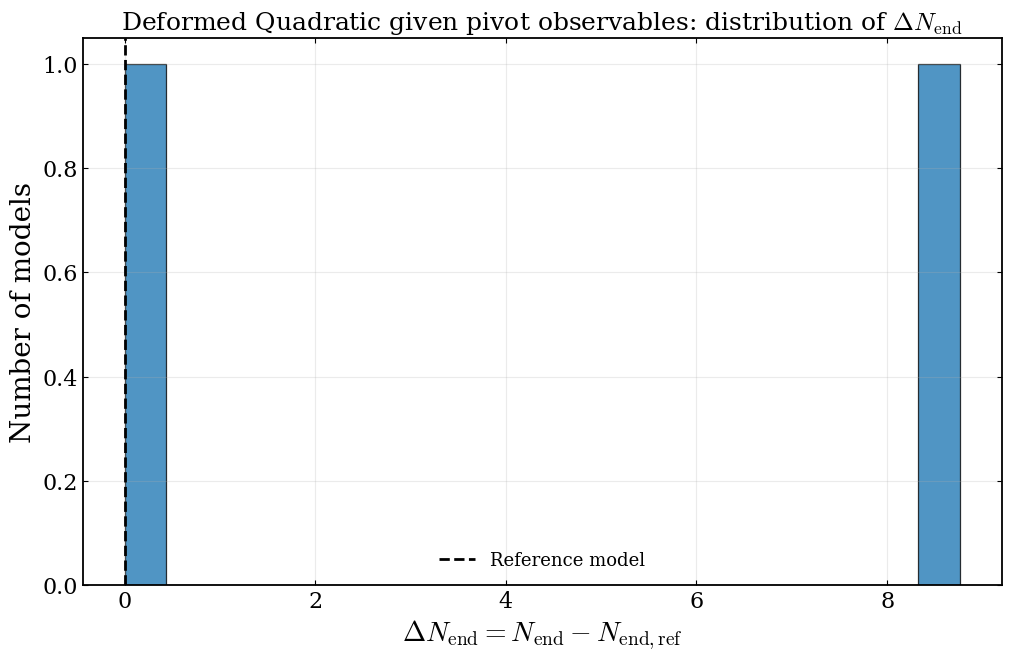

In [10]:
# df_deltaN_higgs = plot_deltaN_histogram_neqs8(
#     base_path_root=base_path_root,
#     base8_value=MODEL_CONFIG["higgs"]["lam_base"][8][1],
#     model_tag="higgs",
#     ns_min=0.95,
#     ns_max=0.98,
#     r_min=0.003664125 - 0.002,
#     r_max=0.003664125 + 0.002,
#     max_abs_alpha_s=None,
#     bins=20,
#     deltaN_guides=None,
#     save_name="neqs8_higgs_deltaN_histogram.pdf",
# )

df_deltaN_higgs = plot_deltaN_histogram_neqs8(
    base_path_root=base_path_root,
    base8_value=MODEL_CONFIG["nonhiggs"]["lam_base"][8][1],
    model_tag="nonhiggs",
    ns_min=None,
    ns_max=None,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    bins=20,
    deltaN_guides=None,
    save_name="neqs8_nonhiggs_deltaN_histogram.pdf",
)

### For Deformed Quadratic:

In [11]:
# df_deltaN_nonhiggs = plot_deltaN_histogram_neqs8(
#     base_path_root=base_path_root,
#     base8_value=MODEL_CONFIG["nonhiggs"]["lam_base"][8][1],
#     model_tag="nonhiggs",
#     ns_min=0.96,
#     ns_max=0.97,
#     r_min=3.2958886892e-2 - 0.002,
#     r_max=3.2958886892e-2 + 0.002,
#     max_abs_alpha_s=0.005,
#     bins=5,
#     deltaN_guides=[-15, 15],
#     save_name="neqs8_nonhiggs_deltaN_histogram.pdf",
# )

## Examine Unshifted Scalar and Tensor Power Spectra

In [11]:
#Function loads many scanned models and filters them by ns and Nend and normalizes each scalar and tensor at kref
#Then compares normalized spec with base spec
#Saves to data frame

def plot_filtered_spectra_by_ns_colored_by_Nend(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    Nend_min=None,
    Nend_max=None,
    cmap_name="plasma",
    save_name=None,
    show=True,
):

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "figure.titlesize": 24,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    
    #identify scanned parameter
    scan_name, scan_symbol = SCAN_INFO[NEQS]
    
    #get model label
    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    
    #loads all batch summary for CSVs for selected model family and NEQs
    def load_observables_from_summary(value):
        summary_all = load_batch_summaries(
            NEQS,
            base_path_root,
            model_tag=model_tag
        )

        #searches for row whose scanned parameter matches value
        row_match = summary_all.loc[
            np.isclose(summary_all[scan_name], value)
        ]

        if len(row_match) == 0:
            raise FileNotFoundError(
                f"No summary row found for {scan_name}={value:.10e}"
            )
        #if there are multiple rows, it will silently use the first one 
        row = row_match.iloc[0]
        
        #it will return observables and N
        return (
            row["r"],
            row["n_s"],
            row["alpha_s"],
            row["original_N_end"],
        )

    #we also wanna load our spectra files
    def load_specs_batch(value):
        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = s[:, 1]

        k_t = t[:, 0]
        Pt = t[:, 1]

        return k_s, Ps, k_t, Pt



    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool) #boolean mask containing all true

        #uses value set for k_min and k_max
        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

  
    #using functions now:
    lam_vals = sanitize_lam_values(lamX_values) #lam_vals is now 1D flat of array scan values
    
    
    #Loading that ref model and its spectra that are normalized
    r_base, ns_base, alpha_base, Nend_base = load_observables_from_summary(baseX) 

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs_batch(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref_local(
        k_s_base_raw,
        Ps_base_raw,
        k_ref
    )

    k_t_base, Pt_base_norm = normalize_at_ref_local(
        k_t_base_raw,
        Pt_base_raw,
        k_ref
    )

    #then for all lamX values it will load same observables and original Nend
    #every spectra gets dividided by its own value at 0.05, using normalize_at_ref_local
    
    rows = []
    kept_models = [] #defining models we will keep

    for lamX in lam_vals:
        try:
            r, ns, alpha_s, N_end = load_observables_from_summary(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs_batch(lamX)

            k_s, Ps_norm = normalize_at_ref_local(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref_local(k_t_raw, Pt_raw, k_ref)

            #we then compare that model to the base and get frac ps and pt
            k_ps_err, frac_ps = fractional_difference_on_reference_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = fractional_difference_on_reference_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            #then we store stats in terms of percentages
            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            #apply ns cut here
            keep_ns = ns_min <= ns <= ns_max

            #and N cut here
            keep_Nend = True

            if Nend_min is not None:
                keep_Nend &= N_end >= Nend_min

            if Nend_max is not None:
                keep_Nend &= N_end <= Nend_max

            keep = keep_ns and keep_Nend

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "original_N_end": N_end,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep_ns,
                "kept_by_Nend_cut": keep_Nend,
                "kept": keep,
            }

            rows.append(row)
            
            
#as long as keep is true and it is, we save all vals for the models
            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns") #sort by ns values
    kept_df = stats_df[stats_df["kept"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Base original_N_end: {Nend_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {stats_df['kept_by_ns_cut'].sum()}")
    print(f"Models kept after all cuts: {len(kept_df)}")

    if len(kept_models) == 0:
        print("No models passed the cuts.")
        return stats_df, kept_df
    #Makes an array for all Nend that are kept
    Nends_kept = np.array([m["original_N_end"] for m in kept_models]) #m is just one model in kept_models

    cmap = plt.get_cmap(cmap_name)
    #create our color scale from Nends
    norm = mcolors.Normalize(
        vmin=np.nanmin(Nends_kept),
        vmax=np.nanmax(Nends_kept),
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    for m in kept_models:
        color = cmap(norm(m["original_N_end"]))

        mask_ps_plot = scalar_k_mask(m["k_s"])

        ax_ps.loglog(
            m["k_s"][mask_ps_plot],
            m["Ps_norm"][mask_ps_plot],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_pt.loglog(
            m["k_t"],
            m["Pt_norm"],
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_ps_err.semilogx(
            m["k_ps_err"],
            100.0 * m["frac_ps"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

        ax_pt_err.semilogx(
            m["k_pt_err"],
            100.0 * m["frac_pt"],
            color=color,
            lw=1.5,
            alpha=0.85,
        )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$N_{\rm end}^{\rm original}$")
    cbar.ax.tick_params(direction="in")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"NEQS={NEQS} {model_label} models with "
        rf"${ns_min} \leq n_s \leq {ns_max}$, "
        rf"colored by $N_{{\rm end}}^{{\rm original}}$",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"colored_by_original_Nend.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    if show:
        plt.show()
    else:
        plt.close(fig)

    kept_df = kept_df.sort_values("original_N_end")


    return stats_df, kept_df


Running N_end-colored spectra: Deformed Quadratic

=== All models summary ===
Total loaded: 2
Base ns: 0.960824
Base original_N_end: 941.156262
Models in ns window [-10, 10]: 2
Models kept after all cuts: 2


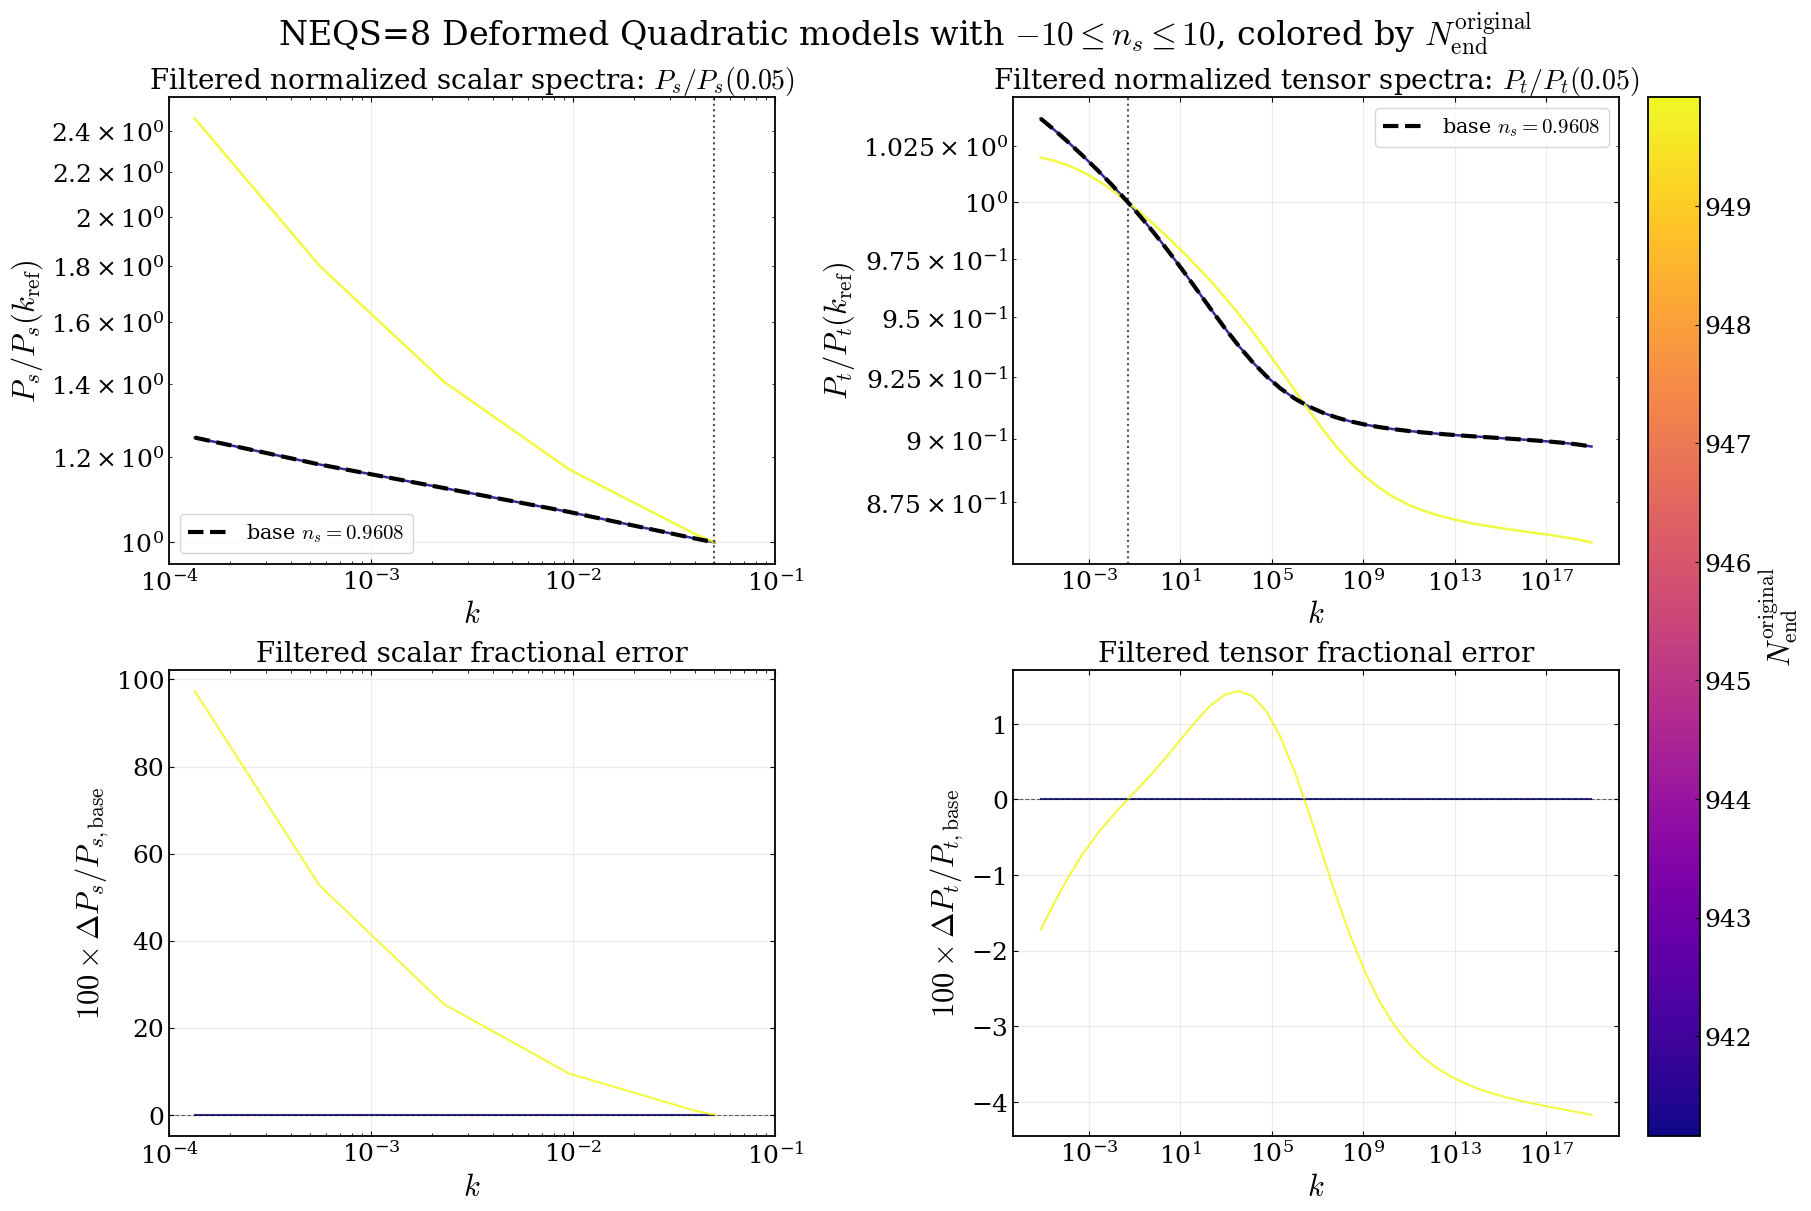

In [13]:


COLORED_SPECTRA_CONFIG = {
#     "higgs": {
#         "base_value": -8.92461e-9,
#         "save_name": (
#             "paper_higgs_neqs8_lam5"
#             "filtered_ns_spectra_colored_by_Nend.pdf"
#         ),
#     }}



    "nonhiggs": {
        "base_value": -0.000228347,
        "save_name": (
            "paper_nonhiggs_neqs8_lam2_"
            "filtered_ns_spectra_colored_by_Nend.pdf"
        ),
    },
}

colored_spectra_results = {}

for model_tag, config in COLORED_SPECTRA_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Running N_end-colored spectra: "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    lam2_values = param_values_by_model[model_tag][8]

    stats_df, kept_df = (
        plot_filtered_spectra_by_ns_colored_by_Nend(
            NEQS=8,
            lamX_values=lam2_values,
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=-10,
            ns_max=10,
            ns_target=0.967,

            k_ref=0.05,

            k_min_scalar=1e-4,
            k_max_scalar=1e-1,

            save_name=config["save_name"],
        )
    )

    colored_spectra_results[model_tag] = {
        "stats": stats_df,
        "kept": kept_df,
    }

## Examine Scalar and Tensor Power Spectra Relative to Base Model

Define Function:

In [14]:
def plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    model_tag="higgs",
    ns_min=0.963,
    ns_max=0.970,
    r_min=None,
    r_max=None,
    alpha_min=None,
    alpha_max=None,
    max_abs_alpha_s=None,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    k_min_tensor=None,
    k_max_tensor=None,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    show_max=True,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 10,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
        9: "royalblue",
    }

    summary_cache = {}

    def get_summary(NEQS):
        if NEQS not in summary_cache:
            summary_cache[NEQS] = load_batch_summaries(
                NEQS,
                base_path_root,
                model_tag=model_tag,
            )
        return summary_cache[NEQS]

#     def get_summary_row(NEQS, param_name, value):
#         summary_df = get_summary(NEQS)

#         matches = summary_df.loc[
#             np.isclose(summary_df[param_name], value)
#         ]

#         if len(matches) == 0:
#             raise ValueError(
#                 f"No summary row found for NEQS={NEQS}, "
#                 f"{param_name}={value:.10e}"
#             )

#         return matches.iloc[0]
    
    
    def get_summary_row(NEQS, param_name, value):
        summary_df = get_summary(NEQS)

        matches = summary_df.loc[
            np.isclose(
                summary_df[param_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-10),
            )
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return matches.iloc[0]



    def load_observables(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return row["r"], row["n_s"], row["alpha_s"]

    def get_original_N_end(NEQS, param_name, value):
        row = get_summary_row(NEQS, param_name, value)
        return float(row["original_N_end"])


    #This func is the main difference, instead of mean and max, i do mean and 68% and 95% spread
    
    def collect_percentile_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None

        k_env = k_ref_grid.copy()
        frac_stack = []

        #takes k and frac err for k range
        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue
                
#interpolates every model's fractional error curve on the same reference grid
#each model might have slightly different k-values
#percentiles make sense only if all models are compared at the same k
            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue
#will stack all k so we have a row of mode, columns of k vals, and entries are frac error at that k
            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        #i do take absolute values here
        abs_stack = np.abs(frac_stack)

        #so at every k it computes in percent the median (50th percentile), 68th percentiles and 95th and the max
        return {
            "k": k_env,
            "median": 100.0 * np.nanmedian(abs_stack, axis=0),
            "p68": 100.0 * np.nanpercentile(abs_stack, 68, axis=0),
            "p95": 100.0 * np.nanpercentile(abs_stack, 95, axis=0),
            "max": 100.0 * np.nanmax(abs_stack, axis=0),
        }

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

#     k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
#         ref_NEQS,
#         ref_param,
#         ref_value,
#     )
    
    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        NEQS=ref_NEQS,
        param_name=ref_param,
        value=ref_value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    k_s_ref, Ps_ref_norm = normalize_at_ref_local(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_ref_local(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_r": 0,
            "skipped_alpha": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)
                
                summary_row = get_summary_row(
                    NEQS,
                    param_name,
                    value,
                )

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                if r_min is not None and r < r_min:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if r_max is not None and r > r_max:
                    curves[NEQS]["skipped_r"] += 1
                    continue

                if alpha_min is not None and alpha_s < alpha_min:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if alpha_max is not None and alpha_s > alpha_max:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                if max_abs_alpha_s is not None and np.abs(alpha_s) > max_abs_alpha_s:
                    curves[NEQS]["skipped_alpha"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

#                 k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
#                     NEQS,
#                     param_name,
#                     value,
#                 )
                
                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS=NEQS,
                    param_name=param_name,
                    value=value,
                    base_path_root=base_path_root,
                    model_tag=model_tag,
                )

                # Unshifted
                k_s_un, Ps_un = normalize_at_ref_local(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_ref_local(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = fractional_difference_on_reference_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    xmin=k_min_scalar,
                    xmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = fractional_difference_on_reference_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                    xmin=k_min_tensor,
                    xmax=k_max_tensor,
                )

                # Shifted
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_ref_local(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_ref_local(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = fractional_difference_on_reference_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    xmin=k_min_scalar,
                    xmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = fractional_difference_on_reference_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                    xmin=k_min_tensor,
                    xmax=k_max_tensor,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue
                    
                # Per-model spectral distances
                # Median absolute percent difference over the selected k-range

                D_s_unshift = 100.0 * np.nanmedian(
                    np.abs(frac_ps_un)
                )

                D_s_shift = 100.0 * np.nanmedian(
                    np.abs(frac_ps_sh)
                )

                D_t_unshift = 100.0 * np.nanmedian(
                    np.abs(frac_pt_un)
                )

                D_t_shift = 100.0 * np.nanmedian(
                    np.abs(frac_pt_sh)
                )

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,

                    # Higher-order hierarchy values for this exact model
                    "lam2": float(summary_row["lam2"]),
                    "lam3": float(summary_row["lam3"]),
                    "lam4": float(summary_row["lam4"]),
                    "lam5": float(summary_row["lam5"]),

                    "r": float(r),
                    "ns": float(ns),
                    "alpha_s": float(alpha_s),

                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,

                    "D_s_unshift": D_s_unshift,
                    "D_s_shift": D_s_shift,

                    "D_t_unshift": D_t_unshift,
                    "D_t_shift": D_t_shift,
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, k_min_tensor, k_max_tensor, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            env = collect_percentile_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if env is None:
                continue

            k_env = env["k"]
            median = env["median"]
            p68 = env["p68"]
            p95 = env["p95"]
            max_env = env["max"]

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            median = median[mask]
            p68 = p68[mask]
            p95 = p95[mask]
            max_env = max_env[mask]

            if len(k_env) == 0:
                continue

            ax.fill_between(
                k_env,
                0.0,
                p95,
                color=color,
                alpha=0.16,
                label=rf"NEQS={NEQS} 95% spread",
            )

            ax.fill_between(
                k_env,
                0.0,
                p68,
                color=color,
                alpha=0.30,
                label=rf"NEQS={NEQS} 68% spread",
            )

            ax.plot(
                k_env,
                median,
                color=color,
                lw=2.5,
                label=rf"NEQS={NEQS} median",
            )

            if show_max:
                ax.plot(
                    k_env,
                    max_env,
                    color=color,
                    lw=1.25,
                    ls=":",
                    alpha=0.9,
                    label=rf"NEQS={NEQS} max",
                )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_abs_pct": np.nanmedian(median),
                "max_p68_abs_pct": np.nanmax(p68),
                "max_p95_abs_pct": np.nanmax(p95),
                "max_envelope_pct": np.nanmax(max_env),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
                "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
                "max_abs_alpha_s_cut": max_abs_alpha_s,
                "r_min": r_min,
                "r_max": r_max,
            })

        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}% tolerance",
        )

        if "Pt" in key:
            k_N60 = 0.05
            k_N20 = 1e15

            ax.axvline(k_N60, color="darkgreen", ls="--", lw=1.8, alpha=0.9)
            ax.axvline(k_N20, color="firebrick", ls="--", lw=1.8, alpha=0.9)

            ax.text(
                k_N60,
                0.82,
                r"$N\sim60$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="darkgreen",
                ha="right",
                va="top",
                fontsize=10,
            )

            ax.text(
                k_N20,
                0.82,
                r"$N\sim20$",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                color="firebrick",
                ha="right",
                va="top",
                fontsize=10,
            )

        ax.set_xscale("log")
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} percentile envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(fontsize=8, frameon=False, loc="best")

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if max_abs_alpha_s is not None:
        cut_text += rf", $|\alpha_s| \leq {max_abs_alpha_s}$"

    if r_min is not None or r_max is not None:
        rmin_text = r_min if r_min is not None else 0.0
        rmax_text = r_max if r_max is not None else np.inf
        cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

    fig.suptitle(
        rf"Percentile spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_r_tensorK_percentile_envelopes_"
            f"ref_neqs{ref_NEQS}.pdf"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    
    #Added
    # Default distances used in later hierarchy plots:
    # use the spectra after correcting for deltaN.
    if not model_df.empty:
        model_df["D_s"] = model_df["D_s_shift"]
        model_df["D_t"] = model_df["D_t_shift"]

    
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_r={curves[NEQS]['skipped_r']}, "
            f"skipped_alpha={curves[NEQS]['skipped_alpha']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Percentile envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    return model_df, envelope_df

Function Usage:

In [14]:
# # SPECTRUM_PLOT_CONFIG = {
# #     "higgs": {
# #         "ref_value": -8.92461e-9,
# #         "r_target": 2.737e-3,
# #         "r_delta": 0.001,
# #         "save_name": (
# #             "valid_ns_r_alpha_tensorK_"
# #             "percentile_envelopes_higgs.pdf"
# #         ),
# #     },

# #     "nonhiggs": {
# #         "ref_value": -3.3792701497e-5,
# #         "r_target": 3.2958886892e-2,
# #         "r_delta": 0.001,
# #         "save_name": (
# #             "valid_ns_r_alpha_tensorK_"
# #             "percentile_envelopes_nonhiggs.pdf"
# #         ),
# #     },
# # }


# #For lam5
# SPECTRUM_PLOT_CONFIG = {
#     "higgs": {
#         "ref_value": -8.92461e-9,
#         "r_target": 0.003664125,
#         "r_delta": 0.002,
#         "save_name": (
#             "valid_ns_r_alpha_tensorK_"
#             "percentile_envelopes_higgs.pdf"
#         ),
#     }}


# spectral_results = {}

# for model_tag, config in SPECTRUM_PLOT_CONFIG.items():

#     print("\n" + "=" * 70)
#     print(f"Running spectral-envelope analysis: {model_tag}")
#     print("=" * 70)

#     lam5_values = param_values_by_model[model_tag][8]

#     model_df_pct, envelope_df_pct = (
#         plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
#             base_path_root=base_path_root,
#             lam_values_by_neqs={
#                 8: lam5_values,
#             },

#             ref_NEQS=8,
#             ref_param="lam5",
#             ref_value=config["ref_value"],
#             model_tag=model_tag,

#             ns_min=0.95,
#             ns_max=0.98,

#             r_min=(
#                 config["r_target"]
#                 - config["r_delta"]
#             ),

#             r_max=(
#                 config["r_target"]
#                 + config["r_delta"]
#             ),

#             max_abs_alpha_s=None,

#             k_norm=0.05,

#             k_min_scalar=1e-4,
#             k_max_scalar=1e-1,

#             k_min_tensor=1e-2,
#             k_max_tensor=1e16,

#             max_abs_deltaN=None,
#             tolerance=5.0,
#             skip_zero=False,
#             show_max=False,

#             save_name=config["save_name"],
#         )
#     )

#     spectral_results[model_tag] = {
#         "models": model_df_pct,
#         "envelopes": envelope_df_pct,
#     }


Running spectral-envelope analysis: nonhiggs


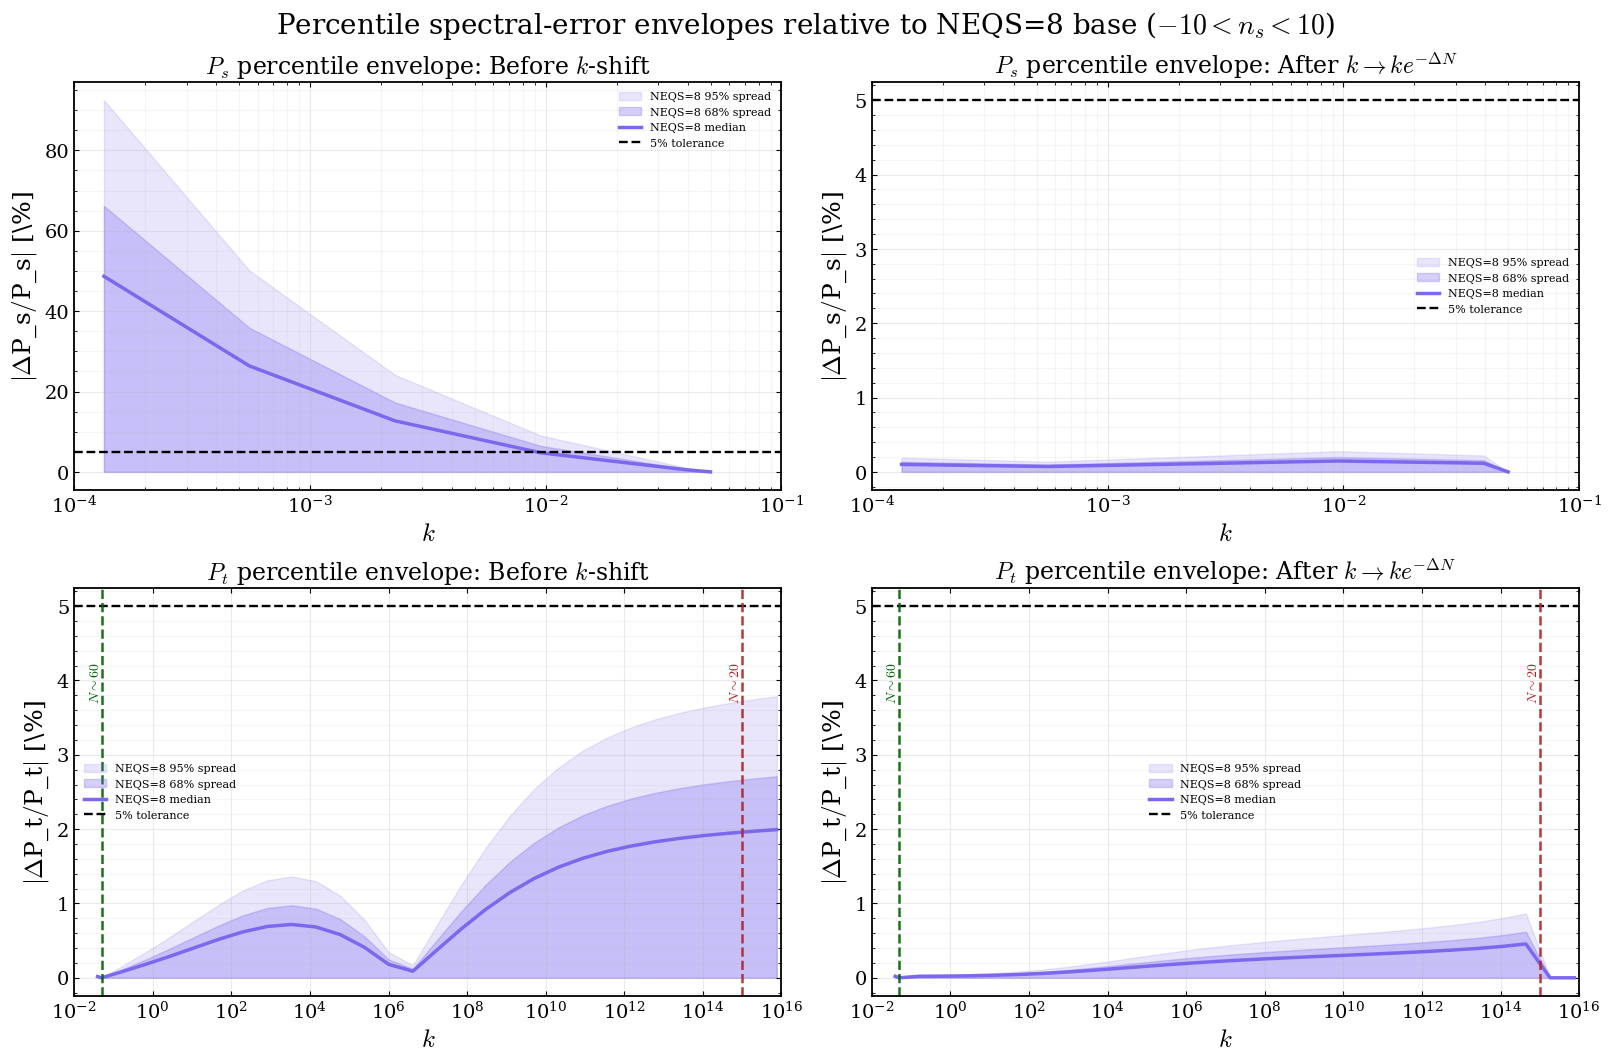


=== Cut summary ===
NEQS=8: kept=2, skipped_ns=0, skipped_r=0, skipped_alpha=0, skipped_deltaN=0, skipped_other=0

=== Percentile envelope summary ===
 NEQS       case  n_models  median_abs_pct  max_p68_abs_pct  max_p95_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  k_min_tensor  k_max_tensor max_abs_deltaN_cut max_abs_alpha_s_cut r_min r_max
    8 Ps_unshift         2        8.730302        66.195902        92.479569         97.346914        0.0001           0.1           NaN           NaN               None                None  None  None
    8   Ps_shift         2        0.104729         0.199309         0.278447          0.293102        0.0001           0.1           NaN           NaN               None                None  None  None
    8 Pt_unshift         2        0.687393         2.710952         3.787360          3.986695           NaN           NaN          0.01  1.000000e+16               None                None  None  None
    8   Pt_shift         2        0.1822

In [15]:
SPECTRUM_PLOT_CONFIG = {
#     "higgs": {
#         "ref_value": -8.92461e-9,
#         "r_target": 2.737e-3,
#         "r_delta": 0.001,
#         "save_name": (
#             "valid_ns_r_alpha_tensorK_"
#             "percentile_envelopes_higgs.pdf"
#         ),
#     },

    "nonhiggs": {
        "ref_value": -0.000228347,
        "r_target": 3.296e-02,
        "r_delta": 10,
        "save_name": (
            "valid_ns_r_alpha_tensorK_"
            "percentile_envelopes_nonhiggs.pdf"
        ),
    },
}


# #For lam3
# SPECTRUM_PLOT_CONFIG = {
#     "higgs": {
#         "ref_value": -8.92461e-9,
#         "r_target": 0.003664125,
#         "r_delta": 0.002,
#         "save_name": (
#             "valid_ns_r_alpha_tensorK_"
#             "percentile_envelopes_higgs.pdf"
#         ),
#     }}


spectral_results = {}

for model_tag, config in SPECTRUM_PLOT_CONFIG.items():

    print("\n" + "=" * 70)
    print(f"Running spectral-envelope analysis: {model_tag}")
    print("=" * 70)

    lam2_values = param_values_by_model[model_tag][8]

    model_df_pct, envelope_df_pct = (
        plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch(
            base_path_root=base_path_root,
            lam_values_by_neqs={
                8: lam2_values,
            },

            ref_NEQS=8,
            ref_param="lam2",
            ref_value=config["ref_value"],
            model_tag=model_tag,

            ns_min=-10,
            ns_max=10,

            r_min=None,

            r_max=None,

            max_abs_alpha_s=None,

            k_norm=0.05,

            k_min_scalar=1e-4,
            k_max_scalar=1e-1,

            k_min_tensor=1e-2,
            k_max_tensor=1e16,

            max_abs_deltaN=None,
            tolerance=5.0,
            skip_zero=False,
            show_max=False,

            save_name=config["save_name"],
        )
    )

    spectral_results[model_tag] = {
        "models": model_df_pct,
        "envelopes": envelope_df_pct,
    }

norm first 

In [16]:
# def plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch_diff(
#     base_path_root,
#     lam_values_by_neqs,
#     ref_NEQS=8,
#     ref_param="lam5",
#     ref_value=-8.92461e-9,
#     model_tag="higgs",
#     ns_min=0.963,
#     ns_max=0.970,
#     r_min=None,
#     r_max=None,
#     alpha_min=None,
#     alpha_max=None,
#     max_abs_alpha_s=None,
#     k_norm=0.05,
#     k_min_scalar=1e-4,
#     k_max_scalar=1e-1,
#     k_min_tensor=None,
#     k_max_tensor=None,
#     max_abs_deltaN=None,
#     tolerance=5.0,
#     skip_zero=True,
#     zero_tol=1e-30,
#     show_max=True,
#     save_name=None,
# ):
#     plt.rcParams.update({
#         "text.usetex": False,
#         "mathtext.fontset": "cm",
#         "font.family": "serif",
#         "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
#         "axes.labelsize": 18,
#         "axes.titlesize": 17,
#         "xtick.labelsize": 14,
#         "ytick.labelsize": 14,
#         "legend.fontsize": 10,
#         "figure.titlesize": 22,
#         "axes.linewidth": 1.3,
#         "xtick.direction": "in",
#         "ytick.direction": "in",
#         "xtick.top": True,
#         "ytick.right": True,
#     })

#     colors_by_neqs = {
#         7: "plum",
#         8: "mediumslateblue",
#         9: "royalblue",
#     }

#     summary_cache = {}

#     def get_summary(NEQS):
#         if NEQS not in summary_cache:
#             summary_cache[NEQS] = load_batch_summaries(
#                 NEQS,
#                 base_path_root,
#                 model_tag=model_tag,
#             )
#         return summary_cache[NEQS]

# #     def get_summary_row(NEQS, param_name, value):
# #         summary_df = get_summary(NEQS)

# #         matches = summary_df.loc[
# #             np.isclose(summary_df[param_name], value)
# #         ]

# #         if len(matches) == 0:
# #             raise ValueError(
# #                 f"No summary row found for NEQS={NEQS}, "
# #                 f"{param_name}={value:.10e}"
# #             )

# #         return matches.iloc[0]
    
    
#     def get_summary_row(NEQS, param_name, value):
#         summary_df = get_summary(NEQS)

#         matches = summary_df.loc[
#             np.isclose(
#                 summary_df[param_name].to_numpy(dtype=float),
#                 value,
#                 rtol=1e-10,
#                 atol=max(1e-15, abs(value) * 1e-10),
#             )
#         ]

#         if len(matches) == 0:
#             raise ValueError(
#                 f"No summary row found for NEQS={NEQS}, "
#                 f"{param_name}={value:.10e}"
#             )

#         return matches.iloc[0]



#     def load_observables(NEQS, param_name, value):
#         row = get_summary_row(NEQS, param_name, value)
#         return row["r"], row["n_s"], row["alpha_s"]

#     def get_original_N_end(NEQS, param_name, value):
#         row = get_summary_row(NEQS, param_name, value)
#         return float(row["original_N_end"])


#     #This func is the main difference, instead of mean and max, i do mean and 68% and 95% spread
    
#     def collect_percentile_envelope(frac_curves, k_ref_grid):
#         if len(frac_curves) == 0:
#             return None

#         k_env = k_ref_grid.copy()
#         frac_stack = []

#         #takes k and frac err for k range
#         for k_curve, frac_curve in frac_curves:
#             if len(k_curve) < 2:
#                 continue
                
# #interpolates every model's fractional error curve on the same reference grid
# #each model might have slightly different k-values
# #percentiles make sense only if all models are compared at the same k
#             interp = np.interp(
#                 k_env,
#                 k_curve,
#                 frac_curve,
#                 left=np.nan,
#                 right=np.nan,
#             )

#             if np.all(~np.isfinite(interp)):
#                 continue
# #will stack all k so we have a row of mode, columns of k vals, and entries are frac error at that k
#             frac_stack.append(interp)

#         if len(frac_stack) == 0:
#             return None

#         frac_stack = np.array(frac_stack)

#         valid_cols = np.any(np.isfinite(frac_stack), axis=0)
#         frac_stack = frac_stack[:, valid_cols]
#         k_env = k_env[valid_cols]

#         #i do take absolute values here
#         abs_stack = np.abs(frac_stack)

#         #so at every k it computes in percent the median (50th percentile), 68th percentiles and 95th and the max
#         return {
#             "k": k_env,
#             "median": 100.0 * np.nanmedian(abs_stack, axis=0),
#             "p68": 100.0 * np.nanpercentile(abs_stack, 68, axis=0),
#             "p95": 100.0 * np.nanpercentile(abs_stack, 95, axis=0),
#             "max": 100.0 * np.nanmax(abs_stack, axis=0),
#         }

#     # Reference spectra
#     ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

# #     k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
# #         ref_NEQS,
# #         ref_param,
# #         ref_value,
# #     )
    
#     k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
#         NEQS=ref_NEQS,
#         param_name=ref_param,
#         value=ref_value,
#         base_path_root=base_path_root,
#         model_tag=model_tag,
#     )

#     k_s_ref, Ps_ref_norm = normalize_at_ref_local(k_s_ref_raw, Ps_ref_raw, k_norm)
#     k_t_ref, Pt_ref_norm = normalize_at_ref_local(k_t_ref_raw, Pt_ref_raw, k_norm)

#     curves = {
#         NEQS: {
#             "Ps_unshift": [],
#             "Ps_shift": [],
#             "Pt_unshift": [],
#             "Pt_shift": [],
#             "rows": [],
#             "skipped_deltaN": 0,
#             "skipped_ns": 0,
#             "skipped_r": 0,
#             "skipped_alpha": 0,
#             "skipped_other": 0,
#         }
#         for NEQS in lam_values_by_neqs.keys()
#     }

#     for NEQS, lam_values in lam_values_by_neqs.items():
#         param_name, _ = SCAN_INFO[NEQS]

#         for item in lam_values:
#             value = item[0] if isinstance(item, tuple) else item
#             value = float(value)

#             if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
#                 continue

#             try:
#                 r, ns, alpha_s = load_observables(NEQS, param_name, value)
                
#                 summary_row = get_summary_row(
#                     NEQS,
#                     param_name,
#                     value,
#                 )

#                 if not (ns_min <= ns <= ns_max):
#                     curves[NEQS]["skipped_ns"] += 1
#                     continue

#                 if r_min is not None and r < r_min:
#                     curves[NEQS]["skipped_r"] += 1
#                     continue

#                 if r_max is not None and r > r_max:
#                     curves[NEQS]["skipped_r"] += 1
#                     continue

#                 if alpha_min is not None and alpha_s < alpha_min:
#                     curves[NEQS]["skipped_alpha"] += 1
#                     continue

#                 if alpha_max is not None and alpha_s > alpha_max:
#                     curves[NEQS]["skipped_alpha"] += 1
#                     continue

#                 if max_abs_alpha_s is not None and np.abs(alpha_s) > max_abs_alpha_s:
#                     curves[NEQS]["skipped_alpha"] += 1
#                     continue

#                 model_N_end = get_original_N_end(NEQS, param_name, value)
#                 deltaN = model_N_end - ref_N_end
#                 abs_deltaN = np.abs(deltaN)

#                 if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
#                     curves[NEQS]["skipped_deltaN"] += 1
#                     continue

# #                 k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
# #                     NEQS,
# #                     param_name,
# #                     value,
# #                 )
                
#                 k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
#                     NEQS=NEQS,
#                     param_name=param_name,
#                     value=value,
#                     base_path_root=base_path_root,
#                     model_tag=model_tag,
#                 )

#                 # Unshifted
#                 k_s_un, Ps_un = normalize_at_ref_local(k_s_raw, Ps_raw, k_norm)
#                 k_t_un, Pt_un = normalize_at_ref_local(k_t_raw, Pt_raw, k_norm)

#                 k_ps_un, frac_ps_un = fractional_difference_on_reference_grid(
#                     k_s_ref,
#                     Ps_ref_norm,
#                     k_s_un,
#                     Ps_un,
#                     xmin=k_min_scalar,
#                     xmax=k_max_scalar,
#                 )

#                 k_pt_un, frac_pt_un = fractional_difference_on_reference_grid(
#                     k_t_ref,
#                     Pt_ref_norm,
#                     k_t_un,
#                     Pt_un,
#                     xmin=k_min_tensor,
#                     xmax=k_max_tensor,
#                 )

#                 # Shifted
#                 #
#                 # Normalize on the ORIGINAL k-grid, where k_norm is guaranteed
#                 # to exist, and only then apply the Delta-N horizontal shift.
#                 # This lets us keep very large shifts even when the shifted
#                 # spectrum no longer contains k_norm=0.05.
#                 k_s_sh, Ps_sh = normalize_at_ref_local(
#                     k_s_raw,
#                     Ps_raw,
#                     k_norm,
#                 )
#                 k_t_sh, Pt_sh = normalize_at_ref_local(
#                     k_t_raw,
#                     Pt_raw,
#                     k_norm,
#                 )

#                 k_s_sh = k_s_sh * np.exp(-deltaN)
#                 k_t_sh = k_t_sh * np.exp(-deltaN)

#                 # For shifted spectra, compare over whatever k-range actually
#                 # overlaps the shifted model and the reference spectrum.
#                 # Do not force the original scalar/tensor plotting windows.
#                 k_ps_sh, frac_ps_sh = fractional_difference_on_reference_grid(
#                     k_s_ref,
#                     Ps_ref_norm,
#                     k_s_sh,
#                     Ps_sh,
#                     xmin=None,
#                     xmax=None,
#                 )

#                 k_pt_sh, frac_pt_sh = fractional_difference_on_reference_grid(
#                     k_t_ref,
#                     Pt_ref_norm,
#                     k_t_sh,
#                     Pt_sh,
#                     xmin=None,
#                     xmax=None,
#                 )

#                 if (
#                     len(frac_ps_un) == 0
#                     or len(frac_ps_sh) == 0
#                     or len(frac_pt_un) == 0
#                     or len(frac_pt_sh) == 0
#                 ):
#                     curves[NEQS]["skipped_other"] += 1
#                     continue
                    
#                 # Per-model spectral distances
#                 # Median absolute percent difference over the selected k-range

#                 D_s_unshift = 100.0 * np.nanmedian(
#                     np.abs(frac_ps_un)
#                 )

#                 D_s_shift = 100.0 * np.nanmedian(
#                     np.abs(frac_ps_sh)
#                 )

#                 D_t_unshift = 100.0 * np.nanmedian(
#                     np.abs(frac_pt_un)
#                 )

#                 D_t_shift = 100.0 * np.nanmedian(
#                     np.abs(frac_pt_sh)
#                 )

#                 curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
#                 curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
#                 curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
#                 curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

#                 curves[NEQS]["rows"].append({
#                     "NEQS": NEQS,
#                     "param_name": param_name,
#                     "value": value,

#                     # Higher-order hierarchy values for this exact model
#                     "lam2": float(summary_row["lam2"]),
#                     "lam3": float(summary_row["lam3"]),
#                     "lam4": float(summary_row["lam4"]),
#                     "lam5": float(summary_row["lam5"]),

#                     "r": float(r),
#                     "ns": float(ns),
#                     "alpha_s": float(alpha_s),

#                     "original_N_end": model_N_end,
#                     "deltaN_from_ref_base": deltaN,
#                     "abs_deltaN_from_ref_base": abs_deltaN,

#                     "D_s_unshift": D_s_unshift,
#                     "D_s_shift": D_s_shift,

#                     "D_t_unshift": D_t_unshift,
#                     "D_t_shift": D_t_shift,
#                 })

#             except FileNotFoundError:
#                 print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
#                 curves[NEQS]["skipped_other"] += 1

#             except ValueError as e:
#                 print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
#                 curves[NEQS]["skipped_other"] += 1

#     # Plot
#     fig, axes = plt.subplots(
#         2,
#         2,
#         figsize=(16, 10.5),
#         constrained_layout=True,
#     )

#     ax_ps_un, ax_ps_sh = axes[0]
#     ax_pt_un, ax_pt_sh = axes[1]

#     plot_specs = [
#         (
#             "Ps_unshift",
#             ax_ps_un,
#             k_s_ref,
#             k_min_scalar,
#             k_max_scalar,
#             r"$P_s$",
#             "Before $k$-shift",
#         ),
#         (
#             "Ps_shift",
#             ax_ps_sh,
#             k_s_ref,
#             None,
#             None,
#             r"$P_s$",
#             r"After $k \to k e^{-\Delta N}$",
#         ),
#         (
#             "Pt_unshift",
#             ax_pt_un,
#             k_t_ref,
#             k_min_tensor,
#             k_max_tensor,
#             r"$P_t$",
#             "Before $k$-shift",
#         ),
#         (
#             "Pt_shift",
#             ax_pt_sh,
#             k_t_ref,
#             None,
#             None,
#             r"$P_t$",
#             r"After $k \to k e^{-\Delta N}$",
#         ),
#     ]

#     envelope_rows = []

#     for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
#         for NEQS in lam_values_by_neqs.keys():
#             color = colors_by_neqs.get(NEQS, None)

#             env = collect_percentile_envelope(
#                 curves[NEQS][key],
#                 k_ref_grid,
#             )

#             if env is None:
#                 continue

#             k_env = env["k"]
#             median = env["median"]
#             p68 = env["p68"]
#             p95 = env["p95"]
#             max_env = env["max"]

#             mask = np.ones_like(k_env, dtype=bool)

#             if kmin is not None:
#                 mask &= k_env >= kmin

#             if kmax is not None:
#                 mask &= k_env <= kmax

#             k_env = k_env[mask]
#             median = median[mask]
#             p68 = p68[mask]
#             p95 = p95[mask]
#             max_env = max_env[mask]

#             if len(k_env) == 0:
#                 continue

#             ax.fill_between(
#                 k_env,
#                 0.0,
#                 p95,
#                 color=color,
#                 alpha=0.16,
#                 label=rf"NEQS={NEQS} 95% spread",
#             )

#             ax.fill_between(
#                 k_env,
#                 0.0,
#                 p68,
#                 color=color,
#                 alpha=0.30,
#                 label=rf"NEQS={NEQS} 68% spread",
#             )

#             ax.plot(
#                 k_env,
#                 median,
#                 color=color,
#                 lw=2.5,
#                 label=rf"NEQS={NEQS} median",
#             )

#             if show_max:
#                 ax.plot(
#                     k_env,
#                     max_env,
#                     color=color,
#                     lw=1.25,
#                     ls=":",
#                     alpha=0.9,
#                     label=rf"NEQS={NEQS} max",
#                 )

#             envelope_rows.append({
#                 "NEQS": NEQS,
#                 "case": key,
#                 "n_models": len(curves[NEQS][key]),
#                 "median_abs_pct": np.nanmedian(median),
#                 "max_p68_abs_pct": np.nanmax(p68),
#                 "max_p95_abs_pct": np.nanmax(p95),
#                 "max_envelope_pct": np.nanmax(max_env),
#                 "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
#                 "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
#                 "k_min_tensor": k_min_tensor if "Pt" in key else np.nan,
#                 "k_max_tensor": k_max_tensor if "Pt" in key else np.nan,
#                 "max_abs_deltaN_cut": max_abs_deltaN,
#                 "max_abs_alpha_s_cut": max_abs_alpha_s,
#                 "r_min": r_min,
#                 "r_max": r_max,
#             })

#         ax.axhline(
#             tolerance,
#             color="black",
#             lw=1.7,
#             ls="--",
#             label=rf"{tolerance:.0f}% tolerance",
#         )

#         if "Pt" in key:
#             k_N60 = 0.05
#             k_N20 = 1e15

#             ax.axvline(k_N60, color="darkgreen", ls="--", lw=1.8, alpha=0.9)
#             ax.axvline(k_N20, color="firebrick", ls="--", lw=1.8, alpha=0.9)

#             ax.text(
#                 k_N60,
#                 0.82,
#                 r"$N\sim60$",
#                 transform=ax.get_xaxis_transform(),
#                 rotation=90,
#                 color="darkgreen",
#                 ha="right",
#                 va="top",
#                 fontsize=10,
#             )

#             ax.text(
#                 k_N20,
#                 0.82,
#                 r"$N\sim20$",
#                 transform=ax.get_xaxis_transform(),
#                 rotation=90,
#                 color="firebrick",
#                 ha="right",
#                 va="top",
#                 fontsize=10,
#             )

#         ax.set_xscale("log")
#         ax.grid(True, which="major", alpha=0.25)
#         ax.grid(True, which="minor", alpha=0.12)
#         ax.minorticks_on()

#         ax.set_title(rf"{quantity_label} percentile envelope: {title_suffix}")
#         ax.set_xlabel(r"$k$")
#         ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

#         if kmin is not None or kmax is not None:
#             xmin = kmin if kmin is not None else k_ref_grid.min()
#             xmax = kmax if kmax is not None else k_ref_grid.max()
#             ax.set_xlim(xmin, xmax)

#         ax.legend(fontsize=8, frameon=False, loc="best")

#     cut_text = ""

#     if max_abs_deltaN is not None:
#         cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

#     if max_abs_alpha_s is not None:
#         cut_text += rf", $|\alpha_s| \leq {max_abs_alpha_s}$"

#     if r_min is not None or r_max is not None:
#         rmin_text = r_min if r_min is not None else 0.0
#         rmax_text = r_max if r_max is not None else np.inf
#         cut_text += rf", $r\in[{rmin_text:.2g},{rmax_text:.2g}]$"

#     fig.suptitle(
#         rf"Percentile spectral-error envelopes relative to NEQS={ref_NEQS} base "
#         rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
#         fontsize=20,
#     )

#     if save_name is None:
#         save_name = (
#             f"valid_ns_r_tensorK_percentile_envelopes_"
#             f"ref_neqs{ref_NEQS}.pdf"
#         )

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")
#     plt.show()

#     model_rows = []
#     for NEQS in lam_values_by_neqs.keys():
#         model_rows.extend(curves[NEQS]["rows"])

#     model_df = pd.DataFrame(model_rows)
    
#     #Added
#     # Default distances used in later hierarchy plots:
#     # use the spectra after correcting for deltaN.
#     if not model_df.empty:
#         model_df["D_s"] = model_df["D_s_shift"]
#         model_df["D_t"] = model_df["D_t_shift"]

    
#     envelope_df = pd.DataFrame(envelope_rows)

#     print("\n=== Cut summary ===")
#     for NEQS in lam_values_by_neqs.keys():
#         print(
#             f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
#             f"skipped_ns={curves[NEQS]['skipped_ns']}, "
#             f"skipped_r={curves[NEQS]['skipped_r']}, "
#             f"skipped_alpha={curves[NEQS]['skipped_alpha']}, "
#             f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
#             f"skipped_other={curves[NEQS]['skipped_other']}"
#         )

#     print("\n=== Percentile envelope summary ===")
#     if not envelope_df.empty:
#         print(envelope_df.to_string(index=False))

#     return model_df, envelope_df

In [17]:
# # SPECTRUM_PLOT_CONFIG = {
# #     "higgs": {
# #         "ref_value": -8.92461e-9,
# #         "r_target": 2.737e-3,
# #         "r_delta": 0.001,
# #         "save_name": (
# #             "valid_ns_r_alpha_tensorK_"
# #             "percentile_envelopes_higgs.pdf"
# #         ),
# #     },

# #     "nonhiggs": {
# #         "ref_value": -3.3792701497e-5,
# #         "r_target": 3.2958886892e-2,
# #         "r_delta": 0.001,
# #         "save_name": (
# #             "valid_ns_r_alpha_tensorK_"
# #             "percentile_envelopes_nonhiggs.pdf"
# #         ),
# #     },
# # }


# #For lam5
# SPECTRUM_PLOT_CONFIG = {
#     "higgs": {
#         "ref_value": -8.92461e-9,
#         "r_target": 0.003664125,
#         "r_delta": 0.002,
#         "save_name": (
#             "valid_ns_r_alpha_tensorK_"
#             "percentile_envelopes_higgs.pdf"
#         ),
#     }}


# spectral_results = {}

# for model_tag, config in SPECTRUM_PLOT_CONFIG.items():

#     print("\n" + "=" * 70)
#     print(f"Running spectral-envelope analysis: {model_tag}")
#     print("=" * 70)

#     lam5_values = param_values_by_model[model_tag][8]

#     model_df_pct, envelope_df_pct = (
#         plot_valid_ns_before_after_kshift_percentile_envelopes_tensorK_batch_diff(
#             base_path_root=base_path_root,
#             lam_values_by_neqs={
#                 8: lam5_values,
#             },

#             ref_NEQS=8,
#             ref_param="lam5",
#             ref_value=config["ref_value"],
#             model_tag=model_tag,

#             ns_min=0.95,
#             ns_max=0.98,

#             r_min=None,

#             r_max=None,

#             max_abs_alpha_s=None,

#             k_norm=0.05,

#             k_min_scalar=1e-4,
#             k_max_scalar=1e-1,

#             k_min_tensor=1e-2,
#             k_max_tensor=1e16,

#             max_abs_deltaN=None,
#             tolerance=5.0,
#             skip_zero=False,
#             show_max=False,

#             save_name=config["save_name"],
#         )
#     )

#     spectral_results[model_tag] = {
#         "models": model_df_pct,
#         "envelopes": envelope_df_pct,
#     }

In [16]:
print(spectral_results["nonhiggs"]["models"][["value", "original_N_end", "deltaN_from_ref_base", "D_s_unshift", "D_s_shift"]])

      value  original_N_end  deltaN_from_ref_base  D_s_unshift  D_s_shift
0 -0.000228      941.156262              0.000000     0.000000   0.000000
1  0.000000      949.919526              8.763264    17.460604   0.209459


In [17]:
def print_model_pivot_summary(
    row,
    base_path_root,
    model_tag="higgs",
    k_pivot=0.05,
):
    """
    Print a clean summary of:
      - hierarchy parameter value
      - total inflation duration / delta N
      - scalar/tensor spectral distances
      - r, ns, alpha_s from flow
      - r, ns, alpha_s measured directly from numerical spectra
        at k_pivot
    """

    NEQS = int(row["NEQS"])
    param_name = row["param_name"]
    value = float(row["value"])

    # --------------------------------------------------
    # Load numerical spectra
    # --------------------------------------------------
    k_s, Ps, k_t, Pt = load_specs(
        NEQS=NEQS,
        param_name=param_name,
        value=value,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    # Make sure everything is sorted in k
    s_sort = np.argsort(k_s)
    t_sort = np.argsort(k_t)

    k_s = np.asarray(k_s)[s_sort]
    Ps  = np.asarray(Ps)[s_sort]

    k_t = np.asarray(k_t)[t_sort]
    Pt  = np.asarray(Pt)[t_sort]

    # --------------------------------------------------
    # Work in ln(k), ln(P)
    # --------------------------------------------------
    lnks = np.log(k_s)
    lnPs = np.log(Ps)

    lnkt = np.log(k_t)
    lnPt = np.log(Pt)

    # Cubic splines
    Ps_spline = InterpolatedUnivariateSpline(
        lnks,
        lnPs,
        k=3,
    )

    Pt_spline = InterpolatedUnivariateSpline(
        lnkt,
        lnPt,
        k=3,
    )

    lnk_star = np.log(k_pivot)

    # --------------------------------------------------
    # Spectrum values at exact pivot
    # --------------------------------------------------
    Ps_pivot = np.exp(Ps_spline(lnk_star))
    Pt_pivot = np.exp(Pt_spline(lnk_star))

    # r(k*) = Pt / Ps
    r_spec = Pt_pivot / Ps_pivot

    # ns - 1 = d ln Ps / d ln k
    ns_spec = 1.0 + Ps_spline.derivative(1)(lnk_star)

    # alpha_s = d ns / d ln k
    #         = d² ln Ps / d(ln k)²
    alpha_spec = Ps_spline.derivative(2)(lnk_star)

    # --------------------------------------------------
    # Flow values already stored in dataframe
    # --------------------------------------------------
    r_flow = float(row["r"])
    ns_flow = float(row["ns"])
    alpha_flow = float(row["alpha_s"])

    # --------------------------------------------------
    # Pretty print
    # --------------------------------------------------
    print("\n" + "=" * 72)

    if np.isclose(value, 0.0, atol=1e-15):
        label = f"{param_name} = 0"
    else:
        label = f"{param_name} = {value:.10e}"

    print(f"MODEL: {label}")
    print("=" * 72)

    print("\nInflation duration")
    print("-" * 72)
    print(f"original N_end       = {row['original_N_end']:.6f}")
    print(f"Delta N from base    = {row['deltaN_from_ref_base']:+.6f}")

    print("\nSpectral differences from base")
    print("-" * 72)
    print(f"D_s before k-shift   = {row['D_s_unshift']:.6f} %")
    print(f"D_s after  k-shift   = {row['D_s_shift']:.6f} %")
    print(f"D_t before k-shift   = {row['D_t_unshift']:.6f} %")
    print(f"D_t after  k-shift   = {row['D_t_shift']:.6f} %")

    print(f"\nPivot: k* = {k_pivot:g} h Mpc^-1")
    print("-" * 72)

    print(f"P_s(k*)              = {Ps_pivot:.10e}")
    print(f"P_t(k*)              = {Pt_pivot:.10e}")

    print("\nObservable              flow              spectrum          difference")
    print("-" * 72)

    print(
        f"r              "
        f"{r_flow: .10e}    "
        f"{r_spec: .10e}    "
        f"{r_spec-r_flow:+.3e}"
    )

    print(
        f"n_s            "
        f"{ns_flow: .10f}    "
        f"{ns_spec: .10f}    "
        f"{ns_spec-ns_flow:+.3e}"
    )

    print(
        f"alpha_s        "
        f"{alpha_flow: .10e}    "
        f"{alpha_spec: .10e}    "
        f"{alpha_spec-alpha_flow:+.3e}"
    )

    print("=" * 72)

In [18]:
for _, row in model_df_pct.iterrows():
    print_model_pivot_summary(
        row,
        base_path_root=base_path_root,
        model_tag="nonhiggs",
        k_pivot=0.05,
    )


MODEL: lam2 = -2.2834700000e-04

Inflation duration
------------------------------------------------------------------------
original N_end       = 941.156262
Delta N from base    = +0.000000

Spectral differences from base
------------------------------------------------------------------------
D_s before k-shift   = 0.000000 %
D_s after  k-shift   = 0.000000 %
D_t before k-shift   = 0.000000 %
D_t after  k-shift   = 0.000000 %

Pivot: k* = 0.05 h Mpc^-1
------------------------------------------------------------------------
P_s(k*)              = 1.9976785346e-09
P_t(k*)              = 8.2646365404e-11

Observable              flow              spectrum          difference
------------------------------------------------------------------------
r               3.2958886892e-02     4.1371203611e-02    +8.412e-03
n_s             0.9608243182     0.9618178847    +9.936e-04
alpha_s         4.2815780610e-03    -1.5401782212e-02    -1.968e-02

MODEL: lam2 = 0

Inflation duration
--------

In [32]:
print("Number of rows:", len(model_df_pct))

Number of rows: 1


In [34]:
print(model_df_pct[[
    "value",
    "lam3",
    "lam4",
    "lam5",
    "original_N_end",
    "deltaN_from_ref_base",
]])

print("\nNumber of models =", len(model_df_pct))

          value      lam3          lam4          lam5  original_N_end  \
0 -8.924610e-09 -0.000005  6.870650e-08 -8.924610e-09      946.349733   

   deltaN_from_ref_base  
0                   0.0  

Number of models = 1


For all models that can be compared at the pivot scale, shifting by ΔN substantially reduces the spread.

## Background Variables

In [15]:
def plot_filtered_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.961,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    
    
    
    scan_name, scan_symbol = SCAN_INFO[NEQS]
    
    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label",model_tag)


    summary_all = load_batch_summaries(
    NEQS=NEQS,
    base_path_root=base_path_root,
    model_tag=model_tag,
)
    
    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)

        return N[mask], Y[mask]
    
    def load_observables_local(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-15),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, model={model_tag}"
            )

        row = matches.iloc[0]

        return (
            float(row["r"]),
            float(row["n_s"]),
            float(row["alpha_s"]),
        )


    def load_path_local(value):
        return load_path_data(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )



        def apply_N_window(N, Y):
            if N_window is None:
                return N, Y

            Nmin, Nmax = N_window
            mask = (N >= Nmin) & (N <= Nmax)
            return N[mask], Y[mask]



    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables_local(baseX)
    base_data = load_path_local(baseX)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    N_base_H, H_base_norm, H_ref = normalize_curve_at_Nref(N_base, H_base, N_ref)
    N_base_eps, eps_base_norm, eps_ref = normalize_curve_at_Nref(N_base, eps_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_curve_at_Nref(N_base, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables_local(lamX)
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path_local(lamX)

            H = data[:, 1]
            eps = data[:, 2]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            N_H, H_norm, _ = normalize_curve_at_Nref(N, H, N_ref)
            N_eps, eps_norm, _ = normalize_curve_at_Nref(N, eps, N_ref)
            N_V, V_norm, _ = normalize_curve_at_Nref(N, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_difference_on_reference_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_eps, frac_eps = fractional_difference_on_reference_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

            N_frac_V, frac_V = fractional_difference_on_reference_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            kept_models.append({
                **row,

                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_eps": N_eps_plot,
                "eps_N": eps_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,

                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_eps": N_frac_eps,
                "frac_eps": frac_eps,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,

                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_deps_pct": 100.0 * np.nanmean(frac_eps),
                "max_deps_pct": 100.0 * np.nanmax(np.abs(frac_eps)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N",
                "N_eps", "eps_N",
                "N_V", "V_N",
                "N_frac_H", "frac_H",
                "N_frac_eps", "frac_eps",
                "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()



    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]
    ax_epsN, ax_epserr = axes[2]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)
            ax_epsN.plot(m["N_eps"], m["eps_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_epserr.plot(
                m["N_frac_eps"],
                100.0 * m["frac_eps"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_epsN.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_Herr, ax_Verr, ax_epserr]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
    ax_epsN.set_title(rf"Filtered normalized slow-roll evolution: $\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Fractional difference in normalized potential evolution")
    ax_epserr.set_title(r"Fractional difference in normalized $\epsilon(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_epserr.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_epserr.set_ylim(eps_frac_ylim)

    
    fig.suptitle(
        rf"NEQS={NEQS} {model_label} models with "
        rf"${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors_with_epsilon.pdf"

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )
    
    
    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df




Running background analysis: Higgs
Missing files for lam5=-3.66273e-05


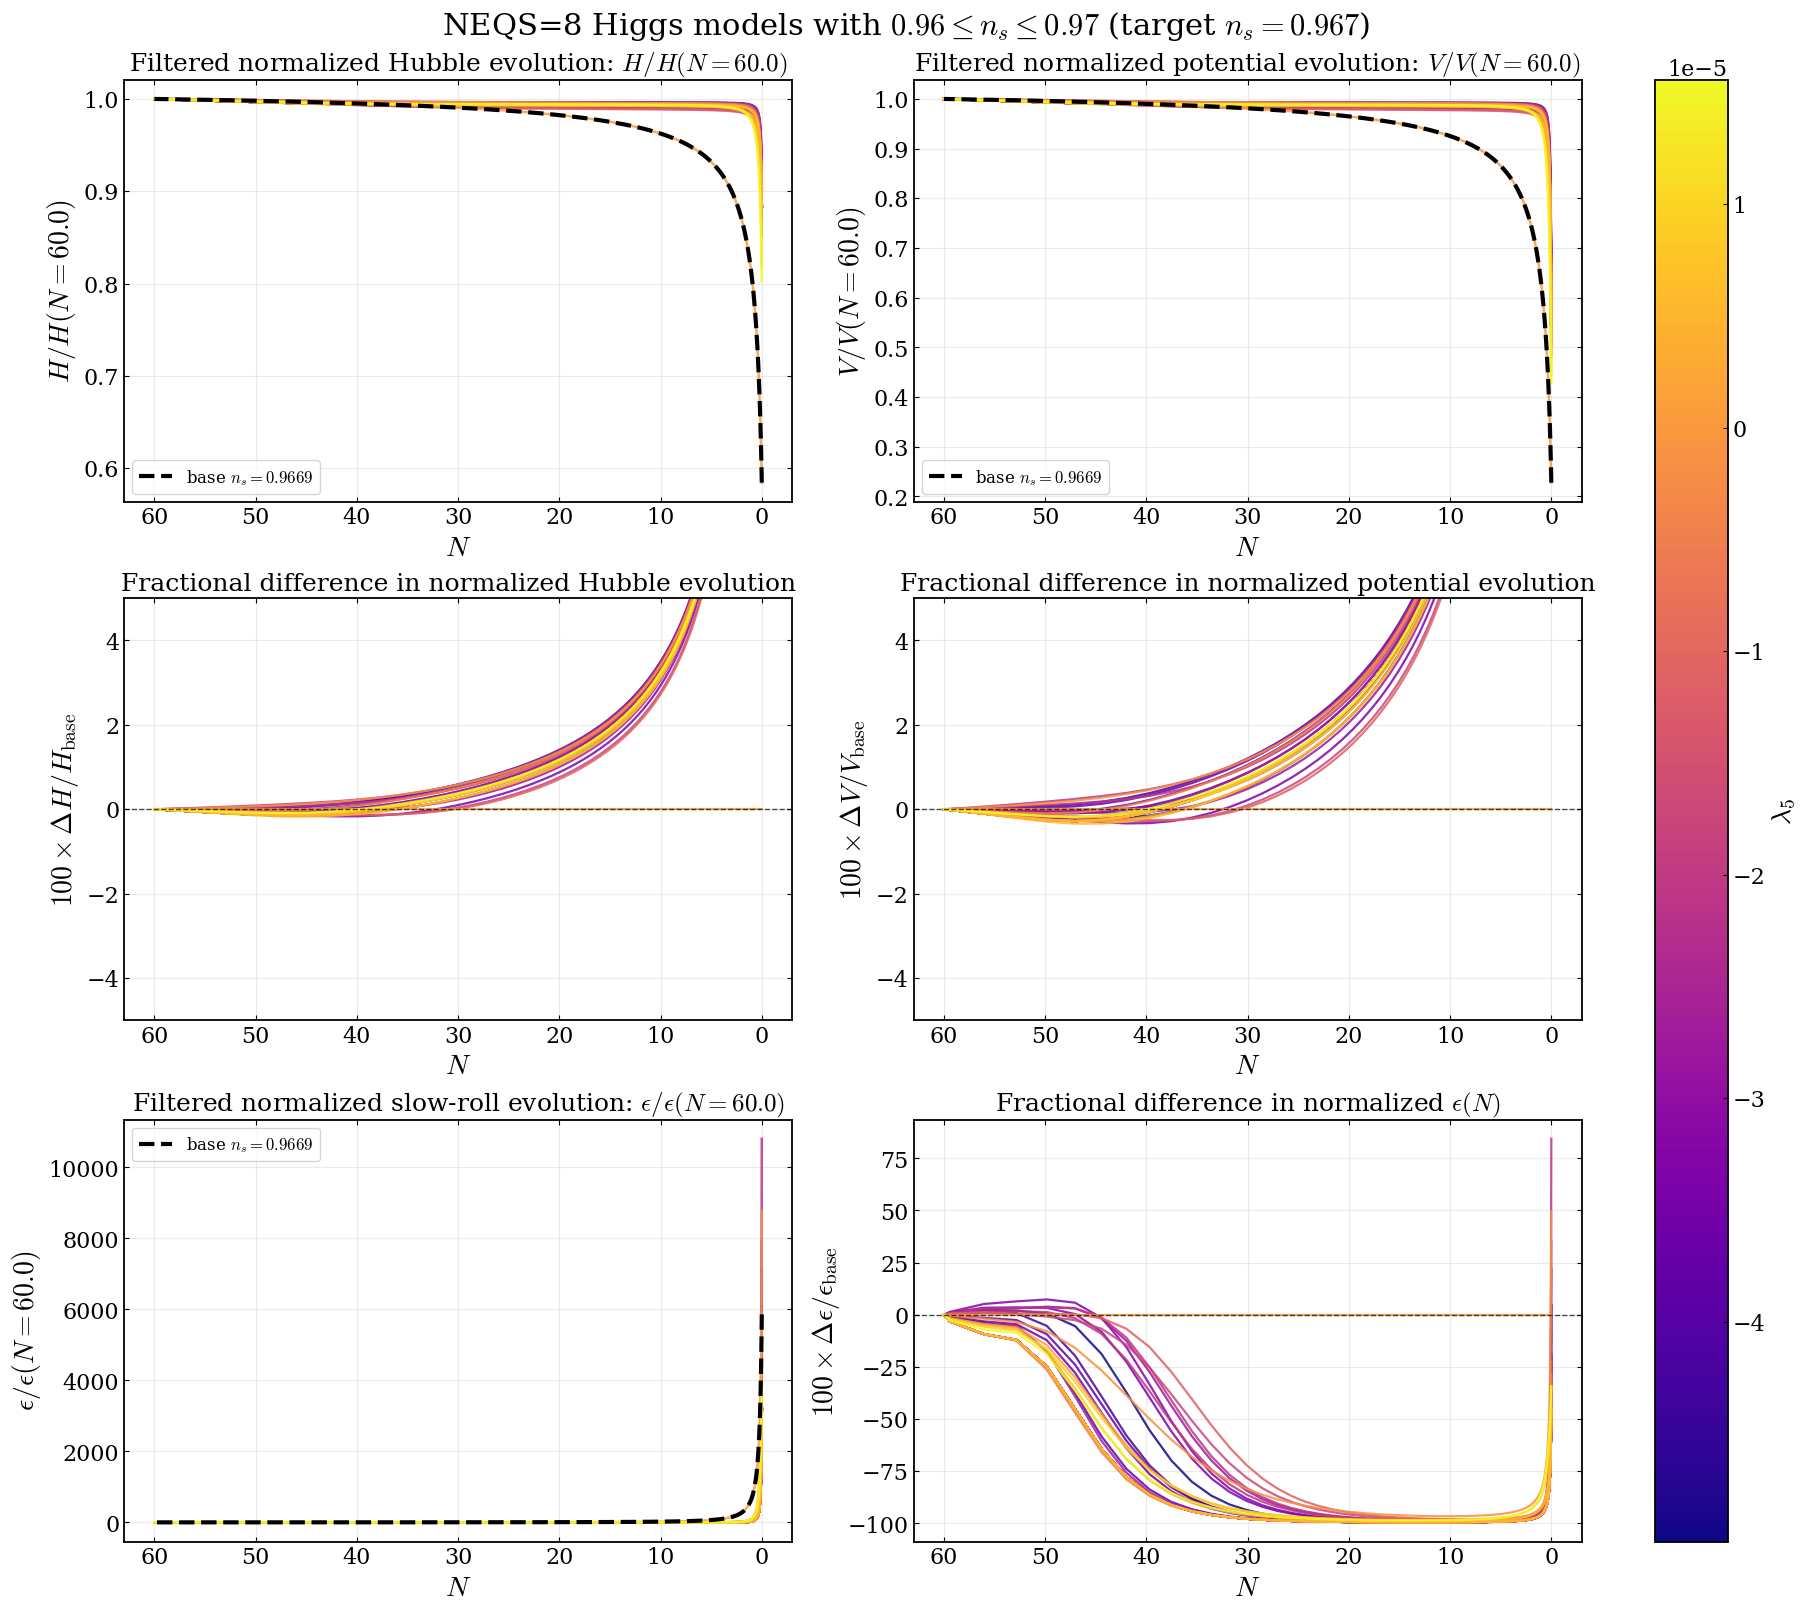

In [16]:
# BACKGROUND_PLOT_CONFIG = {
#     "higgs": {
#         "base_value": -8.92461e-9,
#         "ns_target": 0.967,
#         "save_name": (
#             "paper_higgs_neqs8_lam5_"
#             "filtered_background.pdf"
#         ),
#     },

#     "nonhiggs": {
#         "base_value": -3.3792701497e-5,
#         "ns_target": 0.967,
#         "save_name": (
#             "paper_nonhiggs_neqs8_lam5_"
#             "filtered_background.pdf"
#         ),
#     },
# }

BACKGROUND_PLOT_CONFIG = {
    "higgs": {
        "base_value": -8.92461e-9,
        "ns_target": 0.967,
        "save_name": (
            "paper_higgs_neqs8_lam5_"
            "filtered_background.pdf"
        ),
    }}

background_results = {}

for model_tag, config in BACKGROUND_PLOT_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Running background analysis: "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    lam5_values = param_values_by_model[model_tag][8]

    background_results[model_tag] = (
        plot_filtered_background_by_ns(
            NEQS=8,
            lamX_values=lam5_values,
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,
            ns_target=config["ns_target"],

            N_ref=60.0,
            N_window=(0, 60),

            frac_ylim=(-5, 5),
            eps_frac_ylim=None,

            save_name=config["save_name"],
        )
    )

In the plots above, EVERY curve is normalized at unitu at N=60. I am comparing relative evolution away from the CMB point, not the absolute background shapes here.

# Analyzing Parameter Relationships


One of the things I am seeing by comparing these models, is that fact that, before this section you can see that the $\Delta N$ when accounted for in Higgs case, reduces the Scalar Power spectra more so than the Deformed Quadratic Potential. **Why is that?** My suspiciton is that higher order parameters play a bigger role in mishaping the potential of the Quadratic Potential. Higgs is very flat early on and for a long time, it is like a plateau model, that is not the case with the deformed quadratic potential. So, effectively, under higher order flow perturbations the Higgs potential is more dynamically rigid, whereas it is possible that the deformed-qudratic may have more trajectory/shape freedom even when the total inflationary duration remains similar. You can also see this just by looking at the spread of the first slow roll parameter, $\epsilon$, for the Deformed Quadratic model vs the Higgs one.

In [17]:
def plot_filtered_V_vs_delta_phi(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    model_tag="higgs",
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=None,
    N_ref=60.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    
    #setup and scan appropriate lam
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    # Load summaries only once
    summary_all = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

#     def sanitize_lam_values(values):
#         return np.array(
#             [
#                 item[0] if isinstance(item, tuple) else item
#                 for item in values
#             ],
#             dtype=float,
#         )

    def get_summary_row(value):
        matches = summary_all.loc[
            np.isclose(
                summary_all[scan_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-10),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row found for "
                f"{scan_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0] #again if multiple rows match, it'll use the first one :0

#     #code below is a duplicate of load_path_data from earlier 
#     def load_path(value):
#         val_str = f"{value:.10e}"

#         folder = folder_for(
#             NEQS=NEQS,
#             param_name=scan_name,
#             value=value,
#             base_path_root=base_path_root,
#             model_tag=model_tag,
#         )

#         file_path = os.path.join(
#             str(folder),
#             f"path_neqs{NEQS}_{scan_name}_{val_str}.dat",
#         )

#         if not os.path.exists(file_path):
#             raise FileNotFoundError(
#                 f"Missing path file: {file_path}"
#             )

#         return pd.read_csv(
#             file_path,
#             sep=r"\s+",
#             header=None,
#         ).values

   #code below is a duplicate of load_path_data from earlier 
    def load_path(value):
        val_str = f"{value:.10e}"

        folder = folder_for(
            NEQS=NEQS,
            param_name=scan_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        path_matches = list(
            folder.glob(
                f"path_neqs{NEQS}_lam2_*_lam3_*_lam4_*_lam5_*.dat"
            )
        )

        if not path_matches:
            raise FileNotFoundError(
                f"Missing path file inside: {folder}"
            )

        file_path = path_matches[0]

        if not os.path.exists(file_path):
            raise FileNotFoundError(
                f"Missing path file: {file_path}"
            )

        return pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
        ).values


    
    #the goal here is to define a deltaphi such that deltaphi = phi(for model)- phi(Nref)
    #and similarly get normalized V = V/V(Nref)
    def get_aligned_V_phi(data):
        """
        Return V/V(N_ref) as a function of

            delta_phi = phi - phi(N_ref).

        The trajectory is first ordered using N so phi, V, and N remain
        physically paired.
        """
        
        #first i extract columns
        phi_raw = np.asarray(
            data[:, 0],
            dtype=float,
        )

        N_raw = np.asarray(
            data[:, NEQS],
            dtype=float,
        )

        V_raw = np.asarray(
            data[:, NEQS + 1],
            dtype=float,
        )

        #make sure all are finite
        finite = (
            np.isfinite(phi_raw)
            & np.isfinite(N_raw)
            & np.isfinite(V_raw)
        )

        phi_raw = phi_raw[finite]
        N_raw = N_raw[finite]
        V_raw = V_raw[finite]

        
        #make sure there are at least 2 point
        if len(N_raw) < 2:
            raise ValueError(
                "Not enough finite path points."
            )

        # Preserve trajectory ordering
        #cal difference in N, check to make sure it consistent
        dN = np.diff(N_raw)

        if np.all(dN >= 0):
            N_use = N_raw
            phi_use = phi_raw
            V_use = V_raw
        
        #if it is not, flip N and correspondingly flip phi and V
        elif np.all(dN <= 0):
            N_use = N_raw[::-1]
            phi_use = phi_raw[::-1]
            V_use = V_raw[::-1]

        else:
            raise ValueError(
                "N is non-monotonic; refusing to reorder trajectory" #wont use if nonmonotonic
            )

        #make sure Nref lies inside of trajectory range
        if not (
            N_use.min()
            <= N_ref
            <= N_use.max()
        ):
            raise ValueError(
                f"N_ref={N_ref} outside range "
                f"[{N_use.min():.4f}, {N_use.max():.4f}]"
            )

        # Determine pivot values by interpolating. So finding phi_ref and then V_ref
        phi_ref = np.interp(
            N_ref,
            N_use,
            phi_use,
        )

        V_ref = np.interp(
            N_ref,
            N_use,
            V_use,
        )

        #make sure both variable are valid
        if not np.isfinite(phi_ref):
            raise ValueError(
                f"Non-finite phi at N_ref={N_ref}."
            )

        if (
            not np.isfinite(V_ref)
            or abs(V_ref) < 1e-30
        ):
            raise ValueError(
                f"Invalid V_ref at N_ref={N_ref}: "
                f"{V_ref}"
            )

        #define that delta phi and normalized V
        #so at ref point Nref, deltaphi=0 and Vnorm=1
        delta_phi = phi_use - phi_ref
        V_norm = V_use / V_ref

        # Check monotonicity of the field trajectory
        #ensures final output is order by increasing delta
        dphi = np.diff(delta_phi)

        if np.all(dphi >= 0):
            return delta_phi, V_norm, phi_ref

        if np.all(dphi <= 0):
            return (
                delta_phi[::-1],
                V_norm[::-1],
                phi_ref,
            )

        raise ValueError(
            "phi is non-monotonic, so V(phi) is multivalued."
        )

    # Load base trajectory
    base_row = get_summary_row(baseX)
    base_data = load_path(baseX)

    delta_phi_base, V_base, phi_ref_base = (
        get_aligned_V_phi(base_data)
    )

    # Load accepted models
    models = [] #create empty array
    
    #loop over candidate models and check their observables
    for lamX in sanitize_lam_values(lamX_values):
        try:
            row = get_summary_row(lamX)

            ns = float(row["n_s"])
            r = float(row["r"])
            alpha_s = float(row["alpha_s"])
            N_end = float(row["original_N_end"])
            
            
            #apply cuts
            if not (ns_min <= ns <= ns_max):
                continue

            if r_min is not None and r < r_min:
                continue

            if r_max is not None and r > r_max:
                continue

            if (
                max_abs_alpha_s is not None
                and abs(alpha_s) > max_abs_alpha_s
            ):
                continue

                
            #load and align accepted models
            data = load_path(lamX)

            #every model gets aligned at its own ref point phi(Nref) and V(Nref)
            #so really we are looking at the variation in shape relative to each model's pivot point
            delta_phi, V_norm, phi_ref = (
                get_aligned_V_phi(data)
            )

            #store the model data!!
            models.append({
                "lamX": lamX,
                "delta_phi": delta_phi,
                "V_norm": V_norm,
                "phi_ref": phi_ref,
                "delta_phi_total": (
                    np.nanmax(delta_phi)
                    - np.nanmin(delta_phi)
                ),
                "N_end": N_end,
                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,
            })

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {scan_name}={lamX:.5e}: {exc}"
            )

    if not models:
        raise ValueError(
            f"No {model_label} models passed the cuts."
        )

    # Plot
    N_end_values = np.array([
        model["N_end"]
        for model in models
    ])

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.nanmin(N_end_values),
        vmax=np.nanmax(N_end_values),
    )

    fig, ax = plt.subplots(
        figsize=(10, 7),
        constrained_layout=True,
    )

    for model in models:
        ax.plot(
            model["delta_phi"],
            model["V_norm"],
            color=cmap(norm(model["N_end"])),
            linewidth=1.6,
            alpha=0.8,
        )

    # Base model
    ax.plot(
        delta_phi_base,
        V_base,
        color="black",
        linewidth=3.0,
        linestyle="--",
        label=(
            rf"Base model, "
            rf"$n_s={float(base_row['n_s']):.4f}$"
        ),
    )

    # Common CMB reference point label
    ax.scatter(
        0.0,
        1.0,
        color="black",
        s=55,
        zorder=10,
        label=rf"$N={N_ref:g}$ reference",
    )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        pad=0.02,
    )

    cbar.set_label(
        r"$N_{\rm end}^{\rm original}$"
    )

    ax.axvline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.65,
    )

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.65,
    )

    ax.set_xlabel(
        rf"$\Delta\phi=\phi-\phi(N={N_ref:g})$"
    )

    ax.set_ylabel(
        rf"$V(\phi)/V(N={N_ref:g})$"
    )

    ax.set_title(
        rf"{model_label}: pivot-aligned reconstructed potentials"
        "\n"
        rf"${ns_min}\leq n_s\leq {ns_max}$"
    )

    ax.grid(True, alpha=0.25)

    ax.legend(
        frameon=False,
        loc="best",
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{model_tag}_{scan_name}_"
            f"V_vs_delta_phi.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return models


Plotting pivot-aligned V(phi): Higgs
Skipping lam5=-3.66273e-05: No summary row found for lam5=-3.6627303021e-05, model=higgs


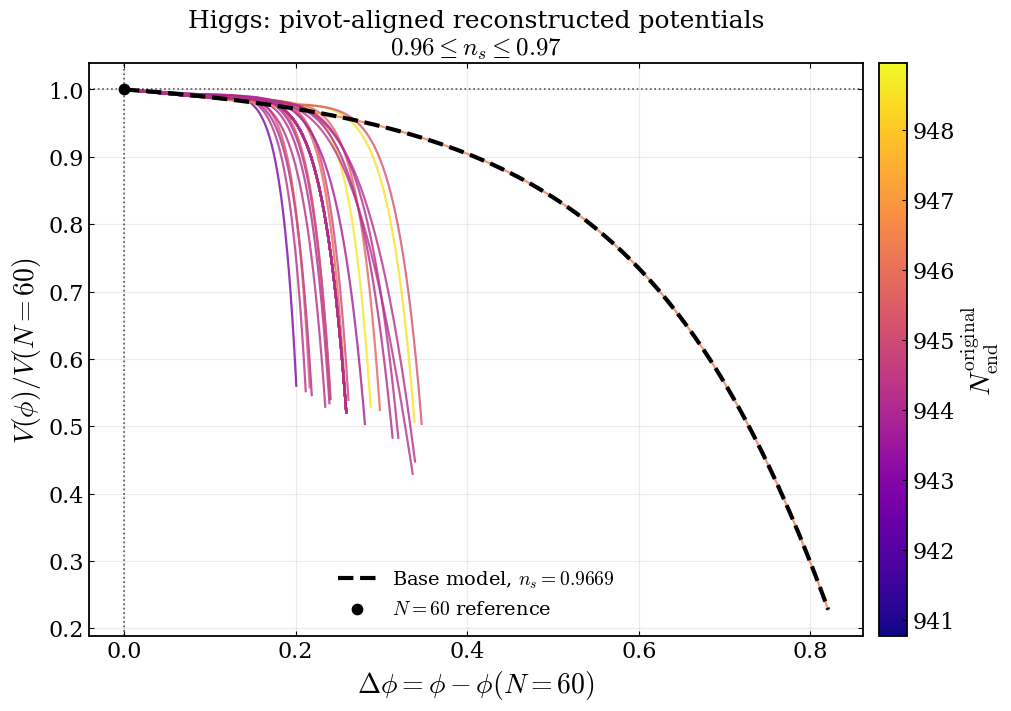

In [18]:
# VPHI_ALIGNED_CONFIG = {
#     "higgs": {
#         "base_value": -8.92461e-9,
#         "r_min": 2.737e-3 - 0.001,
#         "r_max": 2.737e-3 + 0.001,
#         "save_name": (
#             "paper_higgs_V_vs_delta_phi.pdf"
#         ),
#     },

#     "nonhiggs": {
#         "base_value": -3.3792701497e-5,
#         "r_min": 3.2958886892e-2 - 0.001,
#         "r_max": 3.2958886892e-2 + 0.001,
#         "save_name": (
#             "paper_nonhiggs_V_vs_delta_phi.pdf"
#         ),
#     },
# }


VPHI_ALIGNED_CONFIG = {
    "higgs": {
        "base_value": -8.92461e-9,
        "r_min": 0.003664125 - 0.002,
        "r_max": 0.003664125 + 0.002,
        "save_name": (
            "paper_higgs_V_vs_delta_phi.pdf"
        ),
    }}

Vphi_aligned_results = {}

for model_tag, config in VPHI_ALIGNED_CONFIG.items():

    print("\n" + "=" * 70)
    print(
        f"Plotting pivot-aligned V(phi): "
        f"{MODEL_CONFIG[model_tag]['label']}"
    )
    print("=" * 70)

    Vphi_aligned_results[model_tag] = (
        plot_filtered_V_vs_delta_phi(
            NEQS=8,
            lamX_values=param_values_by_model[model_tag][8],
            baseX=config["base_value"],
            base_path_root=base_path_root,
            model_tag=model_tag,

            ns_min=0.96,
            ns_max=0.97,

            r_min=config["r_min"],
            r_max=config["r_max"],

            max_abs_alpha_s=0.0063,

            N_ref=60.0,

            save_name=config["save_name"],
        )
    )

The plot above for the potentials as a function of teh field basically, are *Normalized Inflationary Potentials aligned at the CMB Pivot*. So each reconstructed potential is shifted such that $\phi(N_{ref}) =0$ and normalized by its respective value at the pivot, $V(\phi)/V(N_{ref})$ where $N_{ref}=60$. Doing so removes any arbitrary field offsets and potential normalizations, allowing the intrinsic differences in potential shape near the observable window to be compared more effectively. The reconstruction algorithm is essentially finding many potentials that are locally indistinguishable from Higgs around the pivot, but which differ once inflation progresses away from the observable scales. Whereas it seems that the Deformed Quad model seems to vary parameters that are perturbing the potential without necessarily leaving that fiducial trajectory.

**For Higgs:**
I am seeing that $V(\phi)$ for Higgs model base samples to 0.8. Whereas the other Higgs models found only sample to 0.2 in $\phi$.


**For Deformed Quad:**
The base for the deformed quadratic sits rather comfortably in the sample phi region!


## Impact of Higher Order Parameters on Spectra

Assuming:

$D_s = median |100*\frac{P^s_{shifted} - P^s_{ref}}{P^s_{ref}}|$

$D_t = median |100*\frac{P^t_{shifted} - P^t_{ref}}{P^t_{ref}}|$


First, let's confirm everything saved inside of **spectral results**.

In [25]:
##Tells me what is inside of spectral results

print(
    spectral_results["higgs"]["models"].columns.tolist()
)


['NEQS', 'param_name', 'value', 'lam2', 'lam3', 'lam4', 'lam5', 'r', 'ns', 'alpha_s', 'original_N_end', 'deltaN_from_ref_base', 'abs_deltaN_from_ref_base', 'D_s_unshift', 'D_s_shift', 'D_t_unshift', 'D_t_shift', 'D_s', 'D_t']


In [26]:
spectral_results["higgs"]["models"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_s_unshift",
        "D_s_shift",
        "D_t_unshift",
        "D_t_shift",
    ]
].head()

,lam2,lam3,lam4,lam5,D_s_unshift,D_s_shift,D_t_unshift,D_t_shift
0,0.000279,-0.000026,6.870650e-08,-8.924610e-09,0.000000,1.528164,0.000000,0.441522
1,0.000279,-0.000021,6.870650e-08,-8.924610e-09,0.000000,1.495925,0.000000,0.378810
2,0.000279,-0.000021,6.870650e-08,-8.924610e-09,0.000000,1.495925,0.000000,0.378810
3,0.000279,-0.000016,6.870650e-08,-8.924610e-09,0.405641,0.204158,0.203936,0.006886
4,0.000279,-0.000011,6.870650e-08,-8.924610e-09,0.000000,0.221595,0.000000,0.155607


In [28]:
# print(
#     spectral_results["nonhiggs"]["models"].columns.tolist()
# )

In [29]:
# spectral_results["nonhiggs"]["models"][
#     [
#         "lam2",
#         "lam3",
#         "lam4",
#         "lam5",
#         "D_s_unshift",
#         "D_s_shift",
#         "D_t_unshift",
#         "D_t_shift",
#     ]
# ].head()

 Now, I can proceed to looking at the spectral distance in terms of the higher order parameters.

In [30]:
#OKAY this function compares spectral distance measures Ds and Dt to hierarchy parameters! 
#This is AFTER is applied so these values have accounted for that discrepancy


#Let's say I am looking at lamX and Dx but I have hundreds of models, each model will give me 1 point of lamx, Dx
#Code draws those points first
#Then it splits lamX range into 12 equal-width chunks (so x)
#So every model is assigned to one of those bins
#Can ask, among all models with similar lamX, what is typical spectral distance?
#So in each bin it selects the corresponding Ds/Dt and finds median of models in that bin
#And also find 68% or central spread
#Then it connext all valid bin medians
#If I increase the number of bins, you get more median points, but each median is based on fewer models.
#Since this is after shifting, any high Dx shows me remaining spectral differences in my models
#And then in this plot we are looking at which slow roll parameters are associated with those spectral differences

def plot_spectral_distance_vs_hierarchy(
    model_df,
    model_tag,
    parameter_columns=("lam2","lam3", "lam4", "lam5"),
    distance_columns=("D_s", "D_t"),
    n_bins=12,
    min_models_per_bin=3,
    color_by=None,
    tolerance=5.0,
    save_name=None,
    show=True,
):
    """
    Plot spectral distance versus higher-order flow parameters.

    Parameters
    model_df : DataFrame
        Must contain lam2/lam3/lam4/lam5 and D_s/D_t

    distance_columns : tuple
        Usually ("D_s","D_t"). Can use shifted or unshifted if I want
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)
    
    #makes union of these two sets of param and Ds/Dt
    required = set(parameter_columns) | set(distance_columns)

    #color may be included :)
    if color_by is not None:
        required.add(color_by)

    #also want to make sure in column is deltaN_from_base
    missing = required.difference(model_df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    #now copies this so it doesnt change original dataframe
    df = model_df.copy()

    
    #applies mask of trues same length as df
    mask = np.ones(len(df), dtype=bool)

    #it must all be finite so no Nans/Infs
    for col in required:
        mask &= np.isfinite(df[col])

    df = df.loc[mask].copy()

    #control axis labels
    parameter_labels = {
        "lam2": r"$^{2}\lambda_H$",
        "lam3": r"$^{3}\lambda_H$",
        "lam4": r"$^{4}\lambda_H$",
        "lam5": r"$^{5}\lambda_H$",
    }

    distance_labels = {
        "D_s": r"$D_s$ (%)",
        "D_t": r"$D_t$ (%)",
    }

    fig, axes = plt.subplots(
        len(distance_columns),
        len(parameter_columns),
        figsize=(18,10),
        constrained_layout=True,
        sharey="row",
    ) #subplot dimension are sized according to all param and Ds Dt

    axes = np.asarray(axes).reshape(
        len(distance_columns),
        len(parameter_columns),
    )

    # Optional colouring: each scatter point should be colored by deltaN_end. Pos/neg have diff positions on color map
    if color_by is not None:

        norm = mcolors.Normalize(
            vmin=df[color_by].min(), #if every model has same deltaN_from_base, color scale will be degenerate
            vmax=df[color_by].max(),
        )

        cmap = plt.cm.viridis

    else:

        norm = None
        cmap = None

    binned_rows = [] #empty array to store stats

    # Loop over λ3 λ4 λ5
    for j, parameter in enumerate(parameter_columns):

        x = df[parameter].to_numpy() #extracts array of param

        edges = np.linspace(
            x.min(),
            x.max(),
            n_bins + 1,
        ) #makes bin edges so is n_bins=12 then this is n_bins+1

        #computes midpoint of each bin, equal width bins in param value
        centers = 0.5 * (
            edges[:-1] + edges[1:]
        )

        #assign every model to a bin, returns integers from 0-ll for 12 bins. 
        #each model gets a bin according to its param value
        which_bin = np.digitize(
            x,
            edges[1:-1],
        )
        
        #loop over Ds and Dt
        for i, distance in enumerate(distance_columns):

            ax = axes[i, j]

            y = df[distance].to_numpy()

            
            # Scatter
            if color_by is None:

                ax.scatter(
                    x,
                    y,
                    s=24,
                    alpha=0.45,
                )

            else:
                #each model becomes one point (lamx, Dx) where the color represents deltaN
                ax.scatter(
                    x,
                    y,
                    c=df[color_by],
                    cmap=cmap,
                    norm=norm,
                    s=28,
                    alpha=0.6,
                )

            # Median trend: initialize blind first 
            med = np.full(n_bins, np.nan)
            p16 = np.full(n_bins, np.nan)
            p84 = np.full(n_bins, np.nan)

            #analyze each bin.
            for b in range(n_bins):

                m = which_bin == b #m is boolean selecting models in bin b

                #before median is calcuated a bin must contain at least 3 models before median or percentiles are recorded
                if np.sum(m) < min_models_per_bin:
                    continue

                #selects Ds or Dt belonging to that parameter bin
                vals = y[m]

                #then get median spectral distance and central 68%
                med[b] = np.nanmedian(vals)
                p16[b] = np.nanpercentile(vals,16)
                p84[b] = np.nanpercentile(vals,84)

                #store bin results
                binned_rows.append({

                    "model_tag": model_tag,
                    "parameter": parameter,
                    "distance": distance,
                    "bin_center": centers[b],
                    "count": np.sum(m),
                    "median": med[b],
                    "p16": p16[b],
                    "p84": p84[b],
                })

            #draw the median trend
            valid = np.isfinite(med)

            if np.any(valid):
                #supposed to be 68 % spread
#                 ax.fill_between(
#                     centers[valid],
#                     p16[valid],
#                     p84[valid],
#                     alpha=0.20,
#                 )

                ax.plot(
                    centers[valid],
                    med[valid],
                    "-o",
                    lw=2,
                    ms=5,
                )

            if tolerance is not None:

                ax.axhline(
                    tolerance,
                    color="black",
                    ls="--",
                    lw=1.3,
                    alpha=0.6,
                )

            ax.grid(alpha=0.25)

            ax.set_xlabel(
                parameter_labels.get(
                    parameter,
                    parameter,
                )
            )

            if j == 0:

                ax.set_ylabel(
                    distance_labels[distance]
                )

            if i == 0:

                ax.set_title(
                    parameter_labels.get(
                        parameter,
                        parameter,
                    )
                )

    if color_by is not None:

        sm = ScalarMappable(
            norm=norm,
            cmap=cmap,
        )

        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=axes,
            pad=0.01,
        )

        cbar.set_label(color_by)

    fig.suptitle(
        rf"{model_label}: spectral distance versus higher-order flow parameters",
        fontsize=20,
    )

    if save_name is None:

        save_name = (
            f"{model_tag}_DsDt_vs_hierarchy.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return (
        df,
        pd.DataFrame(binned_rows),
    )

For Higgs:

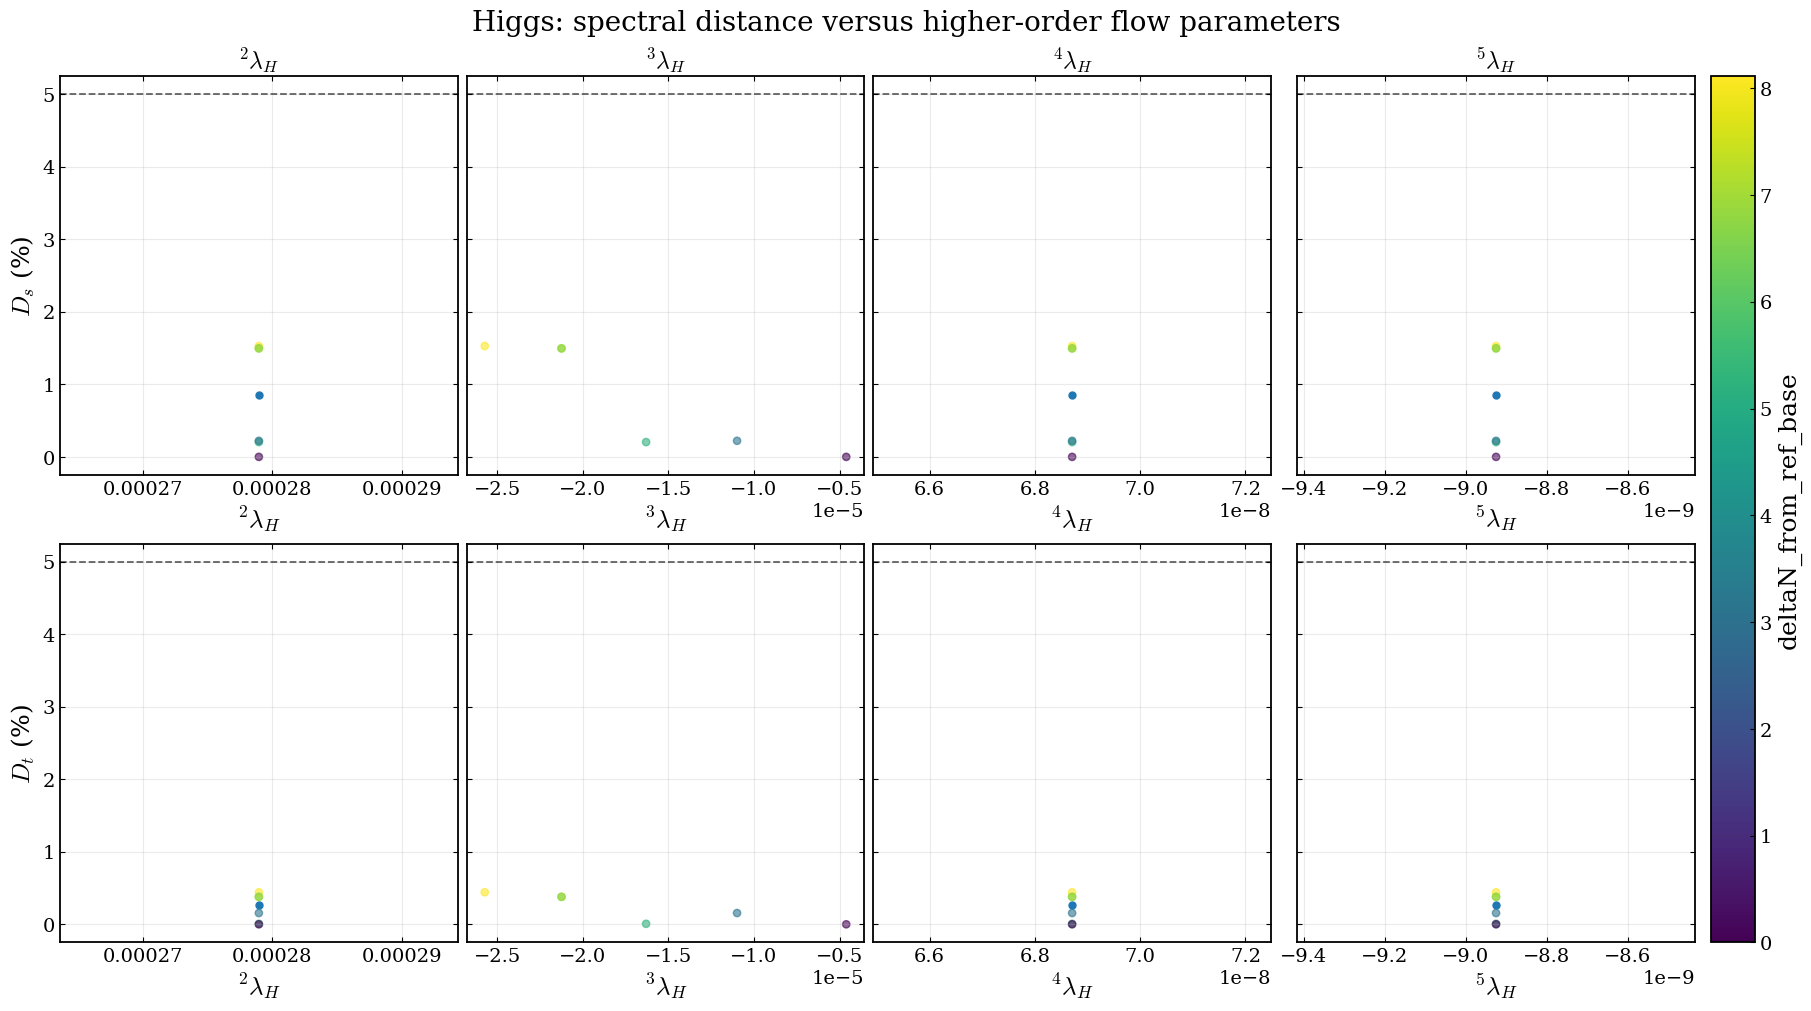

In [31]:
higgs_distance_df, higgs_binned_df = (
    plot_spectral_distance_vs_hierarchy(
        model_df=spectral_results["higgs"]["models"],
        model_tag="higgs",

        parameter_columns=(
            "lam2",
            "lam3",
            "lam4",
            "lam5",
        ),

        n_bins=20,
        min_models_per_bin=3,

        color_by="deltaN_from_ref_base",
        tolerance=5.0,

        save_name=(
            "paper_higgs_Ds_Dt_"
            "vs_lam2_lam3_lam4_lam5.pdf"
        ),
    )
)

For Deformed Quad:

In [32]:
# nonhiggs_distance_df, nonhiggs_binned_df = (
#     plot_spectral_distance_vs_hierarchy(
#         model_df=spectral_results["nonhiggs"]["models"],
#         model_tag="nonhiggs",

#         parameter_columns=(
#             "lam2",
#             "lam3",
#             "lam4",
#             "lam5",
#         ),

#         n_bins=20,
#         min_models_per_bin=3,

#         color_by="deltaN_from_ref_base",
#         tolerance=5.0,

#         save_name=(
#             "paper_nonhiggs_Ds_Dt_"
#             "vs_lam2_lam3_lam4_lam5.pdf"
#         ),
#     )
# )

This is hard to read, so I am going to look at some Pearson and maybe Spearman coeffcients. 

In [33]:
from scipy.stats import pearsonr, spearmanr

##This function takes parameters and distances into account so there are
## currenlt 10 correlation calculation.
#It basically sks how does each hierarchy parameter correlate with Ds and Dt?

def hierarchy_correlations(
    model_df,
    parameters=("lam2","lam3", "lam4", "lam5", "deltaN_from_ref_base"),
    distances=("D_s", "D_t"),
):
    """
    Compute Pearson and Spearman correlations between
    hierarchy parameters and spectral distances.
    """
#I generate rows first
    rows = []
#And then for every param and distance we define a pair
#That pair must have at least a few points
    for param in parameters:
        for dist in distances:

            df = model_df[[param, dist]].dropna()

            if len(df) < 3:
                continue
#These are then converted to arrays
            x = df[param].to_numpy()
            y = df[dist].to_numpy()

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_rho, spearman_p = spearmanr(x, y)

#The above should return r (pearson correlation coefficient and the p value)
#It should also return rho and the spearman p as well
#Both should be in agreement with each other. One test linearity the other monotinicity

#Then append the rows
            rows.append({
                "parameter": param,
                "distance": dist,
                "N": len(df),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_rho": spearman_rho,
                "spearman_p": spearman_p,
            })

#convert into table and print
    results = pd.DataFrame(rows)

    print(results.round(4))

    return results

#Note if parameter is constant or nearly const, may return nan and warn correlation is undefined


The tables below represent a correlation test between different high order parameters and the absolute percent difference in the unshifted spectra relative to the base. So, we are trying to look at how changing this paramter relates to the spectrum.


The first parameter (lamX) is compared to either Ds or Dt (dependent variable). It looks then at the number of models for this comparison. Following this, we examine pearson r and pearson p. Pearson r measures linear correlation:

    r=1 is perfectly correlated

    r=0 is no linear relationship

    r=-1 is perfectly negatively correlated

Pearson p-value is not the strength of the correlation but rather how likely it is for this relationship to exist. If p is less than maybe 0.05 it is statistically significant and if it is greater 0.05 then you can't really claim a correlation. It is testing validity of claim I guess.

[Most of my pearson p below are above the 0.05 for at least Higgs case]

Then Spearman $\rho$ is testing monotonicity of variables, so asking does it generally increase or decrease? Pays less attention to shape. 

    +1 is perfect monotonic increase

    0 is no linear trend

    -1 is perfect monotonic decrease
    
Spearman p is same as Pearson p, confirming or denying how confident one is about the trend.

For Higgs:

In [34]:
corr_higgs = hierarchy_correlations(
    spectral_results["higgs"]["models"]
)

              parameter distance  N  pearson_r  pearson_p  spearman_rho  \
0                  lam2      D_s  6        NaN        NaN           NaN   
1                  lam2      D_t  6        NaN        NaN           NaN   
2                  lam3      D_s  6    -0.8944     0.0161       -0.9412   
3                  lam3      D_t  6    -0.8499     0.0321       -0.9412   
4                  lam4      D_s  6        NaN        NaN           NaN   
5                  lam4      D_t  6        NaN        NaN           NaN   
6                  lam5      D_s  6        NaN        NaN           NaN   
7                  lam5      D_t  6        NaN        NaN           NaN   
8  deltaN_from_ref_base      D_s  6     0.8671     0.0253        0.9412   
9  deltaN_from_ref_base      D_t  6     0.8218     0.0448        0.9412   

   spearman_p  
0         NaN  
1         NaN  
2      0.0051  
3      0.0051  
4         NaN  
5         NaN  
6         NaN  
7         NaN  
8      0.0051  
9      0.0051 

/var/folders/r0/8yvh584n2rn3zjvr31j72v3r0000gn/T/ipykernel_2033/1846196209.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, pearson_p = pearsonr(x, y)
/var/folders/r0/8yvh584n2rn3zjvr31j72v3r0000gn/T/ipykernel_2033/1846196209.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_rho, spearman_p = spearmanr(x, y)


Strong Higgs correlations:

    - lam3 and D_t (+)
    - lam4 and D_t (+)
    - deltaN_from_ref_base and D_s (+)

For Quad:

In [35]:
# corr_quad = hierarchy_correlations(
#     spectral_results["nonhiggs"]["models"]
# )

Strong Quad correlations:

    - lam3 and D_t (+)
    - lam4 and D_t (+)
    - lam3 and D_s (+)
    - lam4 and D_s (+)
    - deltaN_from_ref_base and D_t (-)
    - deltaN_from_ref_base and D_s (-)
    

## Generate correlation matrix of variables

Look for high correlations ~ 1

In [36]:
#The cute ass matrix below is mean to ask how do the hierarchy parameters
#correlate with each other and with deltaN?

def plot_hierarchy_correlation_matrix(
    model_df,
    model_tag,
    columns=(
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "deltaN_from_ref_base",
    ),
    method="spearman",
    save_name=None,
):
    """
    Correlation matrix among hierarchy parameters.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    
    #Extracts only requets variables
    df = model_df[list(columns)].copy()

    df = df.dropna() #matrix removed is only one of five col is missing

    
    #choose correlation method
    if method.lower() == "pearson":
        corr = df.corr(method="pearson")
        title = "Pearson"
    else:
        corr = df.corr(method="spearman")
        title = "Spearman"

    rename = {
        "lam2": r"$\lambda_2$",
        "lam3": r"$\lambda_3$",
        "lam4": r"$\lambda_4$",
        "lam5": r"$\lambda_5$",
        "deltaN_from_ref_base": r"$\Delta N$",
    }

    corr = corr.rename(
        index=rename,
        columns=rename,
    )

    fig, ax = plt.subplots(figsize=(7,6))

    im = ax.imshow(
        corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
    ) #cover full range -1,1

    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_yticklabels(corr.index)

    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i,j]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
            )

    cbar = plt.colorbar(
        im,
        ax=ax,
        label=f"{title} correlation",
    )

    cbar.set_label(
        f"{title} correlation",
        fontsize=13,
    )

    ax.set_title(
    f"{model_label}: {title} Correlation Matrix",
    fontsize=13,
)

    if save_name is None:
        save_name = (
            f"{model_tag}_{method.lower()}_correlation_matrix.pdf"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return corr

#matrix tells me exactly what rho or r is for couple relationships
#and what hierarchy relationships are associated with remaining spec diff


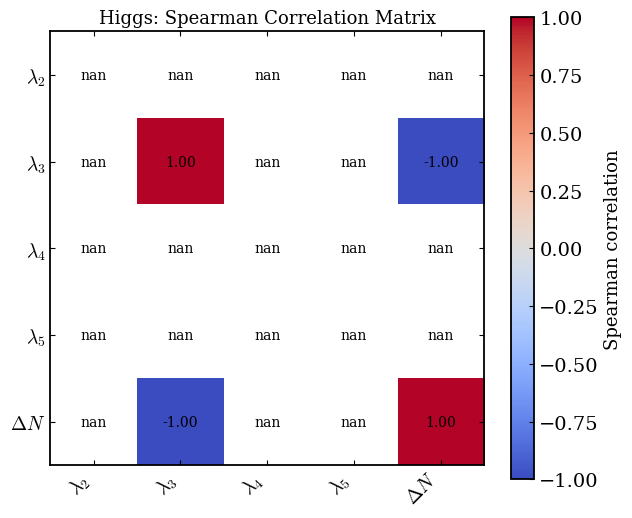

In [37]:
corr_higgs = plot_hierarchy_correlation_matrix(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    method="spearman",
)

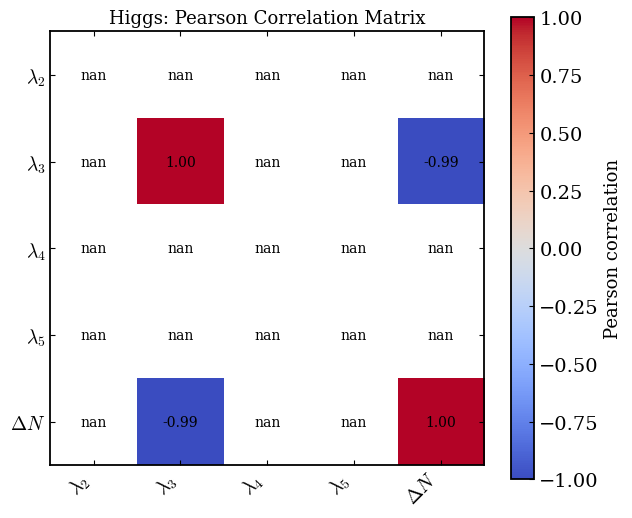

In [38]:
corr_higgs = plot_hierarchy_correlation_matrix(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    method="pearson",
)

In [39]:
# corr_quad = plot_hierarchy_correlation_matrix(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     method="spearman",
# )

In [40]:
# corr_quad = plot_hierarchy_correlation_matrix(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     method="pearson",
# )

Is it the case truly given these numbers that the inflationary duration is more sensitive to changes in the higher order hierarchy for the deformed quadratic model? Is it the case from what we see that for the quad model, perturbations in $\lambda_3$ propogate more efficiently into the background.

$\lambda_3 \rightarrow \lambda_2 \rightarrow \sigma \rightarrow \epsilon$ and where $\epsilon$ ends determines $\Delta N$

Also note and remember, that $r$ for the deformed quadratic is larger than the Higgs model.

## Heatmaps!

In [41]:
from scipy.stats import binned_statistic_2d

def plot_hierarchy_heatmap(
    model_df,
    model_tag,
    x_param,
    y_param,
    value_column,
    bins=15,
    statistic="median",
    cmap="viridis",
    show_counts=False,
    save_name=None,
):

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    df = model_df[
        [x_param, y_param, value_column]
    ].dropna()

    x = df[x_param].values
    y = df[y_param].values
    z = df[value_column].values

    stat, x_edges, y_edges, binnumber = binned_statistic_2d(
        x,
        y,
        z,
        statistic=statistic,
        bins=bins,
    )

    counts, _, _, _ = binned_statistic_2d(
        x,
        y,
        z,
        statistic="count",
        bins=bins,
    )

    fig, ax = plt.subplots(
        figsize=(7,6)
    )

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        stat.T,
        shading="auto",
        cmap=cmap,
    )

    cbar = plt.colorbar(
        im,
        ax=ax,
    )

    cbar.set_label(
        f"{statistic.capitalize()} {value_column}"
    )

    if show_counts:

        xc = 0.5*(x_edges[:-1] + x_edges[1:])
        yc = 0.5*(y_edges[:-1] + y_edges[1:])

        for i in range(len(xc)):
            for j in range(len(yc)):

                if counts[i,j] > 0:

                    ax.text(
                        xc[i],
                        yc[j],
                        int(counts[i,j]),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white",
                    )

    pretty = {
        "lam2":r"$\lambda_2$",
        "lam3":r"$\lambda_3$",
        "lam4":r"$\lambda_4$",
        "lam5":r"$\lambda_5$",
    }

    ax.set_xlabel(pretty.get(x_param,x_param))
    ax.set_ylabel(pretty.get(y_param,y_param))

    ax.set_title(
        f"{model_label}\n"
        f"{statistic.capitalize()} {value_column}"
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_{value_column}_"
            f"{x_param}_{y_param}.pdf"
        )

    plt.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return stat


#Effectively these heatmaps are asking in which regions of the plane
#do models retain large scalar spectral differences after deltaN shift


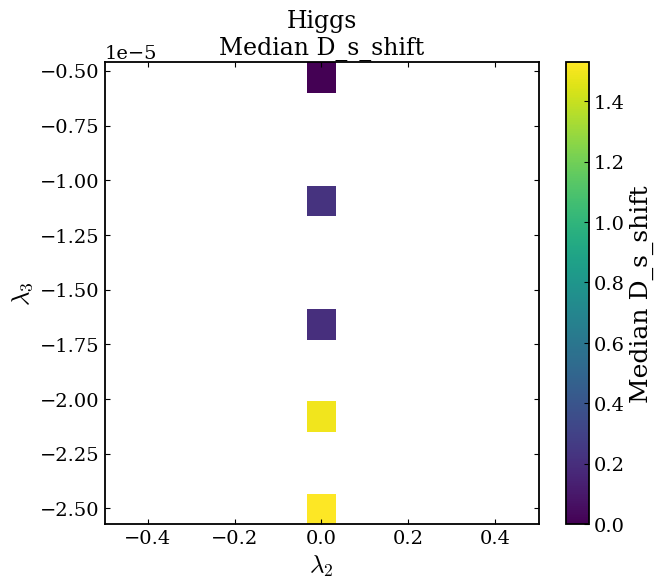

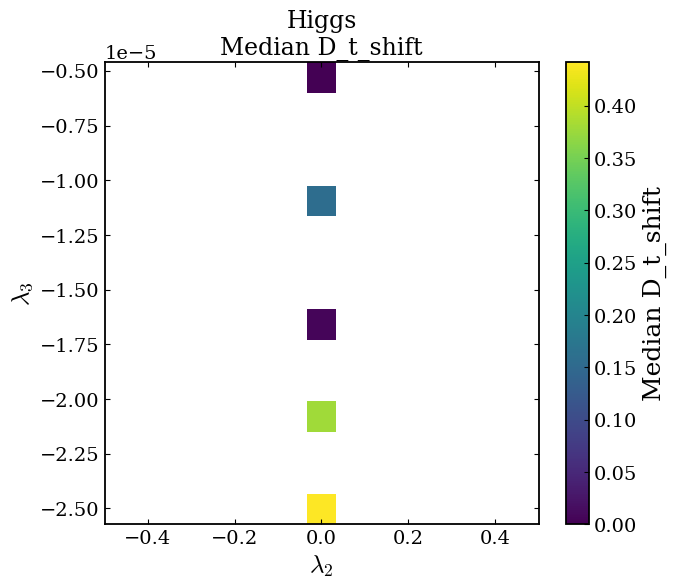

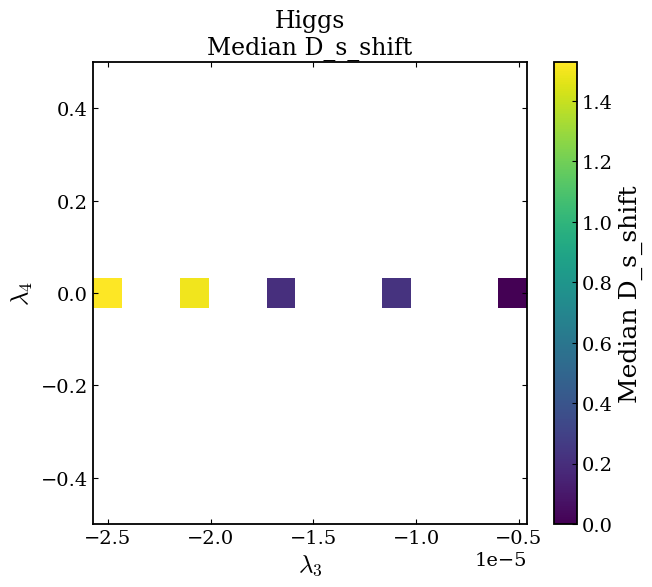

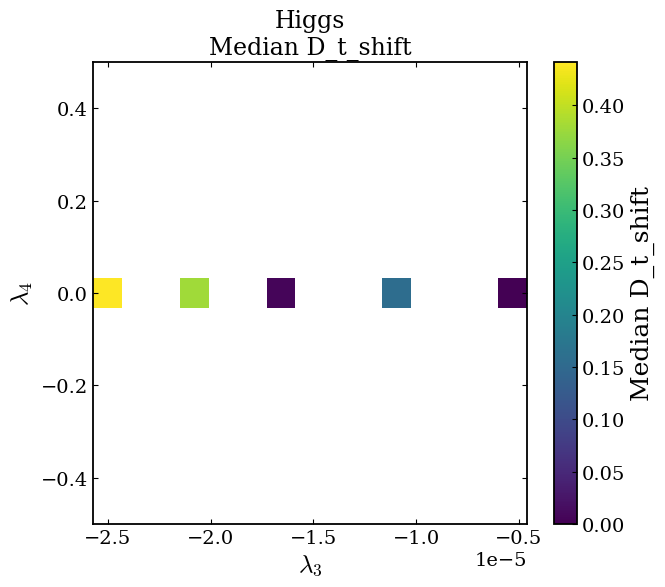

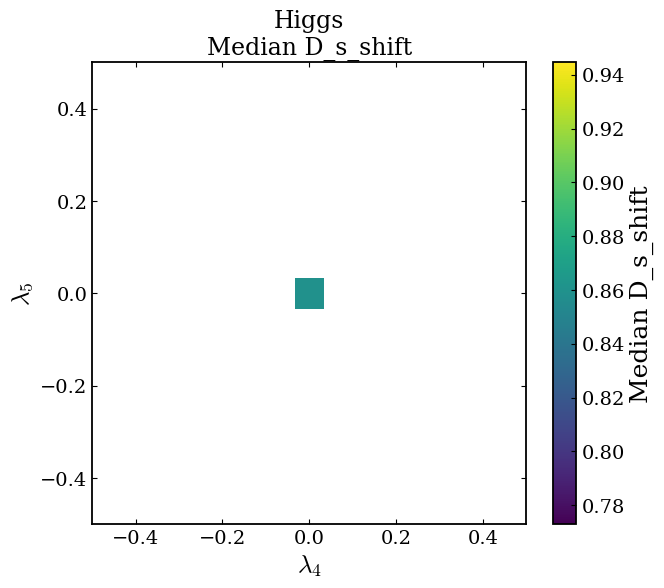

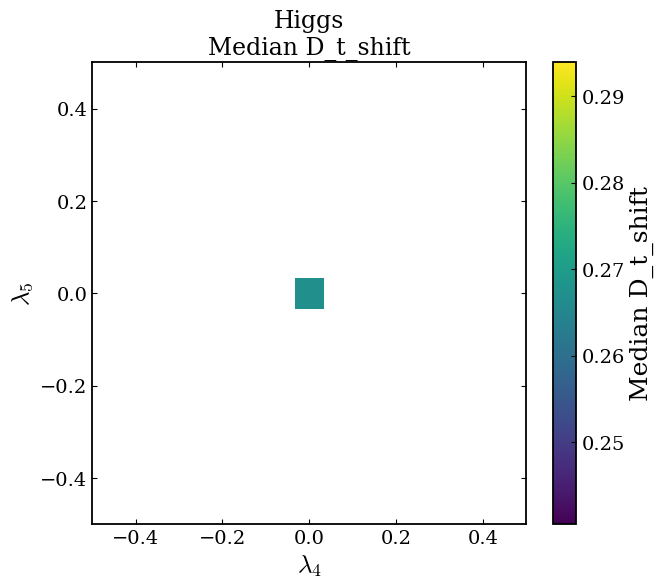

array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan, 

In [42]:
plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_s_shift",
    bins=15,
)


plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam2",
    y_param="lam3",
    value_column="D_t_shift",
    bins=15,
)


plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam3",
    y_param="lam4",
    value_column="D_t_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_s_shift",
    bins=15,
)

plot_hierarchy_heatmap(
    spectral_results["higgs"]["models"],
    model_tag="higgs",
    x_param="lam4",
    y_param="lam5",
    value_column="D_t_shift",
    bins=15,
)

In [43]:
# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam2",
#     y_param="lam3",
#     value_column="D_s_shift",
#     bins=15,
# )

# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam2",
#     y_param="lam3",
#     value_column="D_t_shift",
#     bins=15,
# )


# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam3",
#     y_param="lam4",
#     value_column="D_s_shift",
#     bins=15,
# )

# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam3",
#     y_param="lam4",
#     value_column="D_t_shift",
#     bins=15,
# )

# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam4",
#     y_param="lam5",
#     value_column="D_s_shift",
#     bins=15,
# )

# plot_hierarchy_heatmap(
#     spectral_results["nonhiggs"]["models"],
#     model_tag="nonhiggs",
#     x_param="lam4",
#     y_param="lam5",
#     value_column="D_t_shift",
#     bins=15,
# )



So, is the tensor power spectrum more sensitive to lower order parameters?? I mean I guess higher order param CAN influcence $\epsilon$ . Need to see more.

I know my higher order parameters matter cause they control how the trajectory evolves away from the CMB pivot. I wanna know which higher order param control the extrapolation from the observed CMB region into small scale spectrum. I have to ask:

- Are the models I am looking at in the same family. DeltaN is besr for helping me test this piece since a small DeltaN range means models are not aggressively different. But that DeltaN may mean different ranges for different models?? DeltaN is a family diagnostic.
- How much of the spectral variation is scale misalignment? For higgs and quad, after shifting the spectral variation goes down. But it goes down more for higgs than quad. Why? Likely because higgs is not as impact by higher order param in the same way as quad. Quad has more variation, and more input from higher order param to adjust its shape. The quad case has currently more variation epsilon and thus spectral shape relative to base.
- Which hierarchy param drive the remaining shape variation? Currently it seems that lam3-lam4 drive the sensitivity. lam5 shows little correlation with Ds and Dt. 

In this project CMB fixes local state near the pivot (using r, sigma, etc). Higher order controls continuation away from the pivot. Two models even in the same family can differ far from pivot point. Our next pivot point in the study would be LISA scale. Then PTA. We wanna know what control is happening as we move to these diff scales.

In this case a good multiwavelength model (one that creates a credible band around multi scale spectra):
- Needs to pass CMB consistency
- Must have controlled fam membership with deltaN
- Stable spectrum (gets chosen inside spectrum.py where we set Y=10, 50, etc)
- Hierarchy convergence. Additional parameters are changing where inflation ends for one model basically.
- Physical reasonability ~ so background remains reasonable throughout all scales of interest
- Robustness of the spectra (If I know only the CMB observables and allow reasonable higher-order freedom,what is the predicted range of spectra? This is my enveloples I think. it samples uncertainty in the hierarchy)


The project can be framed like so:
We use Hubble-flow Monte Carlo reconstruction to generate inflationary trajectories consistent with Higgs-like CMB observables. We then track how uncertainty in the higher-order slow-roll hierarchy propagates through the background evolution and into scalar and tensor spectra across CMB, PTA, and LISA scales. A deformed quadratic fiducial is used to test whether the resulting sensitivity is specific to the Higgs-like trajectory or generic to the reconstruction procedure.

The lower higher-order parameters, especially $\lambda_3$ and $\lambda_4$ dominate the residual spectral variation after correcting for differences in inflationary duration. Higgs-like scalar spectra are relatively robust near the CMB window, while tensor predictions remain more sensitive to these parameters. The deformed quadratic exhibits stronger hierarchy-dependent variation in both sectors.

Basically, CMB priors define starting region, deltaN and background test identify coherent families, lam3 and lam4 govern extrapolation, and multiband spectra reveal which allowed models remain distingishable. 

I can think of current phase like here is the family of Higgs spectra allowed by present CMB observations and how we wanna know how uncertainty in the higher-order slow-roll hierarchy propagates into predictions for future detectors such as LISA and PTAs.

As we think to future LISA/PTA scales we can consider:
If every accepted model continues to predict almost identical PTA and LISA spectra,the CMB tightly determines inflation over many decades in scale.If instead the models fan out dramatically,the CMB only determines inflation locally, and higher-order freedom produces substantial uncertainty in small-scale predictions.

## Analyzing relationship by Scale

There are three scales we are interested in looking at. CMB which is around the local pivot, then we also want to examine LISA scales roughly around 23-33 e-folds and PTA scales which are likely around 42-44 e-folds. 

So, now I am going to separate these relationships up into proper scales. 

CMB e-folds would be N=60 (k=0.05 $hMpc^{-1}$) down to let's say: 

    7.791356504680627E-06
    3.227714339430105E-05
    1.337140695680410E-04
    5.539354019663254E-04
    2.294780426194834E-03
    9.506554709726014E-03
    3.938267095944833E-02
    5.000000000000000E-02
    1.631500390265865E-01



For PTA we can do from:

    5.863073216544149E+04
    2.428887124186838E+05
    1.006211664796150E+06
    4.168418961464933E+06
    1.726845081031781E+07
    7.153776915062489E+07


And LISA can range from:

    2.106994748371197E+10
    8.728617614065150E+10
    3.615992185622029E+11
    1.497992014842074E+12
    6.205710525186335E+12
    2.570831001824030E+13
    1.065014556047326E+14
    4.412020874915222E+14
    1.827761704303192E+15
    7.571842795919458E+15
    3.136776702955088E+16
    


In [44]:
K_BANDS = {
    "CMB": {
        "k_min": 7.791356504680627e-06,
        "k_max": 1.631500390265865e-01,
        "N_range": (60, None),
    },

    "PTA": {
        "k_min": 5.863073216544149e04,
        "k_max": 7.153776915062489e07,
        "N_range": (42, 44),
    },

    "LISA": {
        "k_min": 2.106994748371197e10,
        "k_max": 3.136776702955088e16,
        "N_range": (23, 33),
    },
}

Calculate the fraction error curves over that mask!

In [45]:
def summarize_fractional_difference_in_band(
    k,
    frac,
    k_min,
    k_max,
):
    """
    Summarize one fractional-difference curve within a k-band.

    frac is assumed to be fractional, not percent.
    """
    k = np.asarray(k, dtype=float)
    frac = np.asarray(frac, dtype=float)

    mask = (
        np.isfinite(k)
        & np.isfinite(frac)
        & (k >= k_min)
        & (k <= k_max)
    )

    if np.count_nonzero(mask) == 0:
        return {
            "n_k": 0,
            "median_abs_pct": np.nan,
            "p68_abs_pct": np.nan,
            "p95_abs_pct": np.nan,
            "max_abs_pct": np.nan,
            "signed_mean_pct": np.nan,
        }

    frac_pct = 100.0 * frac[mask]
    abs_frac_pct = np.abs(frac_pct)

    return {
        "n_k": np.count_nonzero(mask),
        "median_abs_pct": np.nanmedian(abs_frac_pct),
        "p68_abs_pct": np.nanpercentile(abs_frac_pct, 68),
        "p95_abs_pct": np.nanpercentile(abs_frac_pct, 95),
        "max_abs_pct": np.nanmax(abs_frac_pct),
        "signed_mean_pct": np.nanmean(frac_pct),
    }

In [46]:
## Define fractional error bands uses above function

def build_tensor_band_metrics(
    NEQS,
    lamX_values,
    ref_value,
    base_path_root,
    model_tag,
    k_norm=0.05,
    ns_min=0.96,
    ns_max=0.97,
    r_min=None,
    r_max=None,
    max_abs_alpha_s=0.005,
):
    """
    Calculate shifted tensor-spectrum distances in the
    CMB, PTA, and LISA k-bands for every accepted model.
    """

    param_name, _ = SCAN_INFO[NEQS]

    summary_df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ).copy()

    def sanitize_values(values):
        return np.array(
            [
                item[0] if isinstance(item, tuple) else item
                for item in values
            ],
            dtype=float,
        )

    def get_summary_row(value):
        matches = summary_df.loc[
            np.isclose(
                summary_df[param_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-10),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row for "
                f"{param_name}={value:.10e}, "
                f"model={model_tag}"
            )

        return matches.iloc[0]

    def load_tensor_spectrum(value):
        folder = folder_for(
            NEQS=NEQS,
            param_name=param_name,
            value=value,
            base_path_root=base_path_root,
            model_tag=model_tag,
        )

        tensor_file = os.path.join(
            str(folder),
            f"spec_t_neqs{NEQS}.dat",
        )

        if not os.path.exists(tensor_file):
            raise FileNotFoundError(
                f"Missing tensor spectrum: {tensor_file}"
            )

        data = np.loadtxt(tensor_file)

        k, Pt = prepare_increasing(
            data[:, 0],
            data[:, 1],
        )

        return k, Pt

    def normalize_spectrum(k, P):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_norm <= k.max()):
            raise ValueError(
                f"k_norm={k_norm} outside "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_norm = np.interp(
            k_norm,
            k,
            P,
        )

        if not np.isfinite(P_norm) or abs(P_norm) < 1e-30:
            raise ValueError(
                f"Invalid tensor normalization at k={k_norm}"
            )

        return k, P / P_norm

    def fractional_difference_on_reference_grid(
        k_ref,
        P_ref,
        k_model,
        P_model,
    ):
        k_ref, P_ref = prepare_increasing(
            k_ref,
            P_ref,
        )

        k_model, P_model = prepare_increasing(
            k_model,
            P_model,
        )

        k_min = max(
            k_ref.min(),
            k_model.min(),
        )

        k_max = min(
            k_ref.max(),
            k_model.max(),
        )

        if k_min >= k_max:
            return np.array([]), np.array([])

        mask = (
            (k_ref >= k_min)
            & (k_ref <= k_max)
        )

        k_use = k_ref[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref[mask]

        P_model_interp = np.interp(
            k_use,
            k_model,
            P_model,
        )

        frac = (
            P_model_interp - P_ref_use
        ) / P_ref_use

        return k_use, frac


    # Reference model
    ref_row = get_summary_row(ref_value)

    ref_N_end = float(
        ref_row["original_N_end"]
    )

    k_t_ref_raw, Pt_ref_raw = load_tensor_spectrum(
        ref_value
    )

    k_t_ref, Pt_ref_norm = normalize_spectrum(
        k_t_ref_raw,
        Pt_ref_raw,
    )

    # Loop over models
    #apply obs cuts
    rows = []

    for value in sanitize_values(lamX_values):
        try:
            summary_row = get_summary_row(value)

            ns = float(summary_row["n_s"])
            r = float(summary_row["r"])
            alpha_s = float(summary_row["alpha_s"])

            if not (ns_min <= ns <= ns_max):
                continue

            if r_min is not None and r < r_min:
                continue

            if r_max is not None and r > r_max:
                continue

            if (
                max_abs_alpha_s is not None
                and abs(alpha_s) > max_abs_alpha_s
            ):
                continue

            model_N_end = float(
                summary_row["original_N_end"]
            )

            deltaN = model_N_end - ref_N_end

            # Load raw model tensor spectrum.
            k_t_raw, Pt_raw = load_tensor_spectrum(
                value
            )

            # Apply physical k-shift
            k_t_shifted = (
                k_t_raw * np.exp(-deltaN)
            )

            # Renormalize shifted spectrum at k_norm
            k_t_sh, Pt_sh = normalize_spectrum(
                k_t_shifted,
                Pt_raw,
            )

            # Compare shifted model against reference
            k_pt_sh, frac_pt_sh = (
                fractional_difference_on_reference_grid(
                    k_ref=k_t_ref,
                    P_ref=Pt_ref_norm,
                    k_model=k_t_sh,
                    P_model=Pt_sh,
                )
            )

            if len(k_pt_sh) == 0:
                print(
                    f"Skipping {model_tag}, "
                    f"{param_name}={value:.5e}: "
                    "no overlapping shifted tensor k-range"
                )
                continue

            row = {
                "model_tag": model_tag,
                "NEQS": NEQS,
                "param_name": param_name,
                "value": value,

                "lam2": float(summary_row["lam2"]),
                "lam3": float(summary_row["lam3"]),
                "lam4": float(summary_row["lam4"]),
                "lam5": float(summary_row["lam5"]),

                "n_s": ns,
                "r": r,
                "alpha_s": alpha_s,

                "original_N_end": model_N_end,
                "deltaN_from_ref_base": deltaN,
                "abs_deltaN_from_ref_base": abs(deltaN),
            }

            
            
            # Summarize each observational band
            #for every obs branch, will use bands kmin and kmax
            #will store metrics for Dt med, 68, etc
            for band_name, band in K_BANDS.items():
                metrics = (
                    summarize_fractional_difference_in_band(
                        k=k_pt_sh,
                        frac=frac_pt_sh,
                        k_min=band["k_min"],
                        k_max=band["k_max"],
                    )
                )

                row[
                    f"D_t_{band_name}_median"
                ] = metrics["median_abs_pct"]

                row[
                    f"D_t_{band_name}_p68"
                ] = metrics["p68_abs_pct"]

                row[
                    f"D_t_{band_name}_p95"
                ] = metrics["p95_abs_pct"]

                row[
                    f"D_t_{band_name}_max"
                ] = metrics["max_abs_pct"]

                row[
                    f"D_t_{band_name}_signed_mean"
                ] = metrics["signed_mean_pct"]

                row[
                    f"n_k_{band_name}"
                ] = metrics["n_k"]

            rows.append(row)

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {model_tag}, "
                f"{param_name}={value:.5e}: {exc}"
            )

    result_df = pd.DataFrame(rows)

    print(
        f"{model_tag}: saved tensor-band metrics "
        f"for {len(result_df)} models"
    )

    return result_df

For Higgs:

In [48]:
tensor_band_results = {}

tensor_band_results["higgs"] = build_tensor_band_metrics(
    NEQS=8,
    lamX_values=param_values_by_model["higgs"][8],
    ref_value=-4.60971e-6,
    base_path_root=base_path_root,
    model_tag="higgs",

    ns_min=0.96,
    ns_max=0.97,

    r_min= 0.003664125 - 0.001,
    r_max=0.003664125 + 0.001,

    max_abs_alpha_s=0.0063,
)

tensor_band_results["higgs"][
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
        "n_k_CMB",
        "n_k_PTA",
        "n_k_LISA",
    ]
].head()

#n_k are number of tensor spectrum points contributing to the CMB distance

#Within the CMB scales, this model's tensor spectrum differs from the reference by a typical amount of 0.0026%.




higgs: saved tensor-band metrics for 3 models


,lam2,lam3,lam4,lam5,D_t_CMB_median,D_t_PTA_median,D_t_LISA_median,n_k_CMB,n_k_PTA,n_k_LISA
0,0.000279,-0.000016,6.870650e-08,-8.924610e-09,0.001450,0.005608,0.252969,9,6,11
1,0.000279,-0.000011,6.870650e-08,-8.924610e-09,0.008558,0.136360,0.621664,9,6,11
2,0.000279,-0.000005,6.870650e-08,-8.924610e-09,0.000000,0.000000,0.000000,9,6,11


For Quad:

In [49]:
# tensor_band_results["nonhiggs"] = build_tensor_band_metrics(
#     NEQS=8,
#     lamX_values=param_values_by_model["nonhiggs"][8],
#     ref_value=-3.3792701497e-5,
#     base_path_root=base_path_root,
#     model_tag="nonhiggs",

#     ns_min=0.96,
#     ns_max=0.97,

#     r_min=3.2958886892e-2 - 0.001,
#     r_max=3.2958886892e-2 + 0.001,

#     max_abs_alpha_s=0.005,
# )

# tensor_band_results["nonhiggs"][
#     [
#         "lam2",
#         "lam3",
#         "lam4",
#         "lam5",
#         "D_t_CMB_median",
#         "D_t_PTA_median",
#         "D_t_LISA_median",
#         "n_k_CMB",
#         "n_k_PTA",
#         "n_k_LISA",
#     ]
# ].head()

Now, to get the heatmaps in terms of scales:

In [50]:
from scipy.stats import binned_statistic_2d


##This func makes 2D binned map of the quantities in the matrix 
#each heatmap cell is the median shifted scalar/tensor spectral distance 
#for models in that local region of hierarchy-parameter space.


def plot_tensor_band_heatmaps(
    tensor_band_df,
    model_tag,
    x_param="lam3",
    y_param="lam4",
    statistic="median",
    bins=12,
    min_count=1,
    common_color_scale=True,
    save_name=None,
    show=True,
):
    """
    Plot CMB, PTA, and LISA tensor-distance heatmaps in the
    (x_param, y_param) hierarchy plane.

    Each bin is colored by the chosen statistic of the model-level
    median absolute tensor-spectrum difference in that k-band.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    band_columns = {
        "CMB": "D_t_CMB_median",
        "PTA": "D_t_PTA_median",
        "LISA": "D_t_LISA_median",
    }

    required_columns = {
        x_param, #param1
        y_param, #param2
        *band_columns.values(), #Ds/Dt
    } 
    
    #make sure i have correct cols
    missing = required_columns.difference(
        tensor_band_df.columns
    )

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    df = tensor_band_df.copy()

    pretty_labels = {
        "lam2": r"$\lambda_2$",
        "lam3": r"$\lambda_3$",
        "lam4": r"$\lambda_4$",
        "lam5": r"$\lambda_5$",
    }

    heatmaps = {}
    counts_by_band = {}

    
    # Compute all three binned maps first
    for band_name, value_column in band_columns.items():
        use = df[
            [
                x_param,
                y_param,
                value_column,
            ]
        ].replace(
            [np.inf, -np.inf],
            np.nan,
        ).dropna()

        if use.empty:
            heatmaps[band_name] = None
            counts_by_band[band_name] = None
            continue

        #index corresponds to exact model
        x = use[x_param].to_numpy(dtype=float)
        y = use[y_param].to_numpy(dtype=float)
        z = use[value_column].to_numpy(dtype=float)

        #build statistic
        #bins is splitting full x range in 15 intervals if n=15
        #and y is split into 15 cells
        #for each cell it fins x value and y valus in that x or y range and finds median
        
        #get stat and bin bounds in x and y below
        stat, x_edges, y_edges, _ = (
            binned_statistic_2d(
                x,
                y,
                z,
                statistic=statistic,
                bins=bins,
            )
        )

        #count models in each cell
        counts, _, _, _ = (
            binned_statistic_2d(
                x,
                y,
                z,
                statistic="count",
                bins=[x_edges, y_edges],
            )
        )

        stat = np.asarray(stat, dtype=float)
        counts = np.asarray(counts, dtype=float)
        #counts lets us know how many models we looking at

        stat[counts < min_count] = np.nan

        heatmaps[band_name] = {
            "stat": stat,
            "x_edges": x_edges,
            "y_edges": y_edges,
        }

        counts_by_band[band_name] = counts

        
    # Shared color range
    finite_values = []

    for band_name in band_columns:
        item = heatmaps[band_name]

        if item is not None:
            values = item["stat"]
            finite_values.extend(
                values[np.isfinite(values)]
            )

    if len(finite_values) == 0:
        raise ValueError(
            f"No finite heatmap values found for {model_label}."
        )

    finite_values = np.asarray(
        finite_values,
        dtype=float,
    )

    if common_color_scale:
        vmin = 0.0
        vmax = np.nanmax(finite_values)
    else:
        vmin = None
        vmax = None


    # Plot
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5.5),
        constrained_layout=True,
    )

    last_im = None

    for ax, band_name in zip(
        axes,
        band_columns,
    ):
        item = heatmaps[band_name]

        if item is None:
            ax.text(
                0.5,
                0.5,
                "No models",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            ax.set_title(band_name)
            continue

        local_vmin = vmin
        local_vmax = vmax

        if not common_color_scale:
            local_values = item["stat"]

            local_vmin = 0.0
            local_vmax = np.nanmax(
                local_values
            )

        last_im = ax.pcolormesh(
            item["x_edges"],
            item["y_edges"],
            item["stat"].T,
            shading="auto",
            cmap="viridis",
            vmin=local_vmin,
            vmax=local_vmax,
        )

        ax.set_title(
            rf"{band_name}: median $D_t$"
        )

        ax.set_xlabel(
            pretty_labels.get(
                x_param,
                x_param,
            )
        )

        ax.set_ylabel(
            pretty_labels.get(
                y_param,
                y_param,
            )
        )

        ax.grid(
            False
        )

    if last_im is not None:
        cbar = fig.colorbar(
            last_im,
            ax=axes,
            pad=0.02,
        )

        cbar.set_label(
            r"Median shifted tensor difference [%]"
        )

    fig.suptitle(
        rf"{model_label}: scale-dependent tensor sensitivity",
        fontsize=19,
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_Dt_CMB_PTA_LISA_"
            f"{x_param}_{y_param}_heatmaps.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return heatmaps, counts_by_band




# These heatmaps ask:
# In which regions of the hierarchy-parameter plane do models retain
# large shifted tensor-spectrum differences in the CMB, PTA, and LISA bands?



For Higgs:

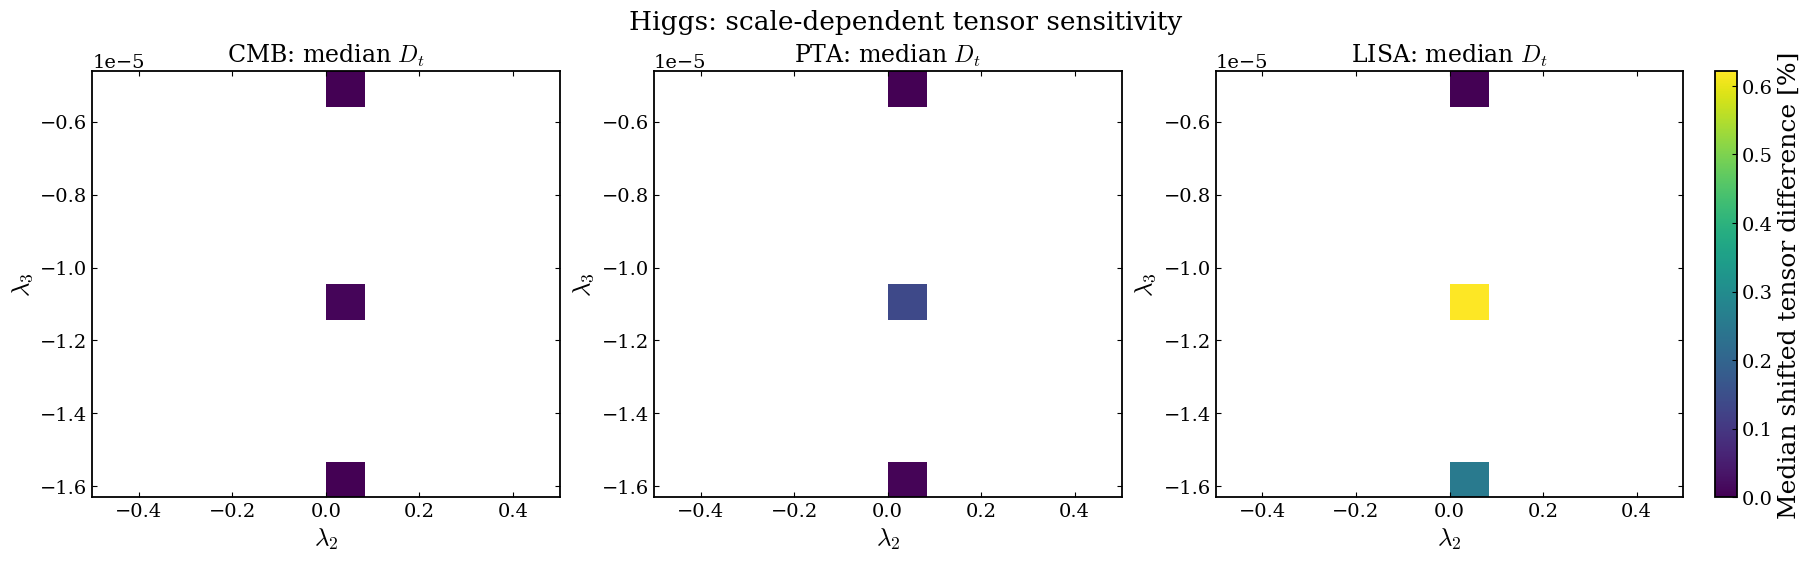

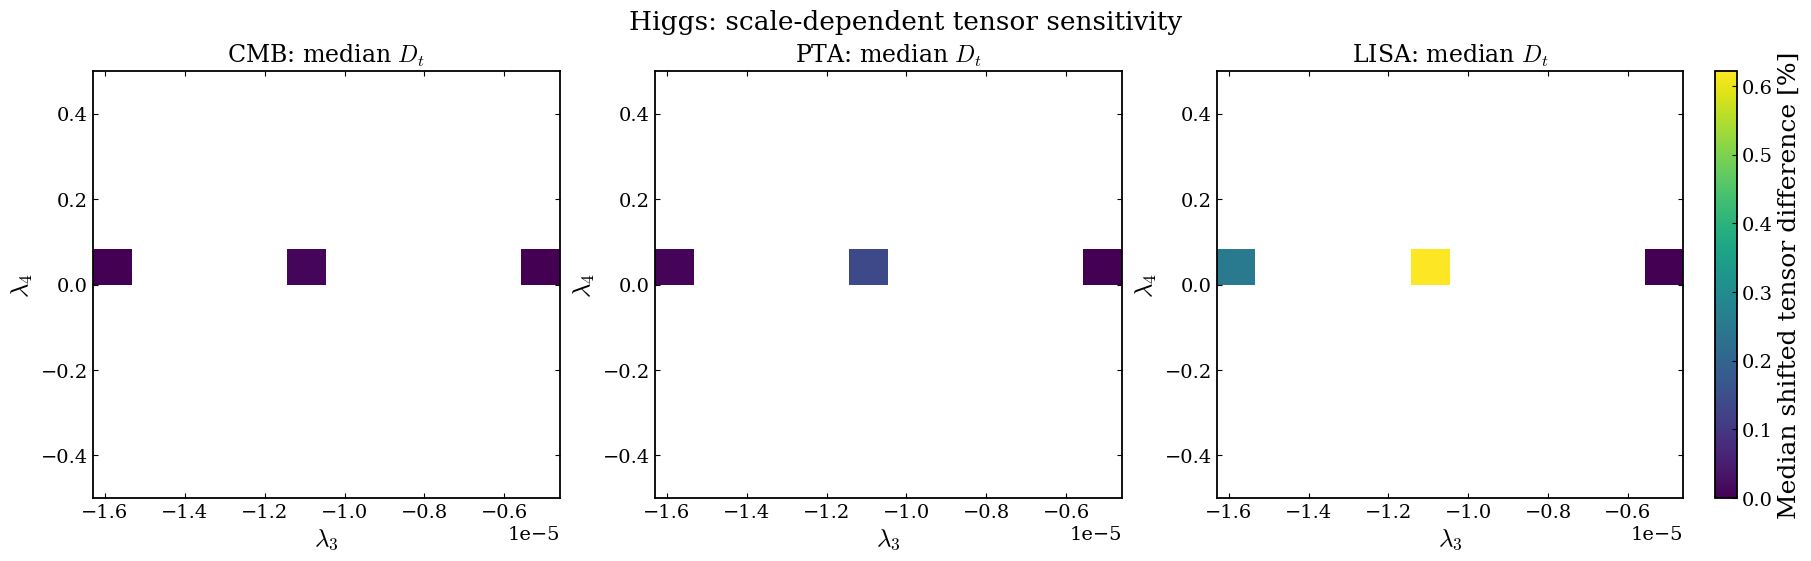

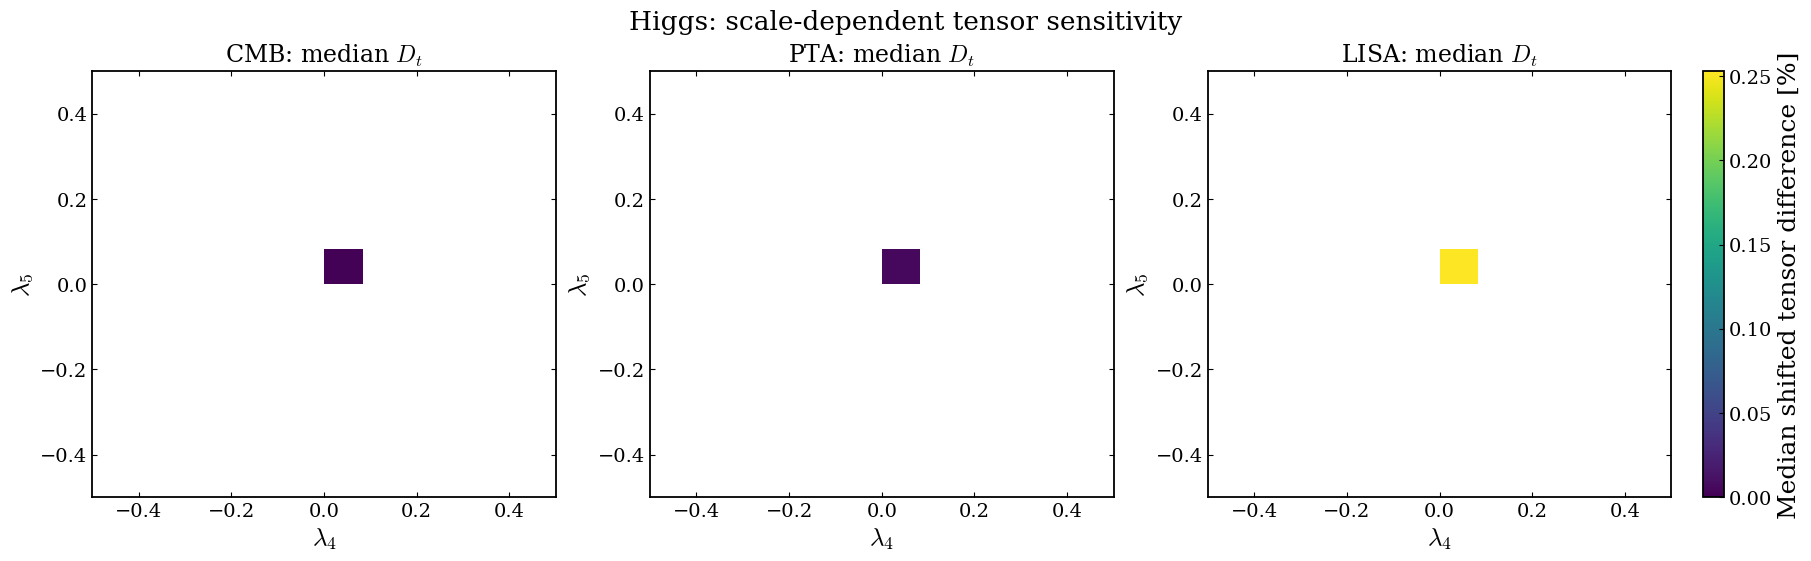

In [51]:
higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam2",
        y_param="lam3",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam2_lam3_heatmaps.pdf"
        ),
    )
)





higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam3",
        y_param="lam4",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam3_lam4_heatmaps.pdf"
        ),
    )
)


higgs_heatmaps, higgs_counts = (
    plot_tensor_band_heatmaps(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",

        x_param="lam4",
        y_param="lam5",

        bins=12,
        min_count=1,

        common_color_scale=True,

        save_name=(
            "paper_higgs_Dt_CMB_PTA_LISA_"
            "lam4_lam5_heatmaps.pdf"
        ),
    )
)

For Quad:

In [52]:
# quad_heatmaps, quad_counts = (
#     plot_tensor_band_heatmaps(
#         tensor_band_df=tensor_band_results["nonhiggs"],
#         model_tag="nonhiggs",

#         x_param="lam2",
#         y_param="lam3",

#         bins=12,
#         min_count=1,

#         common_color_scale=True,

#         save_name=(
#             "paper_nonhiggs_Dt_CMB_PTA_LISA_"
#             "lam2_lam3_heatmaps.pdf"
#         ),
#     )
# )


# quad_heatmaps, quad_counts = (
#     plot_tensor_band_heatmaps(
#         tensor_band_df=tensor_band_results["nonhiggs"],
#         model_tag="nonhiggs",

#         x_param="lam3",
#         y_param="lam4",

#         bins=12,
#         min_count=1,

#         common_color_scale=True,

#         save_name=(
#             "paper_nonhiggs_Dt_CMB_PTA_LISA_"
#             "lam3_lam4_heatmaps.pdf"
#         ),
#     )
# )


# quad_heatmaps, quad_counts = (
#     plot_tensor_band_heatmaps(
#         tensor_band_df=tensor_band_results["nonhiggs"],
#         model_tag="nonhiggs",

#         x_param="lam4",
#         y_param="lam5",

#         bins=12,
#         min_count=1,

#         common_color_scale=True,

#         save_name=(
#             "paper_nonhiggs_Dt_CMB_PTA_LISA_"
#             "lam4_lam5_heatmaps.pdf"
#         ),
#     )
# )

## Influence of Parameters Across Multiple Scales

The plots above are trying to answer a question about whether the influence of higher-order slow roll param grows with distance from our CMB pivot. Basically, does the influence of the higher-order hierarchy stay constant throughout inflation, or does it emerge only as we extrapolate away from the CMB pivot?

It is worth noting that in the code for this initial run, where LAM2 gets sets to keep deltaN in the same fam. The rest get run in the original kinney ranges. 

LAM5_MIN = -5e-5 LAM5_MAX = 5e-5 
LAM4_MIN = -5e-4 LAM4_MAX = 5e-4 
LAM3_MIN = -5e-3 LAM3_MAX = 5e-3 
LAM2_MIN = -5e-4 LAM2_MAX = 5e-4

Currently, what I see above is that the median Dt_med follows this trend: 
$D^{t,med}_{CMB} < D^{t,med}_{PTA} < D^{t,med}_{LISA}$

It says that while the CMB anchors the inflationary trajectory locally, the freedom encoded in the higher-order Hubble-flow hierarchy becomes increasingly important as you extrapolate to much smaller scales.

## Look at Pearson/Spearman for D_t_median on 3 Observable Scales

Given two models that are indistinguishable at the CMB, how much can they diverge in the stochastic gravitational-wave background, and which higher-order flow parameters drive that divergence?

In [47]:
from scipy.stats import pearsonr, spearmanr

def hierarchy_band_correlations(
    tensor_band_df,
    parameters=("lam3", "lam4", "lam5"),
    band_metrics=(
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
    ),
):
    rows = []

    for param in parameters:
        for metric in band_metrics:

            use = tensor_band_df[
                [param, metric]
            ].replace(
                [np.inf, -np.inf],
                np.nan,
            ).dropna()

            if len(use) < 3:
                continue

            x = use[param].to_numpy(dtype=float)
            y = use[metric].to_numpy(dtype=float)

            pearson_r, pearson_p = pearsonr(x, y)
            spearman_rho, spearman_p = spearmanr(x, y)

            rows.append({
                "parameter": param,
                "metric": metric,
                "N": len(use),

                "pearson_r": pearson_r,
                "pearson_p": pearson_p,

                "spearman_rho": spearman_rho,
                "spearman_p": spearman_p,
            })

    result = pd.DataFrame(rows)

    print(
        result.round(4).to_string(index=False)
    )

    return result

In [48]:
corr_higgs_bands = hierarchy_band_correlations(
    tensor_band_results["higgs"]
)

parameter          metric   N  pearson_r  pearson_p  spearman_rho  spearman_p
     lam3  D_t_CMB_median 104    -0.1604     0.1038       -0.1422      0.1498
     lam3  D_t_PTA_median 104     0.6340     0.0000        0.5983      0.0000
     lam3 D_t_LISA_median 104     0.5795     0.0000        0.7250      0.0000
     lam4  D_t_CMB_median 104    -0.1549     0.1163       -0.1236      0.2112
     lam4  D_t_PTA_median 104     0.5695     0.0000        0.5657      0.0000
     lam4 D_t_LISA_median 104     0.4582     0.0000        0.6581      0.0000
     lam5  D_t_CMB_median 104    -0.0272     0.7841       -0.0267      0.7875
     lam5  D_t_PTA_median 104     0.0952     0.3364        0.0868      0.3809
     lam5 D_t_LISA_median 104    -0.0525     0.5966        0.0454      0.6475


In [49]:
corr_quad_bands = hierarchy_band_correlations(
    tensor_band_results["nonhiggs"]
)

parameter          metric   N  pearson_r  pearson_p  spearman_rho  spearman_p
     lam3  D_t_CMB_median 120     0.5855     0.0000        0.5937      0.0000
     lam3  D_t_PTA_median 120     0.9141     0.0000        0.9421      0.0000
     lam3 D_t_LISA_median 120     0.8604     0.0000        0.8871      0.0000
     lam4  D_t_CMB_median 120     0.5493     0.0000        0.5483      0.0000
     lam4  D_t_PTA_median 120     0.8247     0.0000        0.8363      0.0000
     lam4 D_t_LISA_median 120     0.7746     0.0000        0.7823      0.0000
     lam5  D_t_CMB_median 120     0.0800     0.3849        0.0467      0.6128
     lam5  D_t_PTA_median 120     0.0537     0.5606       -0.0029      0.9750
     lam5 D_t_LISA_median 120     0.0231     0.8019       -0.0331      0.7194


In [50]:
def plot_Dt_vs_lam3_lam4_by_scale(
    tensor_band_df,
    model_tag,
    n_bins=10,
    min_models_per_bin=3,
    save_name=None,
    show=True,
):
    """
    Plot shifted tensor-spectrum distance versus lambda_3 and lambda_4
    separately across the CMB, PTA, and LISA bands.

    Rows
    ----
    Row 1: D_t versus lam3
    Row 2: D_t versus lam4

    Columns
    -------
    CMB, PTA, LISA

    The scatter shows individual models.
    The line shows the binned median.
    The shaded region shows the 16th–84th percentile range.
    """

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    parameters = [
        ("lam3", r"$\lambda_3$"),
        ("lam4", r"$\lambda_4$"),
    ]

    bands = [
        ("CMB", "D_t_CMB_median"),
        ("PTA", "D_t_PTA_median"),
        ("LISA", "D_t_LISA_median"),
    ]

    required_columns = {
        "lam3",
        "lam4",
        "D_t_CMB_median",
        "D_t_PTA_median",
        "D_t_LISA_median",
    }

    missing = required_columns.difference(
        tensor_band_df.columns
    )

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(22, 14),
        constrained_layout=True,
        sharey="col",
    )

    binned_rows = []

    for row_index, (parameter, parameter_label) in enumerate(
        parameters
    ):
        for column_index, (band_name, metric_column) in enumerate(
            bands
        ):
            ax = axes[row_index, column_index]

            use = tensor_band_df[
                [
                    parameter,
                    metric_column,
                ]
            ].replace(
                [np.inf, -np.inf],
                np.nan,
            ).dropna()

            if use.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No finite models",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )
                continue

            x = use[parameter].to_numpy(dtype=float)
            y = use[metric_column].to_numpy(dtype=float)

            # ------------------------------------------
            # Individual models
            # ------------------------------------------

            ax.scatter(
                x,
                y,
                s=28,
                alpha=0.4,
                edgecolors="none",
            )

            # ------------------------------------------
            # Equal-width parameter bins
            # ------------------------------------------

            bin_edges = np.linspace(
                np.nanmin(x),
                np.nanmax(x),
                n_bins + 1,
            )

            bin_centers = 0.5 * (
                bin_edges[:-1] + bin_edges[1:]
            )

            bin_indices = np.digitize(
                x,
                bin_edges[1:-1],
            )

            median_values = np.full(
                n_bins,
                np.nan,
            )

            p16_values = np.full(
                n_bins,
                np.nan,
            )

            p84_values = np.full(
                n_bins,
                np.nan,
            )

            counts = np.zeros(
                n_bins,
                dtype=int,
            )

            for bin_index in range(n_bins):
                mask = bin_indices == bin_index
                counts[bin_index] = np.count_nonzero(mask)

                if counts[bin_index] < min_models_per_bin:
                    continue

                values = y[mask]

                median_values[bin_index] = np.nanmedian(
                    values
                )

                p16_values[bin_index] = np.nanpercentile(
                    values,
                    16,
                )

                p84_values[bin_index] = np.nanpercentile(
                    values,
                    84,
                )

                binned_rows.append({
                    "model_tag": model_tag,
                    "parameter": parameter,
                    "band": band_name,
                    "bin_center": bin_centers[bin_index],
                    "count": counts[bin_index],
                    "median_Dt_pct": median_values[bin_index],
                    "p16_Dt_pct": p16_values[bin_index],
                    "p84_Dt_pct": p84_values[bin_index],
                })

            valid = np.isfinite(median_values)

            if np.any(valid):
                ax.fill_between(
                    bin_centers[valid],
                    p16_values[valid],
                    p84_values[valid],
                    alpha=0.18,
                    label="16th–84th percentile",
                )

                ax.plot(
                    bin_centers[valid],
                    median_values[valid],
                    marker="o",
                    linewidth=2.4,
                    markersize=5,
                    label="Binned median",
                )

            # ------------------------------------------
            # Labels
            # ------------------------------------------

            ax.set_xlabel(parameter_label)

            if column_index == 0:
                ax.set_ylabel(
                    r"Median shifted tensor difference $D_t$ [\%]"
                )

            if row_index == 0:
                ax.set_title(
                    f"{band_name} scales"
                )

            ax.grid(
                True,
                alpha=0.25,
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    if handles:
        fig.legend(
            handles,
            labels,
            frameon=False,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=2,
        )

    fig.suptitle(
        rf"{model_label}: scale-dependent tensor response "
        rf"to $\lambda_3$ and $\lambda_4$",
        fontsize=20,
        y=1.02
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_Dt_vs_lam3_lam4_"
            f"CMB_PTA_LISA.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    binned_df = pd.DataFrame(binned_rows)

    return tensor_band_df.copy(), binned_df

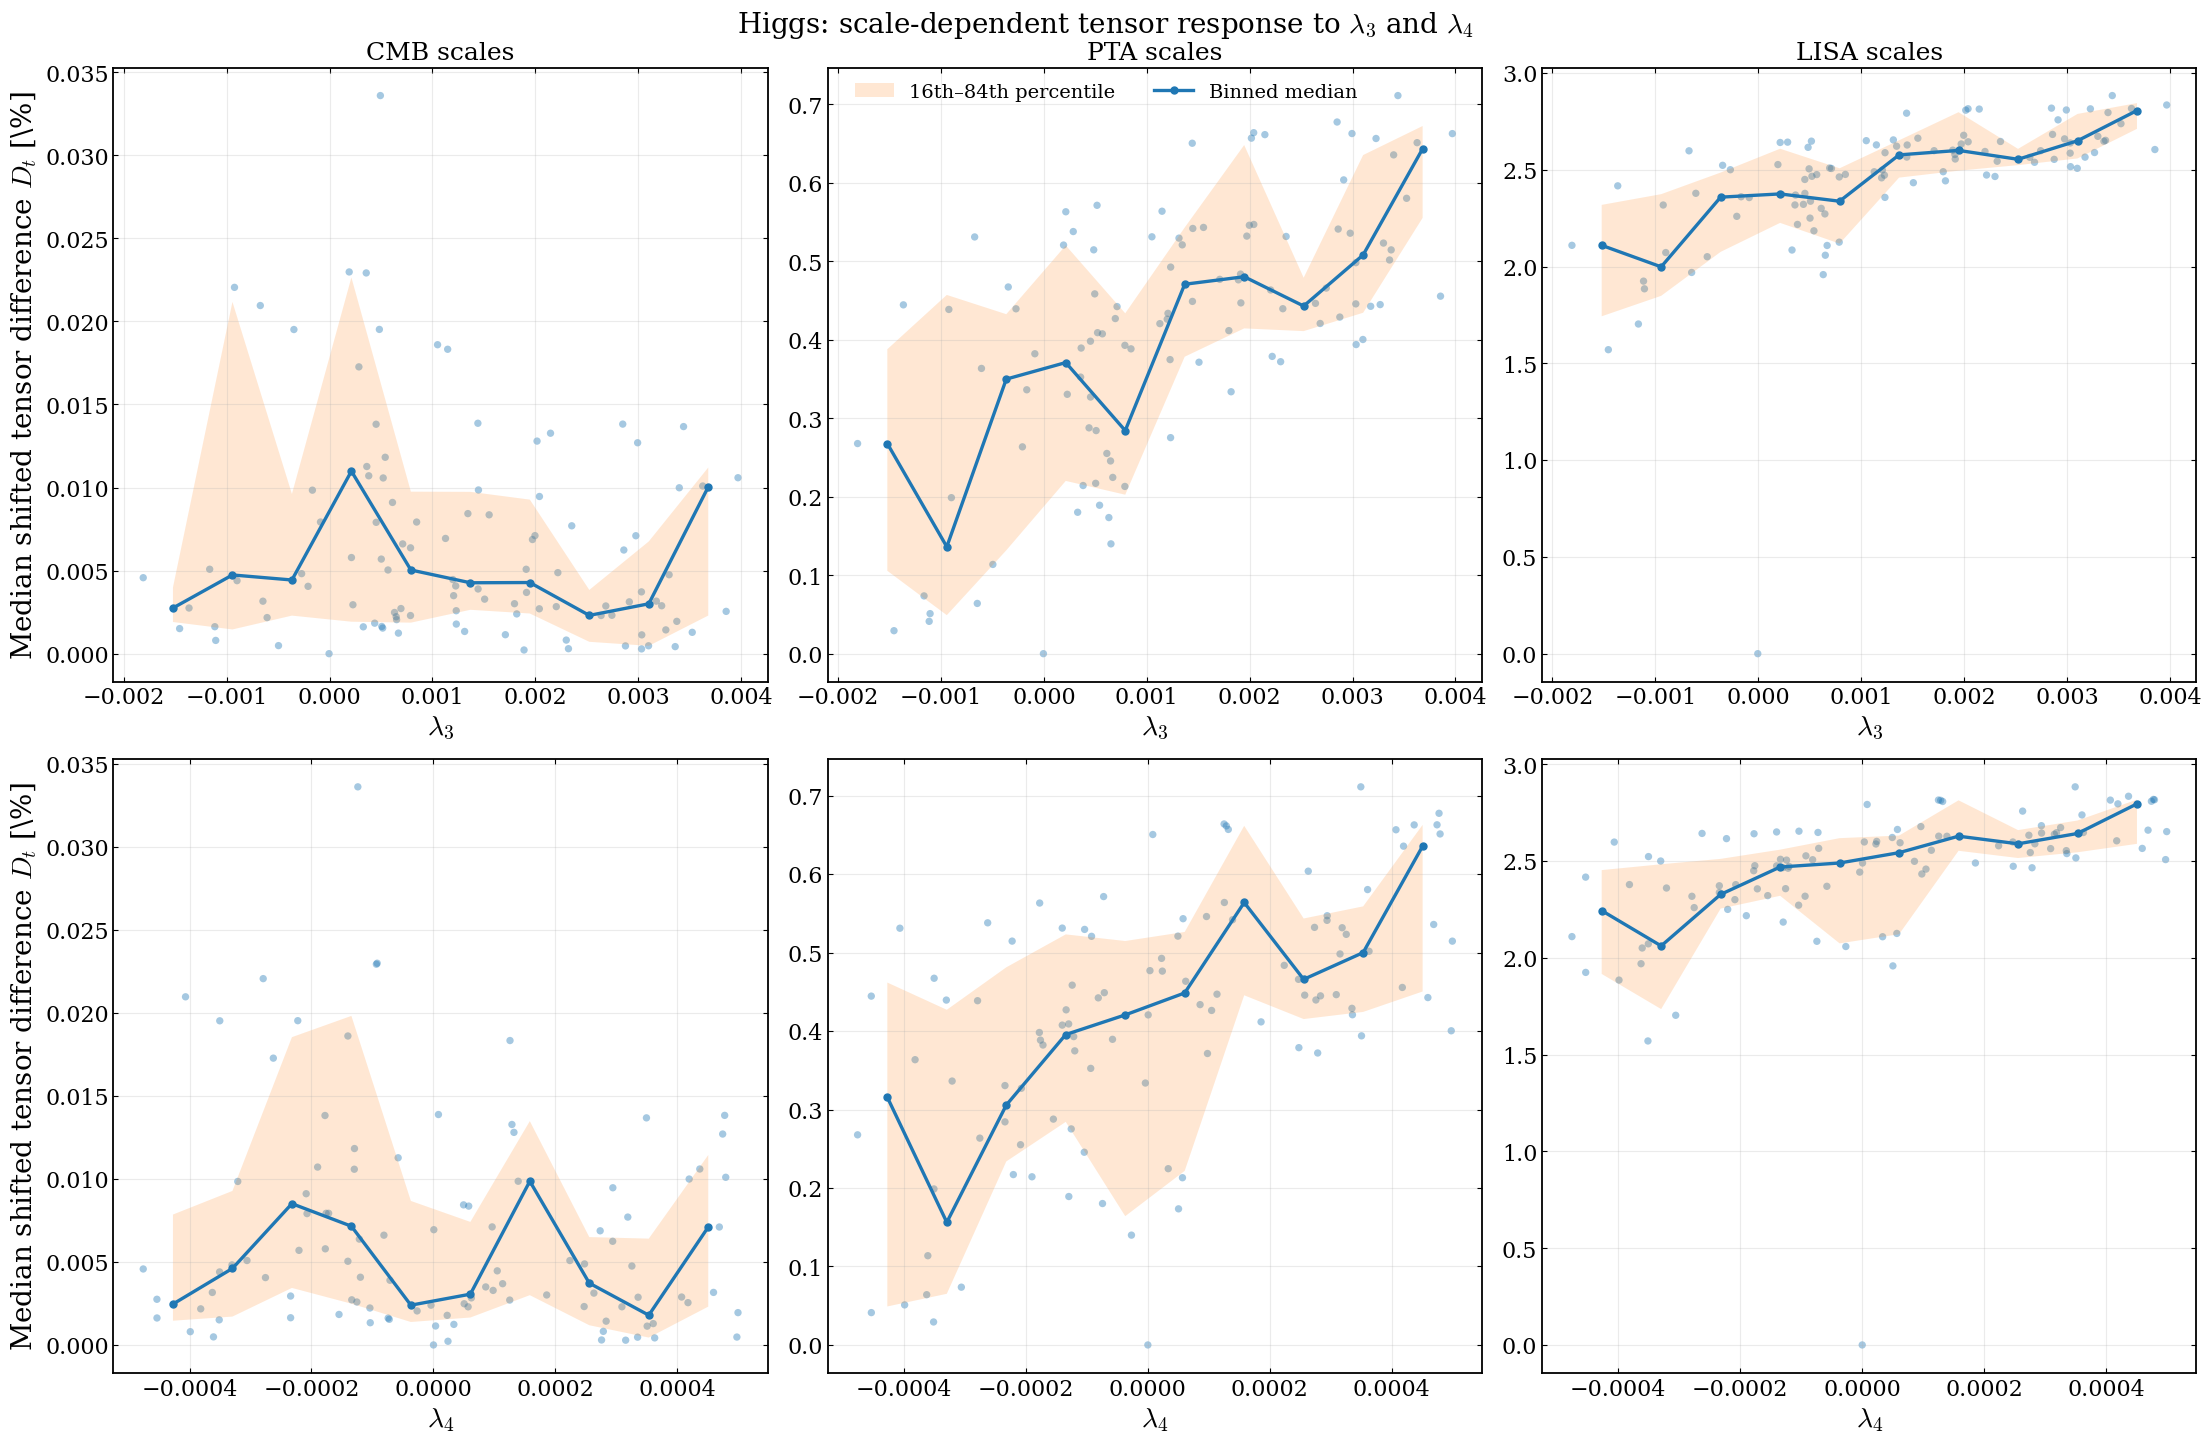

In [51]:
higgs_Dt_response, higgs_Dt_binned = (
    plot_Dt_vs_lam3_lam4_by_scale(
        tensor_band_df=tensor_band_results["higgs"],
        model_tag="higgs",
        n_bins=10,
        min_models_per_bin=3,
        save_name=(
            "paper_higgs_Dt_vs_lam3_lam4_"
            "CMB_PTA_LISA.pdf"
        ),
    )
)

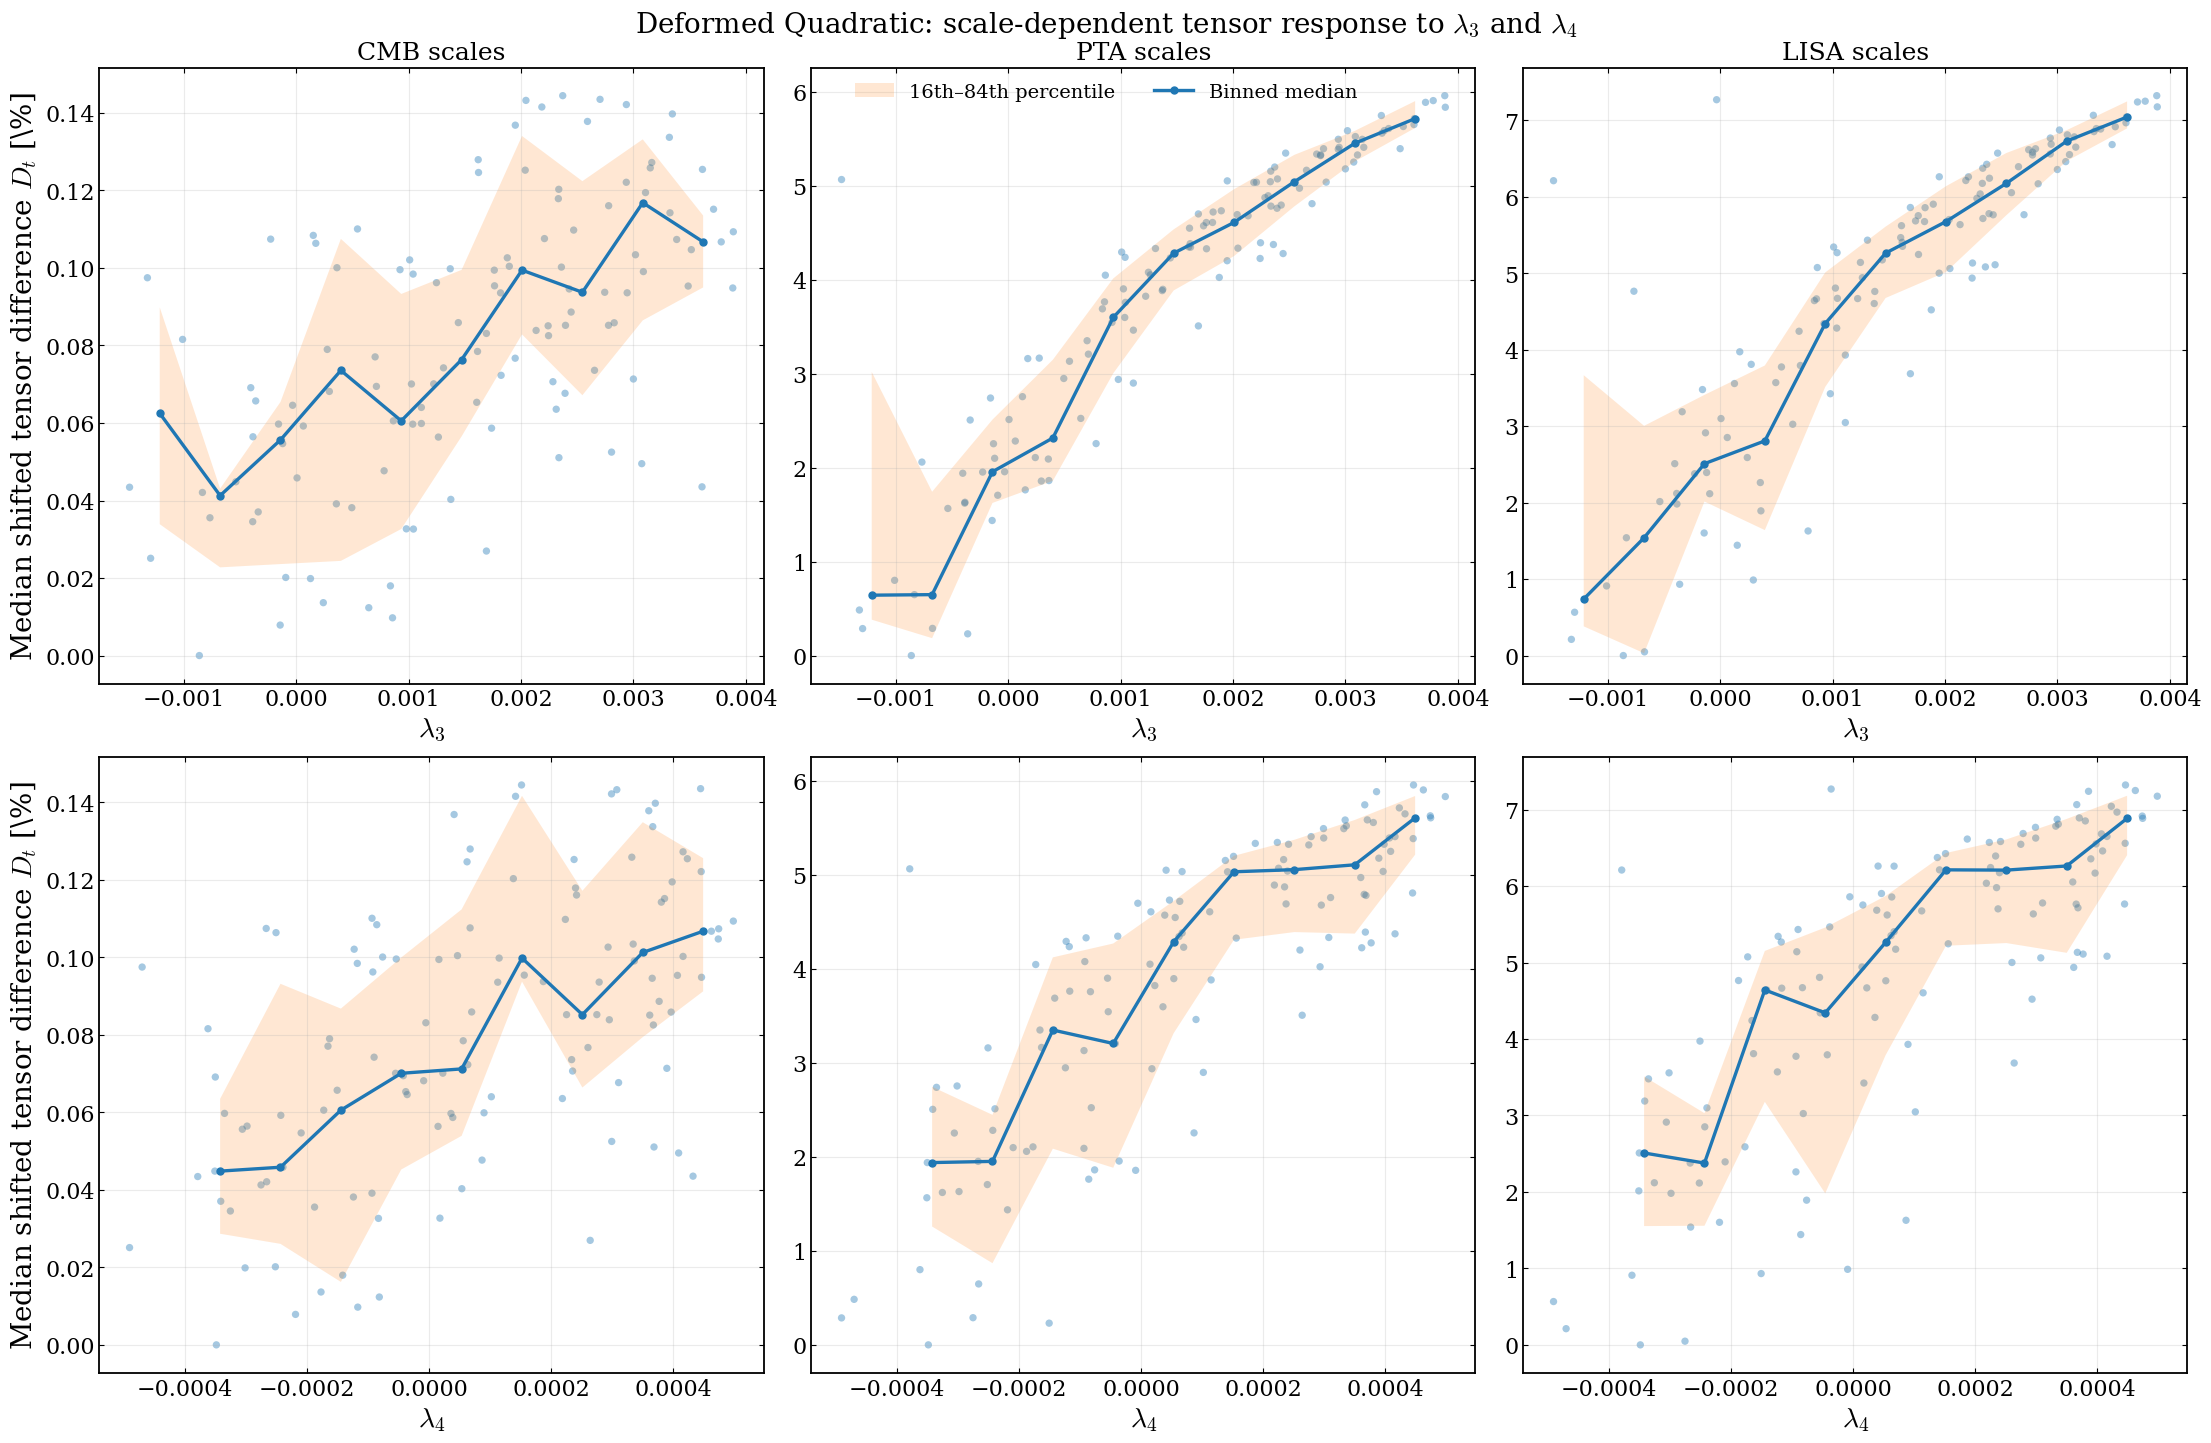

In [52]:
quad_Dt_response, quad_Dt_binned = (
    plot_Dt_vs_lam3_lam4_by_scale(
        tensor_band_df=tensor_band_results["nonhiggs"],
        model_tag="nonhiggs",
        n_bins=10,
        min_models_per_bin=3,
        save_name=(
            "paper_nonhiggs_Dt_vs_lam3_lam4_"
            "CMB_PTA_LISA.pdf"
        ),
    )
)

In [53]:
def inspect_hierarchy_at_Nref(
    NEQS,
    lamX_values,
    base_path_root,
    model_tag="higgs",
    N_ref=60.0,
    max_models=12,
    save_name=None,
    show=True,
):
    """
    Plot lambda_2 through lambda_5 as functions of N and compare
    their interpolated values at N_ref with the summary-table values.

    Assumed NEQS=8 path-column layout:
        0: phi
        1: H
        2: epsilon
        3: sigma
        4: lambda_2
        5: lambda_3
        6: lambda_4
        7: lambda_5
        8: N
        9: V
    """
    if NEQS < 8:
        raise ValueError(
            "This diagnostic requires path data containing "
            "lambda_2 through lambda_5."
        )

    param_name, param_symbol = SCAN_INFO[NEQS]

    model_label = MODEL_CONFIG.get(
        model_tag,
        {},
    ).get("label", model_tag)

    summary_df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    ).copy()

    values = sanitize_lam_values(lamX_values)

    if max_models is not None and len(values) > max_models:
        # Choose models spread across the supplied scan values.
        indices = np.linspace(
            0,
            len(values) - 1,
            max_models,
            dtype=int,
        )
        values = values[indices]

    hierarchy_columns = {
        "lam2": 4,
        "lam3": 5,
        "lam4": 6,
        "lam5": 7,
    }

    hierarchy_labels = {
        "lam2": r"$^{2}\lambda_H$",
        "lam3": r"$^{3}\lambda_H$",
        "lam4": r"$^{4}\lambda_H$",
        "lam5": r"$^{5}\lambda_H$",
    }

    def get_summary_row(value):
        matches = summary_df.loc[
            np.isclose(
                summary_df[param_name].to_numpy(dtype=float),
                value,
                rtol=1e-10,
                atol=max(1e-15, abs(value) * 1e-10),
            )
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No summary row for {param_name}={value:.10e}"
            )

        return matches.iloc[0]

    def order_by_monotonic_N(data):
        N = np.asarray(data[:, NEQS], dtype=float)

        hierarchy = {
            name: np.asarray(data[:, column], dtype=float)
            for name, column in hierarchy_columns.items()
        }

        finite = np.isfinite(N)

        for values_array in hierarchy.values():
            finite &= np.isfinite(values_array)

        N = N[finite]

        hierarchy = {
            name: values_array[finite]
            for name, values_array in hierarchy.items()
        }

        if len(N) < 2:
            raise ValueError(
                "Not enough finite trajectory points."
            )

        dN = np.diff(N)

        if np.all(dN >= 0):
            return N, hierarchy

        if np.all(dN <= 0):
            return (
                N[::-1],
                {
                    name: values_array[::-1]
                    for name, values_array in hierarchy.items()
                },
            )

        raise ValueError(
            "N is non-monotonic; refusing to sort the trajectory."
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 10),
        constrained_layout=True,
        sharex=True,
    )

    axes_by_parameter = {
        "lam2": axes[0, 0],
        "lam3": axes[0, 1],
        "lam4": axes[1, 0],
        "lam5": axes[1, 1],
    }

    cmap = plt.get_cmap("viridis")

    if len(values) > 1:
        color_norm = mcolors.Normalize(
            vmin=np.min(values),
            vmax=np.max(values),
        )
    else:
        color_norm = None

    audit_rows = []

    for value in values:
        try:
            data = load_path_data(
                NEQS=NEQS,
                param_name=param_name,
                value=value,
                base_path_root=base_path_root,
                model_tag=model_tag,
            )

            N, hierarchy = order_by_monotonic_N(data)

            if not (N.min() <= N_ref <= N.max()):
                raise ValueError(
                    f"N_ref={N_ref} outside trajectory range "
                    f"[{N.min():.6g}, {N.max():.6g}]"
                )

            summary_row = get_summary_row(value)

            color = (
                cmap(color_norm(value))
                if color_norm is not None
                else cmap(0.5)
            )

            audit_row = {
                "model_tag": model_tag,
                "scan_parameter": param_name,
                "scan_value": value,
                "N_min": N.min(),
                "N_max": N.max(),
            }

            for name, values_array in hierarchy.items():
                value_at_ref = float(
                    np.interp(
                        N_ref,
                        N,
                        values_array,
                    )
                )

                summary_value = (
                    float(summary_row[name])
                    if name in summary_row.index
                    else np.nan
                )

                audit_row[f"{name}_at_Nref"] = value_at_ref
                audit_row[f"{name}_summary"] = summary_value
                audit_row[f"{name}_difference"] = (
                    value_at_ref - summary_value
                    if np.isfinite(summary_value)
                    else np.nan
                )

                axes_by_parameter[name].plot(
                    N,
                    values_array,
                    color=color,
                    linewidth=1.5,
                    alpha=0.8,
                )

                axes_by_parameter[name].scatter(
                    N_ref,
                    value_at_ref,
                    color=color,
                    s=25,
                    zorder=5,
                )

            audit_rows.append(audit_row)

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {model_tag}, "
                f"{param_name}={value:.5e}: {exc}"
            )

    audit_df = pd.DataFrame(audit_rows)

    if audit_df.empty:
        plt.close(fig)
        raise ValueError(
            "No models could be loaded for the hierarchy audit."
        )

    for name, ax in axes_by_parameter.items():
        ax.axvline(
            N_ref,
            color="black",
            linestyle="--",
            linewidth=1.4,
            label=rf"$N={N_ref:g}$",
        )

        ax.set_title(hierarchy_labels[name])
        ax.set_xlabel(r"$N$")
        ax.set_ylabel(hierarchy_labels[name])
        ax.grid(True, alpha=0.25)
        ax.invert_xaxis()

    axes[0, 0].legend(
        frameon=False,
        loc="best",
    )

    if color_norm is not None:
        sm = cm.ScalarMappable(
            norm=color_norm,
            cmap=cmap,
        )
        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=axes,
            pad=0.02,
        )
        cbar.set_label(param_symbol)

    fig.suptitle(
        rf"{model_label}: hierarchy evolution and "
        rf"$N={N_ref:g}$ initialization audit",
        fontsize=19,
    )

    if save_name is None:
        save_name = (
            f"{model_tag}_neqs{NEQS}_"
            f"hierarchy_vs_N_audit.pdf"
        )

    fig.savefig(
        save_name,
        dpi=300,
        bbox_inches="tight",
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    display_columns = [
        "scan_value",
        "N_min",
        "N_max",
        "lam2_at_Nref",
        "lam2_summary",
        "lam2_difference",
        "lam3_at_Nref",
        "lam3_summary",
        "lam3_difference",
        "lam4_at_Nref",
        "lam4_summary",
        "lam4_difference",
        "lam5_at_Nref",
        "lam5_summary",
        "lam5_difference",
    ]

    print("\nHierarchy values at the reference point:")
    print(
        audit_df[display_columns].to_string(
            index=False,
            float_format=lambda value: f"{value:.6e}",
        )
    )

    return audit_df

In [55]:
# hierarchy_audit_higgs = inspect_hierarchy_at_Nref(
#     NEQS=8,
#     lamX_values=param_values_by_model["higgs"][8],
#     base_path_root=base_path_root,
#     model_tag="higgs",
#     N_ref=60.0,
#     max_models=12,
#     save_name="higgs_hierarchy_at_N60_audit.pdf",
# )

# hierarchy_audit_nonhiggs = inspect_hierarchy_at_Nref(
#     NEQS=8,
#     lamX_values=param_values_by_model["nonhiggs"][8],
#     base_path_root=base_path_root,
#     model_tag="nonhiggs",
#     N_ref=60.0,
#     max_models=12,
#     save_name="nonhiggs_hierarchy_at_N60_audit.pdf",
# )

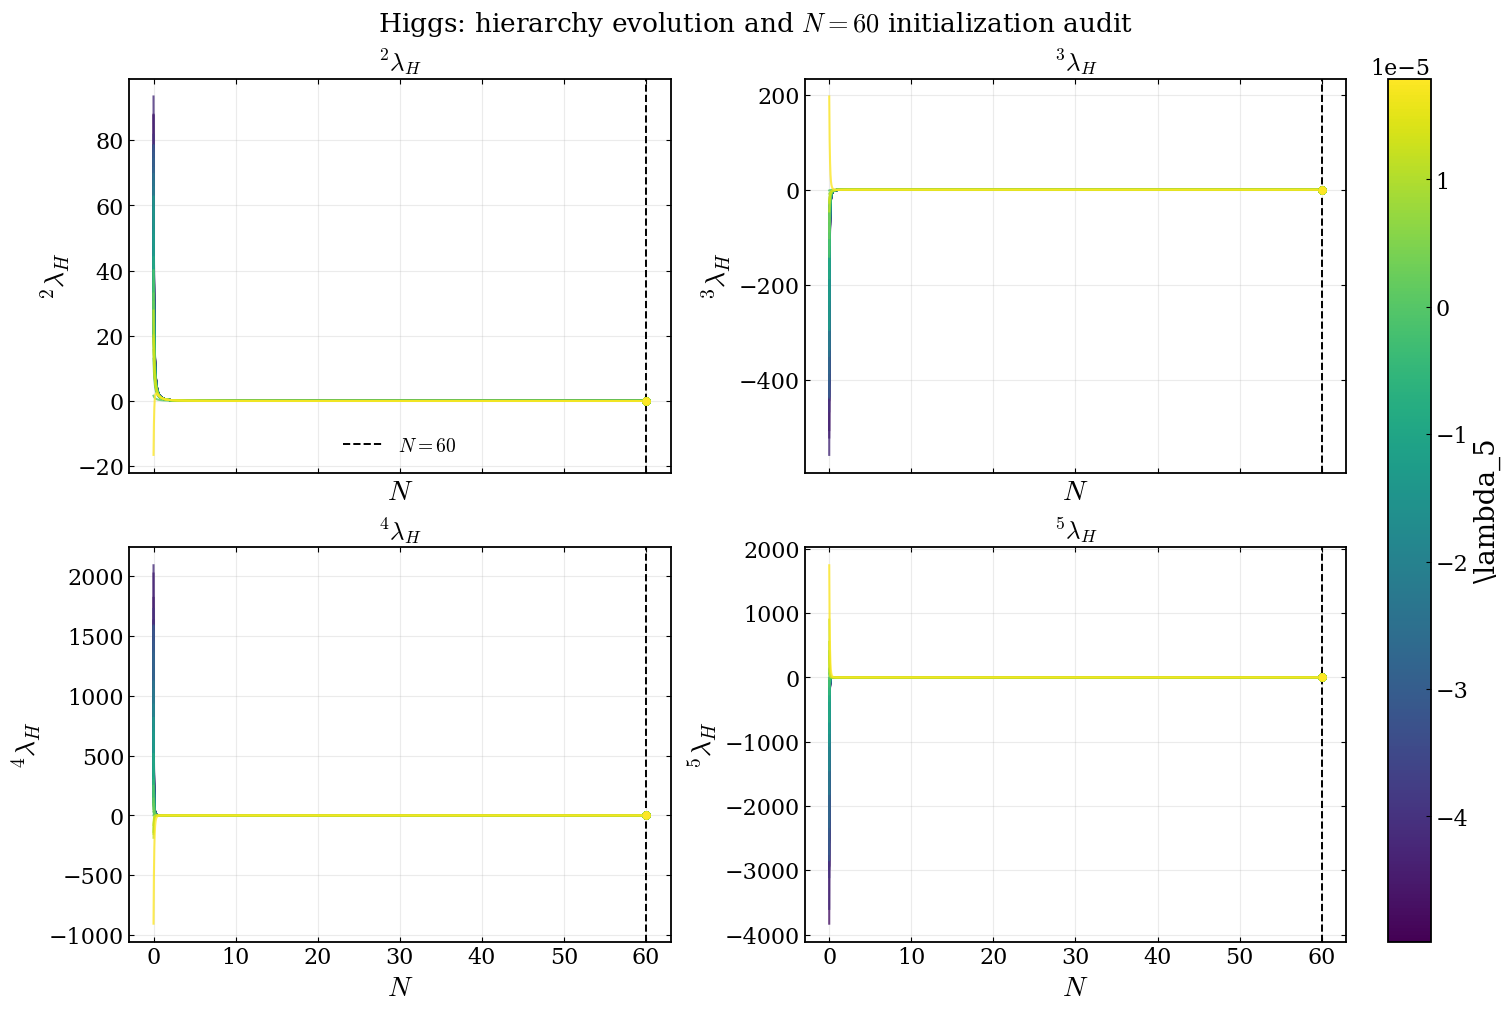


Hierarchy values at the reference point:
   scan_value        N_min        N_max  lam2_at_Nref  lam2_summary  lam2_difference  lam3_at_Nref  lam3_summary  lam3_difference  lam4_at_Nref  lam4_summary  lam4_difference  lam5_at_Nref  lam5_summary  lam5_difference
-4.982476e-05 1.000000e-06 6.000000e+01  1.485551e-03  3.382172e-04     1.147334e-03  1.041450e-03  1.231294e-03    -1.898442e-04 -1.670186e-04 -1.255789e-04    -4.143971e-05 -4.645910e-05 -4.982476e-05     3.365665e-06
-4.936437e-05 1.000000e-06 6.000000e+01 -3.079541e-03 -1.947960e-04    -2.884745e-03  3.728851e-03  3.969525e-03    -2.406739e-04  4.933002e-04  4.367435e-04     5.655672e-05 -5.210970e-05 -4.936437e-05    -2.745334e-06
-4.857442e-05 1.000000e-06 6.000000e+01 -2.726231e-03 -1.031894e-04    -2.623042e-03  3.112506e-03  3.268128e-03    -1.556215e-04  3.380530e-04  2.831766e-04     5.487637e-05 -5.160639e-05 -4.857442e-05    -3.031974e-06
-4.835134e-05 1.000000e-06 6.000000e+01 -1.099951e-03  3.262398e-04    -1.4261

In [57]:
# hierarchy_audit_higgs = inspect_hierarchy_at_Nref(
#     NEQS=8,
#     lamX_values=param_values_by_model["higgs"][8],
#     base_path_root=base_path_root,
#     model_tag="higgs",
#     N_ref=60.0,
#     max_models=None,
# )

In [58]:
summary_all = load_batch_summaries(
    NEQS=8,
    base_path_root=base_path_root,
    model_tag="higgs",
)

accepted = summary_all[
    [
        "lam2",
        "lam3",
        "lam4",
        "lam5",
        "n_s",
        "r",
        "alpha_s",
    ]
].replace([np.inf, -np.inf], np.nan).dropna()

pearson_r, pearson_p = pearsonr(
    accepted["lam3"],
    accepted["lam4"],
)

spearman_rho, spearman_p = spearmanr(
    accepted["lam3"],
    accepted["lam4"],
)

print(f"N = {len(accepted)}")
print(
    f"Pearson:  r={pearson_r:.6f}, "
    f"p={pearson_p:.3e}"
)
print(
    f"Spearman: rho={spearman_rho:.6f}, "
    f"p={spearman_p:.3e}"
)

N = 120
Pearson:  r=0.947049, p=4.678e-60
Spearman: rho=0.925967, p=9.733e-52


Selection Induced Correlations??

In [56]:
from scipy.stats import pearsonr, spearmanr

valid = hierarchy_audit_higgs[
    [
        "lam3_at_Nref",
        "lam4_at_Nref",
    ]
].dropna()

pearson_r, pearson_p = pearsonr(
    valid["lam3_at_Nref"],
    valid["lam4_at_Nref"],
)

spearman_rho, spearman_p = spearmanr(
    valid["lam3_at_Nref"],
    valid["lam4_at_Nref"],
)

print(f"Pearson  lam3-lam4 at N=60: r={pearson_r:.6f}, p={pearson_p:.3e}")
print(f"Spearman lam3-lam4 at N=60: rho={spearman_rho:.6f}, p={spearman_p:.3e}")

Pearson  lam3-lam4 at N=60: r=0.941813, p=4.762e-06
Spearman lam3-lam4 at N=60: rho=0.902098, p=5.998e-05


lam3 and lam4 are sampled independently, but the accepted models occupy a strongly correlated subspace of the initial-condition parameter space.

In [59]:
def audit_CMB_pivot_for_models(
    NEQS,
    values,
    base_path_root,
    model_tag,
    k_pivot=0.05,
):
    """
    Check observable cuts and raw spectral amplitudes at the CMB pivot.

    This does not normalize the spectra, so Ps_pivot and Pt_pivot
    remain physical amplitudes from the saved spectrum files.
    """
    param_name, _ = SCAN_INFO[NEQS]

    summary_df = load_batch_summaries(
        NEQS=NEQS,
        base_path_root=base_path_root,
        model_tag=model_tag,
    )

    rows = []

    for value in sanitize_lam_values(values):
        try:
            matches = summary_df.loc[
                np.isclose(
                    summary_df[param_name].to_numpy(dtype=float),
                    value,
                    rtol=1e-10,
                    atol=max(1e-15, abs(value) * 1e-10),
                )
            ]

            if matches.empty:
                raise FileNotFoundError(
                    f"No summary row for {param_name}={value:.10e}"
                )

            summary = matches.iloc[0]

            k_s, Ps, k_t, Pt = load_specs(
                NEQS=NEQS,
                param_name=param_name,
                value=value,
                base_path_root=base_path_root,
                model_tag=model_tag,
            )

            k_s, Ps = prepare_increasing(k_s, Ps)
            k_t, Pt = prepare_increasing(k_t, Pt)

            scalar_has_pivot = (
                k_s.min() <= k_pivot <= k_s.max()
            )

            tensor_has_pivot = (
                k_t.min() <= k_pivot <= k_t.max()
            )

            Ps_pivot = (
                float(np.interp(k_pivot, k_s, Ps))
                if scalar_has_pivot
                else np.nan
            )

            Pt_pivot = (
                float(np.interp(k_pivot, k_t, Pt))
                if tensor_has_pivot
                else np.nan
            )

            rows.append({
                "model_tag": model_tag,
                "value": value,

                "eps_init": float(summary["eps"]),
                "sig_init": float(summary["sig"]),
                "lam2_init": float(summary["lam2"]),
                "lam3_init": float(summary["lam3"]),
                "lam4_init": float(summary["lam4"]),
                "lam5_init": float(summary["lam5"]),

                "n_s": float(summary["n_s"]),
                "r": float(summary["r"]),
                "alpha_s": float(summary["alpha_s"]),

                "original_N_end": float(
                    summary["original_N_end"]
                ),

                "scalar_has_CMB_pivot": scalar_has_pivot,
                "tensor_has_CMB_pivot": tensor_has_pivot,

                "Ps_at_CMB_pivot_raw": Ps_pivot,
                "Pt_at_CMB_pivot_raw": Pt_pivot,

                "Pt_over_Ps_at_pivot": (
                    Pt_pivot / Ps_pivot
                    if (
                        np.isfinite(Ps_pivot)
                        and np.isfinite(Pt_pivot)
                        and Ps_pivot != 0
                    )
                    else np.nan
                ),
            })

        except (FileNotFoundError, ValueError) as exc:
            print(
                f"Skipping {model_tag}, "
                f"{param_name}={value:.5e}: {exc}"
            )

    audit_df = pd.DataFrame(rows)

    if audit_df.empty:
        raise ValueError("No models available for pivot audit.")

    print("\nPivot coverage:")
    print(
        audit_df[
            [
                "scalar_has_CMB_pivot",
                "tensor_has_CMB_pivot",
            ]
        ].value_counts()
    )

    print("\nObservable ranges:")
    print(
        audit_df[
            ["n_s", "r", "alpha_s", "original_N_end"]
        ].agg(["min", "max", "median"])
    )

    print("\nRaw pivot amplitudes:")
    print(
        audit_df[
            [
                "Ps_at_CMB_pivot_raw",
                "Pt_at_CMB_pivot_raw",
                "Pt_over_Ps_at_pivot",
            ]
        ].agg(["min", "max", "median"])
    )

    return audit_df

In [60]:
pivot_audit_higgs = audit_CMB_pivot_for_models(
    NEQS=8,
    values=param_values_by_model["higgs"][8],
    base_path_root=base_path_root,
    model_tag="higgs",
    k_pivot=0.05,
)


Pivot coverage:
scalar_has_CMB_pivot  tensor_has_CMB_pivot
True                  True                    120
Name: count, dtype: int64

Observable ranges:
             n_s         r   alpha_s  original_N_end
min     0.960011  0.001765 -0.004847      934.832539
max     0.969986  0.003732  0.004591      947.075571
median  0.965422  0.002762  0.000109      939.376052

Raw pivot amplitudes:
        Ps_at_CMB_pivot_raw  Pt_at_CMB_pivot_raw  Pt_over_Ps_at_pivot
min            2.070298e-09         4.358614e-12             0.002100
max            2.075966e-09         1.002724e-11             0.004843
median         2.073099e-09         7.225489e-12             0.003485


In [61]:
pivot_audit_higgs = audit_CMB_pivot_for_models(
    NEQS=8,
    values=param_values_by_model["nonhiggs"][8],
    base_path_root=base_path_root,
    model_tag="nonhiggs",
    k_pivot=0.05,
)


Pivot coverage:
scalar_has_CMB_pivot  tensor_has_CMB_pivot
True                  True                    120
Name: count, dtype: int64

Observable ranges:
             n_s         r   alpha_s  original_N_end
min     0.960013  0.031976 -0.004950      938.376163
max     0.969705  0.033952  0.004711      941.638102
median  0.965475  0.033116 -0.001355      939.797155

Raw pivot amplitudes:
        Ps_at_CMB_pivot_raw  Pt_at_CMB_pivot_raw  Pt_over_Ps_at_pivot
min            1.995319e-09         7.140652e-11             0.035545
max            2.008918e-09         8.500624e-11             0.042603
median         2.001887e-09         7.843839e-11             0.039182
